In [ ]:
'''SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 1024   / number of columns                            
NAXIS2  =                 1024   / number of rows                               
BSCALE  =                  1.0   / PhysValue = BZERO + BSCALE * ArrayValue      
BZERO   =              32768.0   / PhysValue = BZERO + BSCALE * ArrayValue      
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
GAIN    =                  2.2   / CCD gain (e-/ADU)                            
RDNOISE =                 15.0   / Readout noise (e- RMS)                       
CAMTEM  =                -32.0   / camera temperature (degrees Celsius)         
EXPTIME =                 0.20   / exposure time - seconds                      
OBSERVAT= 'CASLEO '              / observatory of observation                   
TELESCOP= 'HSH '                 / telescope of observation                     
DATE-OBS= '2024-07-04 '          / date of observation (yyyy-mm-dd)             
TIME-OBS= '21:47:08.200 '        / time at the start of the observation         
UT      = '21:47:07.3 '          / universal time                               
ST      = '12:03:33.4 '          / sidereal time                                
HA      = '+01:10:04.3 '         / hour angle                                   
RA      = '10:53:29.0 '          / right ascension                              
DEC     = '-31:47:04.3 '         / declination                                  
EQUINOX =               2024.5   / epoch of ra y dec                            
MJD-OBS =         60495.907720   / modified Julian date of the observation      
ZD      =                 14.9   / zenith distance                              
AIRMASS =                 1.03   / airmass                                      
RA2000  = '10:52:19.5 '          / right ascension J2000                        
DEC2000 = '-31:39:14.0 '         / declination J2000                            
TRK_FRQ =                59.99   / tracking frequency (Hz)                      
HA_PRLD =                 495.   / HA preload current (mA)                      
DEC_PRLD=                 699.   / DEC preload current (mA)                     
IMAGETYP= 'flat '                / object, dark, zero, etc.                     
INSTRUME= 'Direct CCD '                                                         
OBSERVER= 'Varela-Mast '                                                        
COMMENT = ' '                                                                   
PROG-ID = 'HSH-2024A-03 '                                                       
FILTER  = '(3) V '               / Filter wheel                                 
FILTER1 = '(6) Free '            / Auxiliar Filter wheel  '''
import pandas as pd
import numpy as np
from datetime import time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import Angle



df = pd.read_csv('image_collection_original_with_counts.csv')

df['date-obs'] = pd.to_datetime(df['date-obs'])
df["night"] = df["night"].astype(str)
df["file_old"] = df["file"]
df["imgtyp_old"] = df["imagetyp"]
df["night_old"] = df["night"]
df["obj_old"] = df["object"]

df["wheel"] = "a"
df["wheel"] = df["wheel"].astype("object")
mask = df["filter"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter"]
mask = df["filter01"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter01"]

df["wheel_aux"] = "a"
df["wheel_aux"] = df["wheel_aux"].astype("object")
mask = df["filter1"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter1"]
mask = df["filter02"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter02"]

#drop duplicates (eliminados de aca y del CHE)
df = df[~(df["night"]=="20240209")]
to_remove = [
    ("20240314", "bias0009.fit"),
    ("20240314", "bias0010.fit"),
    ("20241102", "dark0001.fit"),
    ("20241206", "dark0001.fit"),
]
to_remove.extend(("20241123", f"flat_i{str(i).zfill(4)}.fit") for i in range(1, 25))
to_remove.extend(("20241123", f"flat_v{str(i).zfill(4)}.fit") for i in range(1, 22))
to_remove.extend(("20250608", f"flati{str(i).zfill(4)}.fit") for i in range(1, 11))
to_remove.extend(("20250618", f"flatv{str(i).zfill(4)}.fit") for i in range(1, 27))
to_remove.extend(("20250618", f"flati{str(i).zfill(4)}.fit") for i in range(1, 27))
to_remove.extend(("20241221", f"flatv{str(i).zfill(4)}.fit") for i in range(40, 74))


mask = df.apply(lambda row: (row["night"], row["file_old"]) in to_remove, axis=1)
df = df[~mask]


#  TIME FEATURES
# Definición de las variables temporales basadas en la bitácora real de CASLEO:

# is_twilight  → True cuando la imagen fue tomada durante el crepúsculo 
#                (período válido para tomar flats).
#                Incluye twilight vespertino (después del sunset hasta el inicio de la noche astronómica)
#                y twilight matutino (desde el fin de la noche astronómica hasta el sunrise).

# is_night     → True cuando la imagen fue tomada durante la noche astronómica real 
#                (desde el final del twilight vespertino -18° hasta el inicio del twilight matutino -18°).
#                En este período solo deben tomarse imágenes de ciencia, darks o bias.

# has_moon     → True si la Luna estaba por encima del horizonte en el momento de la observación.
#                Útil para detectar posible contaminación en flats y ciencia.
df["ha_hours"] = df["ha"].apply(lambda x: Angle(x, unit=u.hourangle).hour)

dt_utc = pd.to_datetime(
    df["date-obs"].dt.strftime("%Y-%m-%d") + " " + df["time-obs"],
    utc=True
)
dt_local = dt_utc.dt.tz_convert("America/Argentina/San_Juan")
df["date-local"] = dt_local.dt.date
df["time-local"] = dt_local.dt.time

#df["is_twilight"] = df["time-local"].apply(is_twilight)
#df["is_night"] = df["time-local"].apply(is_night)
# Cargar bitácora (una sola vez)
df_bit = pd.read_csv("bitacora_CASLEO.csv", skiprows=7, header=1)

df_bit = (
    df_bit
    .loc[:, ~df_bit.columns.str.contains('^Unnamed', na=False)]
    .dropna(how='all')
    .rename(columns={
        'Date': 'date',
        'Start flats': 'tw_eve',
        'Start': 'night_start',
        'End': 'night_end',
        'Start flats.1': 'tw_morn',
        'Rise': 'moon_rise',
        'Set': 'moon_set',
        'ILL%': 'moon_illum'
    })
)

df_bit['date'] = pd.to_datetime(df_bit['date'], format='%Y-%b-%d', errors='coerce')

for c in ['tw_eve', 'night_start', 'night_end', 'tw_morn', 'moon_rise', 'moon_set']:
    if c in df_bit.columns:
        df_bit[c] = pd.to_datetime(df_bit[c], format='%H:%M', errors='coerce').dt.time


def combine_dt_auto(date, t):
    if pd.isna(date) or pd.isna(t):
        return pd.NaT
    
    dt = pd.Timestamp.combine(date.date(), t)
    
    # madrugada → día siguiente
    if t < pd.to_datetime("12:00").time():
        dt += pd.Timedelta(days=1)
    
    return dt

for col in ['tw_eve', 'night_start', 'night_end', 'tw_morn', 'moon_rise', 'moon_set']:
    df_bit[col + '_dt'] = df_bit.apply(lambda r: combine_dt_auto(r['date'], r[col]), axis=1)


df["obs_dt"] = pd.to_datetime(
    df["date-obs"].astype(str) + " " + df["time-obs"].astype(str),
    errors="coerce"
)

df["date_only"] = (
    df["obs_dt"] - pd.to_timedelta((df["obs_dt"].dt.hour < 12).astype(int), unit="D")
).dt.date
df_bit["date_only"] = df_bit["date"].dt.date

df_bit = (
    df_bit
    .dropna(subset=["date_only"])
    .sort_values("night_start_dt")
    .groupby("date_only", as_index=False)
    .first()
)

df = df.merge(
    df_bit[[
        "date_only",
        "tw_eve_dt", "night_start_dt", "night_end_dt", "tw_morn_dt",
        "moon_rise_dt", "moon_set_dt", "moon_illum"
    ]],
    on="date_only",
    how="left"
)
# NO shift acá
# UTC → LOCAL NAIVE
df['obs_dt'] = pd.to_datetime(
    df["date-obs"].astype(str) + " " + df["time-obs"].astype(str),
    utc=True,
    errors="coerce"
).dt.tz_localize(None)   # opcional: lo deja naive pero sigue siendo UTC


df['is_night_tol'] = (
    (df['obs_dt'] >= df['night_start_dt'] - pd.Timedelta(minutes=30)) &
    (df['obs_dt'] <= df['night_end_dt'] + pd.Timedelta(minutes=45))
)
df['is_twilight_tol'] = (

    ((df['obs_dt'] > df['tw_eve_dt'] -  pd.Timedelta(minutes=30)) &
     (df['obs_dt'] <= df['night_start_dt'] - pd.Timedelta(minutes=30))) |
    
    ((df['obs_dt'] >= df['night_end_dt'] + pd.Timedelta(minutes=45)) &
     (df['obs_dt'] <= df['tw_morn_dt'] + pd.Timedelta(minutes=60)))
)


df['is_night'] = (
    (df['obs_dt'] >= df['night_start_dt'] ) &
    (df['obs_dt'] <= df['night_end_dt'])
)
df['is_twilight'] = (

    ((df['obs_dt'] > df['tw_eve_dt']) &
     (df['obs_dt'] <= df['night_start_dt'])) |
    
    ((df['obs_dt'] >= df['night_end_dt']) &
     (df['obs_dt'] <= df['tw_morn_dt']))
)

df['has_moon'] = (
    (df['obs_dt'] >= df['moon_rise_dt']) &
    (df['obs_dt'] <= df['moon_set_dt'])
)

df['bright_moon'] = df['moon_illum']
print(df[['is_twilight', 'is_night', 'has_moon']].sum())

print("Overlap twilight-night:",
      (df['is_twilight'] & df['is_night']).sum())

# =====================================
# 2. FEATURES
# =====================================
df["file"] = df["file"].astype(str)

df["is_bias_exp"]  = df["exptime"] == 0
df["is_obj_exp"]  = df["exptime"] >= 50  #obj, dark y algunos flats

# filename
df["file_bias"] = df["file"].str.contains("bias", case=False, na=False)
df["file_dark"] = df["file"].str.contains("dark", case=False, na=False)
df["file_flat"] = df["file"].str.contains("flat", case=False, na=False)
df["file_obj"]  = df["file"].str.contains("ogle|gaia|toi|ngc|asas|obj", case=False, na=False)
df["file_set"]  = df["file"].str.contains("set|point|foc|coord|test", case=False, na=False)

# imagetyp humano
def update_imtyp(df):
    df["img_bias"] = df["imagetyp"] == "zero"
    df["img_dark"] = df["imagetyp"] == "dark"
    df["img_flat"] = df["imagetyp"] == "flat"
    df["img_obj"]  = df["imagetyp"] == "object"
    df["img_set"]  = df["imagetyp"] == "setpoint"

df["check_status"] = "unknown"

# UBICACION DE LA IMAGEN EN LA NOCHE (CORRECCION DE NOCHE)

dt_shift = df['obs_dt'] - pd.Timedelta(hours=3)
base_date = dt_shift.dt.normalize()
night_corrected_dt = base_date - pd.to_timedelta(
    (df['time-local'] < pd.to_datetime("12:00").time()).astype(int),
    unit="D"
)
df['night'] = night_corrected_dt.dt.strftime('%Y%m%d')
update_imtyp(df)

# MATCH CON CATÁLOGO DE OBJETOS

coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
mask_nan = np.isnan(coords.ra.deg) | np.isnan(coords.dec.deg)
df = df.loc[~mask_nan].copy()
#print("Filas con NaN reales:", mask_nan.sum())
#df_bad = df.loc[mask_nan, ["ra2000", "dec2000", "object", "imagetyp", "night", "ra", "dec", "wheel"]]
coords_clean = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
print("NaNs restantes en RA:", np.isnan(coords_clean.ra.deg).sum())
print("NaNs restantes en DEC:", np.isnan(coords_clean.dec.deg).sum())

CATALOG_PATH = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"
cat = pd.read_csv(CATALOG_PATH)

cat_coords = SkyCoord(
    ra=cat["ra_deg"].values * u.deg,
    dec=cat["dec_deg"].values * u.deg
)
img_coords = SkyCoord(
    df["ra2000"].astype(str).values,
    df["dec2000"].astype(str).values,
    unit=(u.hourangle, u.deg)
)
# CROSS-MATCH
# CROSS-MATCH
idx, sep2d, _ = img_coords.match_to_catalog_sky(cat_coords)


df["nearest_obj"] = cat.loc[idx, "objeto"].values
df["sep_arcsec"] = sep2d.arcsec
df["name_match"] = df["object"] == df["nearest_obj"]
# UMBRAL 

FOV_X = 572.5 # arcsec
FOV_Y = 572.8 # arcsec
R_FOV = np.sqrt(FOV_X**2 + FOV_Y**2) / 2 
POINTING_ERR = R_FOV 
OFFSET_bright_star   = R_FOV / 2
DELTA = POINTING_ERR + OFFSET_bright_star 
MAX_SEP = R_FOV + DELTA

print(f"R_FOV = {R_FOV:.2f} arcmin")
print(f"DELTA = {DELTA:.2f} arcmin")
print(f"MAX_SEP = {MAX_SEP:.1f} arcsec")
df["close_match"] = df["sep_arcsec"] < MAX_SEP


# CASOS CON NOMBRE INCORRECTO
wrong_name = df[(df["close_match"]) & (~df["name_match"]) & (df["imagetyp"] == "object")]
print("\nWRONG NAME + MATCH OBJECT:")
print(f"Total: {len(wrong_name)}")
# CASOS SIN OBJETO CERCANO
no_object = df[~df["close_match"] & (df["imagetyp"] == "object")]
print("\nNO MATCH OBJECT")
print(f"Total: {len(no_object)}")
# DOBLE CHECK ANTES DE CORREGIR
approve_changes = True
if len(wrong_name) > 0:    # Agrupar por nombre original y nearest_obj
    summary = (wrong_name
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print("\nResumen de cambios propuestos (agrupado por object -> nearest_obj):")
    if approve_changes == True:
        mask_fix = (df["close_match"]) & (~df["name_match"])
        df.loc[mask_fix, "object"] = df.loc[mask_fix, "nearest_obj"]
        print(f"\n✔️ Se corrigieron {mask_fix.sum()} nombres automáticamente")
    else: 
        print("\n❌ No se hicieron cambios. Revise los nombres manualmente.")

mark_wrong = True
if len(no_object) > 0:
    print("\n❗ Atención: hay imágenes sin un objeto cercano en el catálogo.")
    summary_noobj = (no_object
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print(no_object[["object", "ra2000", "dec2000", "sep_arcsec"]].object.value_counts())
    if mark_wrong:
        df.loc[no_object.index, "object"] = "NO_OBJECT"
 
flat_exptime_limit = 10


# correccion automática

# bias
mask_bias = df["is_bias_exp"]
df.loc[mask_bias, "imagetyp"] = "zero"
df.loc[mask_bias,"check_status"] = "OK"
update_imtyp(df)
mask_bias_wrong = ~df["is_bias_exp"] & df["img_bias"]
df.loc[mask_bias_wrong, "imagetyp"] = "trash"
df.loc[mask_bias_wrong,"check_status"] = "trash: non zero exptime bias"
update_imtyp(df)

# dark
mask_dark = df["is_obj_exp"] & ~df["is_bias_exp"] & df["img_dark"]
df.loc[mask_dark, "imagetyp"] = "dark"
df.loc[mask_dark, "check_status"] = "OK"
update_imtyp(df)  
mask_short_dark = ~df["is_obj_exp"] & ~df["is_bias_exp"] & df["img_dark"]
df.loc[mask_short_dark, "imagetyp"] = "trash"
df.loc[mask_short_dark, "check_status"] = "trash: short dark"
update_imtyp(df)  

mask_non_bias_or_dark = ~(mask_short_dark|mask_dark|mask_bias_wrong|mask_bias)

# flat
mask_flat = mask_non_bias_or_dark & df["is_twilight"] & (df["exptime"]<=flat_exptime_limit) & ~df["close_match"]
df.loc[mask_flat, "imagetyp"] = "flat"
df.loc[mask_flat,"check_status"] = "OK"
update_imtyp(df)
mask_flat_early_tw = mask_non_bias_or_dark & df["is_twilight_tol"] & ~df["is_twilight"] & (df["exptime"]<=flat_exptime_limit) & ~df["close_match"]
df.loc[mask_flat_early_tw, "imagetyp"] = "flat"
df.loc[mask_flat_early_tw,"check_status"] = "OK: early flat"
update_imtyp(df)
mask_flat_non_tw = mask_non_bias_or_dark & ~df["is_twilight"] & ~df["is_twilight_tol"] & (df["exptime"]<=flat_exptime_limit) & ~df["close_match"]
df.loc[mask_flat_non_tw, "imagetyp"] = "trash"
df.loc[mask_flat_non_tw,"check_status"] = "trash: non twilight flat"
update_imtyp(df)
mask_long_flat = mask_non_bias_or_dark & df["is_twilight"] & (df["exptime"]>flat_exptime_limit) & ~df["close_match"]
df.loc[mask_long_flat, "imagetyp"] = "trash"
df.loc[mask_long_flat,"check_status"] = "trash: long flat"
update_imtyp(df)
mask_flat_early_tw_long = mask_non_bias_or_dark &  ~df["is_twilight"] & (df["exptime"]>flat_exptime_limit) & ~df["close_match"]
df.loc[mask_flat_early_tw_long, "imagetyp"] = "trash"
df.loc[mask_flat_early_tw_long,"check_status"] = "trash: non twilight long flat"
update_imtyp(df)


# object
mask_object = mask_non_bias_or_dark & df["is_night"] & df["is_obj_exp"] & df["close_match"]
df.loc[mask_object, "imagetyp"] = "object"
df.loc[mask_object,"check_status"] = "OK"
update_imtyp(df)
# object
mask_non_night_object = mask_non_bias_or_dark & ~df["is_night"] & df["is_obj_exp"] & df["close_match"]
df.loc[mask_non_night_object, "imagetyp"] = "trash"
df.loc[mask_non_night_object,"check_status"] = "trash: non night object"
update_imtyp(df)

mask_early_object = mask_non_bias_or_dark & df["is_night_tol"] & ~df["is_night"] & df["is_obj_exp"] & df["close_match"]
df.loc[mask_early_object, "imagetyp"] = "object"
df.loc[mask_early_object,"check_status"] = "OK: early object"
update_imtyp(df)

mask_bad_point_object = mask_non_bias_or_dark & df["is_night"] & df["is_obj_exp"] & ~df["close_match"]
df.loc[mask_bad_point_object, "imagetyp"] = "trash"
df.loc[mask_bad_point_object,"check_status"] = "trash: bad pointing object"
update_imtyp(df)

mask_short_object = mask_non_bias_or_dark & df["is_night"] & ~df["is_obj_exp"] & df["close_match"]
df.loc[mask_short_object, "imagetyp"] = "trash"
df.loc[mask_short_object,"check_status"] = "trash: short object"
update_imtyp(df)

mask_short_badpoint_object = mask_non_bias_or_dark & df["is_night"] & ~df["is_obj_exp"] & ~df["close_match"]
df.loc[mask_short_badpoint_object, "imagetyp"] = "trash"
df.loc[mask_short_badpoint_object,"check_status"] = "trash: short bad pointing object"
update_imtyp(df)


mask_early_badpoint_object = mask_non_bias_or_dark & df["is_night_tol"] & ~df["is_night"] & df["is_obj_exp"] & ~df["close_match"] 
df.loc[mask_early_badpoint_object, "imagetyp"] = "trash"
df.loc[mask_early_badpoint_object,"check_status"] = "trash: early bad pointing object"
update_imtyp(df)

mask_early_short_object = mask_non_bias_or_dark &  ~df["is_night"] & ~df["is_obj_exp"] & df["close_match"]
df.loc[mask_early_short_object, "imagetyp"] = "trash"
df.loc[mask_early_short_object,"check_status"] = "trash: early short object"
update_imtyp(df)

mask_flat = mask_non_bias_or_dark & df["is_twilight"] & (df["exptime"]<=flat_exptime_limit) & df["close_match"]
df.loc[mask_flat, "imagetyp"] = "flat"
df.loc[mask_flat,"check_status"] = "OK"
update_imtyp(df)

mask_flat = mask_non_bias_or_dark & df["is_twilight"] & (df["check_status"] =="OK") & (df["exptime"]>5) 
df.loc[mask_flat, "imagetyp"] = "flat"
df.loc[mask_flat,"check_status"] = "OK: exptime>5s flat"
update_imtyp(df)
mask_flat = mask_non_bias_or_dark &  (df["imagetyp"]=="flat") & (df["check_status"] =="OK: early flat") & (df["exptime"]>5) 
df.loc[mask_flat, "imagetyp"] = "flat"
df.loc[mask_flat,"check_status"] = "OK: early and exptime>5s flat"
update_imtyp(df)
mask_faint_flat = mask_non_bias_or_dark & df["img_flat"] & (df["check_status"].str.startswith("OK")) & (df["counts_mean"]<=10000)
df.loc[mask_faint_flat, "imagetyp"] = "trash"
df.loc[mask_faint_flat,"check_status"] = "trash: faint flat"
update_imtyp(df)

import re

def format_trash(name):
    base = name.replace(".fit", "")
    m = re.match(r"^(.*?)([a-zA-Z]?)(\d+)$", base)
    if not m:
        return "trash_" + base + ".fit"
    prefix, letter, number = m.groups()
    if letter:
        return f"trash_{prefix}_{letter}{number}.fit"
    else:
        return f"trash_{prefix}_{number}.fit"
    
def rename_files(df):
    df = df.copy()
    df = df.sort_values(["night", "date-obs", "time-obs", "file_old"]).reset_index(drop=True)
    df["filt"] = (
        df["wheel"]
        .fillna(df["wheel_aux"])
        .astype(str)
        .str[-1]
        .str.upper()
    )
    filt_map = { "V": "v","I": "i","B": "b","R": "r","E": "f"}
    df["filt"] = df["filt"].map(filt_map).fillna("x")
    df["seq"] = 0
    # bias → solo por night
    m = df["imagetyp"] == "zero"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night"])
        .cumcount() + 1
    )
    # dark → solo por night
    m = df["imagetyp"] == "dark"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night"])
        .cumcount() + 1
    )
    # flat → por night + filtro
    m = df["imagetyp"] == "flat"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "filt"])
        .cumcount() + 1
    )
    # object → por night + filtro
    #m = df["imagetyp"] == "object"
    #df.loc[m, "seq"] = (
    #    df[m]
    #    .groupby(["night", "filt"])
    #    .cumcount() + 1
    #)
    m = df["imagetyp"] == "object"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "object", "filt"])
        .cumcount() + 1
    )
    m = df["imagetyp"] == "trash"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "filt"])
        .cumcount() + 1
    )
    n = df["seq"].astype(int).astype(str).str.zfill(4)
    df["file_new"] = df["file"]
    # bias
    m = df["imagetyp"] == "zero"
    df.loc[m, "file_new"] = "bias_" + n[m] + ".fit"
    # dark
    m = df["imagetyp"] == "dark"
    df.loc[m, "file_new"] = "dark_" + n[m] + ".fit"
    # flat
    m = df["imagetyp"] == "flat"
    df.loc[m, "file_new"] = "flat_" + df.loc[m, "filt"] + n[m] + ".fit"

    # object
    m = df["imagetyp"] == "object"
    obj = (
        df["object"]
        .fillna("unknown")
        .astype(str)
        .str.replace(" ", "_")
    )
    df.loc[m, "file_new"] = obj[m] + "_" + df.loc[m, "filt"] + n[m] + ".fit"
    # trash (no tocar estructura original)
    m = df["imagetyp"] == "trash"
    #df.loc[m, "file_new"] = "trash_" + df["file_old"].str[:-5]+ "_" + n[m] + ".fit"
    df.loc[m, "file_new"] = df.loc[m, "file_old"].apply(format_trash)
    
    dup = df[df.duplicated(subset=["night", "file_new"], keep=False)]
    if len(dup) > 0:
        print("ERROR: duplicados detectados:")
        print(dup[["night", "file_old", "file_new"]].head(20))
        raise ValueError("Duplicated filenames generated")

    df["file"] = df["file_new"]

    return df
df = rename_files(df)

# ADD SEASON (USANDO NIGHT)
seasons = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons["date"] = seasons["date"].dt.strftime('%Y%m%d')
season_map = seasons.set_index("date")["season"]
df["season"] = df["night"].map(season_map)

cols_drop = [
    "obs_dt", "date_only", "file_new",
    "is_bias_exp", "is_obj_exp",
    "file_bias", "file_dark", "file_flat", "file_obj", "file_set",
    "img_bias", "img_dark", "img_flat", "img_obj", "img_set",
    "name_match",
    "seq"
]

rename_map = {
    "file_old": "FIL_OLD",
    "imgtyp_old": "TYP_OLD",
    "night_old": "NGT_OLD",
    "time-local": "TIME_LOC",
    "tw_eve_dt": "TW_EVE",
    "night_start_dt": "NGT_STRT",
    "night_end_dt": "NGT_END",
    "tw_morn_dt": "TW_MORN",
    "moon_rise_dt": "MOON_RIS",
    "moon_set_dt": "MOON_SET",
    "moon_illum": "MOON_ILL",
    "is_night": "IS_NGT",
    "is_twilight": "IS_TWLT",
    "has_moon": "HAS_MOON",
    "bright_moon": "BR_MOON",
    "check_status": "IMG_TAG",
    "obj_old": "OBJ_OLD",
    "nearest_obj": "NEAR_OBJ",
    "sep_arcsec": "SEP_ARC",
    "close_match": "OBJ_MTCH",
    "wheel": "WHEEL",
    "wheel_aux": "WHEELAUX",
}

#df = df.drop(columns=cols_drop)
#df = df.rename(columns=rename_map)

df.to_csv("image_collection_clean.csv", index=False)
summary.to_csv("summary_with_match_obj_but_wrong_name.csv", index=False)
summary_noobj.to_csv("summary_with_no_match_obj.csv", index=False)

/tmp/ipykernel_3663128/822185575.py:50: DtypeWarning: Columns (8,14,28,30,43,60,63,64,69,83,85,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('image_collection_original_with_counts.csv')


is_twilight     9174
is_night       22748
has_moon        8583
dtype: int64
Overlap twilight-night: 0


NaNs restantes en RA: 0
NaNs restantes en DEC: 0


R_FOV = 404.92 arcmin
DELTA = 607.39 arcmin
MAX_SEP = 1012.3 arcsec

WRONG NAME + MATCH OBJECT:
Total: 4699

NO MATCH OBJECT
Total: 1003

Resumen de cambios propuestos (agrupado por object -> nearest_obj):

✔️ Se corrigieron 5542 nombres automáticamente

❗ Atención: hay imágenes sin un objeto cercano en el catálogo.
object
skyflat               263
flat                  125
OGLE-2024-BLG-0592    103
Gaia24bsj              82
OGLE-2024-BLG-0674     74
Gaia24bsi              40
OGLE-2024-GD-0006      30
Test                   27
foco                   26
OGLE-2024-GD-0016      22
setpoint               16
BLG-0002.15.9          16
BLG-0034_16.1          14
OGLE-2024-DG-0016      14
OGLE-2025-BLG-0681     12
BLG-0009_16.4           8
OGLE2024DG0016          7
ASASSN-24fs             7
Gaia24bsj_              6
set                     6
OGLE-2025-BLG-0675      4
OGLE-2024-DG-006        4
OGLE-2025-GD-0001       4
Altair                  4
focus                   4
Set Point               3

In [173]:
import pandas as pd

pd.set_option("display.max_rows", 500)
summary_main = (
    df
    .groupby(["imagetyp", "check_status", "imgtyp_old"]) #, "file_prefix" ])
    .agg(
        n_obs=("file_old", "size"),
        exp_min=("exptime", "min"),
        exp_p25=("exptime", lambda x: x.quantile(0.25)),
        exp_p75=("exptime", lambda x: x.quantile(0.75)),
        exp_max=("exptime", "max"),
        counts_min=("counts_mean", "min"),
        counts_p25=("counts_mean", lambda x: x.quantile(0.25)),
        counts_p75=("counts_mean", lambda x: x.quantile(0.75)),
        counts_max=("counts_mean", "max"),
                # booleanos
        tw=("is_twilight", "mean"),
        tw_tol=("is_twilight_tol", "mean"),
        ng=("is_night", "mean"),
        ng_tol=("is_night_tol", "mean"),
        close=("close_match", "mean"), 
        file_set=("file_set", "sum"),
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),
        
    ).round(1)
)
summary_main

n_obs  exp_min  exp_p25   
imagetyp check_status                     imgtyp_old                            
dark     OK                               dark         2786     60.0     90.0  \
flat     OK                               flat         5106      0.0      0.2   
                                          object        366      0.1      0.2   
         OK: early and exptime>5s flat    flat          145      6.0      6.0   
         OK: early flat                   flat          798      0.0      0.2   
                                          object         53      0.5      0.7   
         OK: exptime>5s flat              flat          200      5.2      7.0   
                                          object         43      5.5      6.0   
object   OK                               flat           23    120.0    120.0   
                                          object      18683     50.0     60.0   
         OK: early object                 flat           11    120.0    120.0   
                                          object        560     60.0     60.0   
trash    trash: bad pointing object       flat            3     60.0     90.0   
                                          object        404     50.0     90.0   
         trash: early bad pointing object flat            4     50.0     72.5   
                                          object         39     60.0     90.0   
         trash: faint flat                flat           35      0.1      0.3   
                                          object         57      0.2      2.0   
         trash: long flat                 flat          165     12.0     15.0   
                                          object         22     12.0     15.0   
         trash: non night object          object         21     90.0     90.0   
         trash: non twilight flat         flat            3      1.5      1.8   
                                          object          1      1.0      1.0   
         trash: non twilight long flat    flat           17     12.0     15.0   
         trash: non zero exptime bias     zero            2    180.0    180.0   
         trash: short bad pointing object object         52      5.0     10.0   
         trash: short dark                dark           45      1.0      1.0   
         trash: short object              object        586      2.0      2.0   
zero     OK                               dark            5      0.0      0.0   
                                          zero         3585      0.0      0.0   

                                                      exp_p75  exp_max   
imagetyp check_status                     imgtyp_old                     
dark     OK                               dark          240.0    600.0  \
flat     OK                               flat            0.5      5.0   
                                          object          1.2      5.0   
         OK: early and exptime>5s flat    flat            8.0     10.0   
         OK: early flat                   flat            1.1      5.0   
                                          object          0.8      1.0   
         OK: exptime>5s flat              flat           10.0     10.0   
                                          object          8.0      9.0   
object   OK                               flat          120.0    120.0   
                                          object        120.0    600.0   
         OK: early object                 flat          120.0    120.0   
                                          object        180.0    400.0   
trash    trash: bad pointing object       flat          120.0    120.0   
                                          object        180.0    300.0   
         trash: early bad pointing object flat           90.0    120.0   
                                          object        180.0    180.0   
         trash: faint flat                flat            4.0     10.0   
                                          object       

In [169]:
g = df[(df["check_status"]=="trash: faint flat") ]
g = df[~(df["check_status"].str.startswith("OK")) ]
#g = df[(df["counts_mean"]).isna()]
def combine_flags(row):
    labels = []
    if row["file_set"]:
        labels.append("set")
    if row["file_flat"]:
        labels.append("flat")
    if row["file_obj"]:
        labels.append("obj")
    if row["file_dark"]:
        labels.append("dark")
    if row["file_bias"]:
        labels.append("bias")
    return "-".join(labels) if labels else "none"

g = g.copy()
g["file_type"] = g.apply(combine_flags, axis=1)

tabla = (
    g.assign(file_prefix=g["file_old"].str[:-9])
    .groupby(["check_status", "file_type", "file_prefix", "imgtyp_old"])
    .agg(
        # conteo
        n_obs=("file_old", "size"),
        night_mode=("night_old", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        
        # exptime percentiles
        exp_p10=("exptime", lambda x: x.quantile(0.1)),
        exp_p90=("exptime", lambda x: x.quantile(0.9)),

        # HA percentiles
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),

        # counts
        counts_p10=("counts_mean", lambda x: x.quantile(0.1)),
        counts_p90=("counts_mean", lambda x: x.quantile(0.9)),
        counts_std=("counts_std", "std"),

        # booleanos
        tw=("is_twilight", "mean"),
        tw_TOL=("is_twilight_tol", "mean"),
        ng=("is_night", "mean"),
        ng_TOL=("is_night_tol", "mean"),
        close_match=("close_match", "mean"),
    ).round(1)
    #.reset_index()
)
tabla

n_obs   
check_status                     file_type file_prefix          imgtyp_old          
trash: bad pointing object       none      WD0830-535_-5C_      object          1  \
                                           galaxia1_            object          2   
                                 obj       ASASSN-24fs          object          5   
                                           Gaia24bsj            object         19   
                                           Gaia24bsj_           object          6   
                                           Gaia24bsj_free       object          9   
                                           Gaia24bsj_good       object         44   
                                           NGC3338_             object          2   
                                           NGC4945_             object          1   
                                           OGLE-2024-BLG-0592   object         91   
                                           OGLE-2024-BLG-0674   object          4   
                                           OGLE-2024-BLG-`0674  object         70   
                                           OGLE-2024-DG-0016    object         22   
                                           OGLE-2024-DG-0016_   object         11   
                                           OGLE-2024-GD-0006    object         18   
                                           OGLE-20244-DG-0016_  object          3   
                                           OGLE-2025-BLG-0675   object          1   
                                           OGLE-2025-BLG-0681   object         12   
                                           OGLE-2025-GD-0001    object          4   
                                           obj1                 object          3   
                                           obj4                 object          6   
                                           obj6                 object         14   
                                           obj7                 object          3   
                                 obj-bias  biasGaia24bsj        object          8   
                                 set       Setpoint             object          1   
                                           set                  object          1   
                                           set_point            flat            1   
                                           setpoint             flat            2   
                                                                object         14   
                                           setpoint1            object          1   
                                           test                 object         27   
                                 set-obj   ASASSN-24fs-setpoint object          1   
trash: early bad pointing object flat      flat                 flat            3   
                                 obj       OGLE-2024-DG-006_    object          4   
                                           OGLE-2024-GD-0006    object         12   
                                           OGLE2024DG0016       object          7   
                                           obj7                 object         12   
                                 set       setpoint             flat            1   
                                                                object          1   
                                           track-test           object          3   
trash: faint flat                dark      dark                 object          2   
                                 flat      flat                 flat           15   
                                           flat-                flat            2   
                                           flat2_               flat            1   
                                           flat_                flat            7   
                                           flats                flat            5

In [439]:
len(df[~df["season"].isna() & df["check_status"].str.startswith("OK")])

31727

In [174]:
# copiar df
df2 = df.copy()

# split de OK según imagetyp final
mask_ok = df2["check_status"] == "OK"
df2.loc[mask_ok, "check_status"] = (
    "OK: " + df2.loc[mask_ok, "imagetyp"]
)

# conteo
counts = (
    df2
    .groupby(["check_status", "imgtyp_old"])
    .size()
    .unstack(fill_value=0)
)

# porcentajes por columna
percent = counts.div(counts.sum(axis=0), axis=1) * 100

# formateo
result = counts.copy().astype(object)

for col in counts.columns:
    result[col] = [
        "0" if c == 0 else f"{c} ({p:.1f}%)"
        for c, p in zip(counts[col], percent[col])
    ]
# cantidad total por fila
row_total = df2.groupby("check_status").size()

# cantidad con file_set=True por fila
row_set = df2[df2["file_set"]].groupby("check_status").size()

# alinear índices
row_set = row_set.reindex(row_total.index, fill_value=0)

# porcentaje dentro de la fila
row_set_pct = row_set / row_total * 100

# agregar al resultado
result["file_set"] = row_set


result.sort_values("check_status", inplace=True)
result

imgtyp_old,dark,flat,object,zero,file_set
check_status,,,,,
OK: dark,2786 (98.2%),0,0,0,0
OK: early and exptime>5s flat,0,145 (2.2%),0,0,0
OK: early flat,0,798 (12.3%),53 (0.3%),0,0
OK: early object,0,11 (0.2%),560 (2.7%),0,5
OK: exptime>5s flat,0,200 (3.1%),43 (0.2%),0,6
OK: flat,0,5106 (78.4%),366 (1.8%),0,0
OK: object,0,23 (0.4%),18683 (89.4%),0,12
OK: zero,5 (0.2%),0,0,3585 (99.9%),7
trash: bad pointing object,0,3 (0.0%),404 (1.9%),0,48


In [175]:
import pandas as pd

table = pd.DataFrame(index=[
    "OK: zero",
    "trash: non zero exptime bias",
    "OK: dark",
    "trash: short dark",
    

    "OK: flat",
    "OK: exptime>5s flat",
    "OK: early flat",
    "OK: early and exptime>5s flat",
    "trash: non twilight flat",
    "trash: long flat",
    "trash: non twilight long flat",
    "trash: faint flat",

    "OK: object",
    "OK: early object",
    "trash: non night object",
    "trash: bad pointing object",
    "trash: early bad pointing object",
    "trash: short object",
    "trash: short bad pointing object",
])

def mark(row, **kwargs):
    for k, v in kwargs.items():
        table.loc[row, k] = v

# =========================
# BIAS / ZERO
# =========================
mark("OK: zero",
     **{"exp_=0": "✓"})

mark("trash: non zero exptime bias",
     **{"exp_=0": "✗"})

# =========================
# DARK
# =========================
mark("OK: dark",
     **{"exp_>=50": "✓"})

mark("trash: short dark",
     **{"exp_>=50": "✗"})

# =========================
# FLATS
# =========================
mark("OK: flat",
     is_twilight="✓",
     **{"exp_<5": "✓"})

mark("OK: exptime>5s flat",
     is_twilight="✓",
     close_match="✗",
     **{"exp_<10": "✓"})

mark("OK: early flat",
     is_twilight="✗",
     is_twilight_tol="✓",
     close_match="✗",
     **{"exp_<5": "✓"})

mark("OK: early and exptime>5s flat",
     is_twilight="✗",
     is_twilight_tol="✓",
     close_match="✗",
     **{"exp_<10": "✓"})

mark("trash: non twilight flat",
     is_twilight="✗",
     is_twilight_tol="✗",
     close_match="✗",
     **{"exp_<5": "✓"})

mark("trash: long flat",
     is_twilight="✓",
     close_match="✗",
     **{"exp_<10": "✗"})

mark("trash: non twilight long flat",
     is_twilight="✗",
     is_twilight_tol="✗",
     close_match="✗",
     **{"exp_<10": "✗"})

mark("trash: faint flat",
     counts_low="✓")

# =========================
# OBJECTS
# =========================
mark("OK: object",
     is_night="✓",
     close_match="✓",
     **{"exp_>=50": "✓"})

mark("OK: early object",
     is_night="✗",
     is_night_tol="✓",
     close_match="✓",
     **{"exp_>=50": "✓"})

mark("trash: non night object",
     is_night="✗",
     close_match="✓",
     **{"exp_>=50": "✓"})

mark("trash: bad pointing object",
     is_night="✓",
     close_match="✗",
     **{"exp_>=50": "✓"})

mark("trash: early bad pointing object",
     is_night="✗",
     is_night_tol="✓",
     close_match="✗",
     **{"exp_>=50": "✓"})

mark("trash: short object",
     is_night="✓",
     close_match="✓",
     **{"exp_>=50": "✗"})

mark("trash: short bad pointing object",
     is_night="✓",
     close_match="✗",
     **{"exp_>=50": "✗"})

table = table.fillna("")

table[["exp_=0", "exp_<5", "exp_<10", "exp_>=50", "is_twilight", "is_twilight_tol", "is_night", "is_night_tol", "close_match", "counts_low"]]

,exp_=0,exp_<5,exp_<10,exp_>=50,is_twilight,is_twilight_tol,is_night,is_night_tol,close_match,counts_low
OK: zero,✓,,,,,,,,,
trash: non zero exptime bias,✗,,,,,,,,,
OK: dark,,,,✓,,,,,,
trash: short dark,,,,✗,,,,,,
OK: flat,,✓,,,✓,,,,,
OK: exptime>5s flat,,,✓,,✓,,,,✗,
OK: early flat,,✓,,,✗,✓,,,✗,
OK: early and exptime>5s flat,,,✓,,✗,✓,,,✗,
trash: non twilight flat,,✓,,,✗,✗,,,✗,
trash: long flat,,,✗,,✓,,,,✗,


In [425]:
g = df[df["check_status"] == "trash: short object" ]

tabla = (
    g.assign(file_prefix=g["file_old"].str[:-9])
    .groupby([ "file_set", "file_flat", "file_obj", "file_dark", "file_prefix"])
    .agg(
        # conteo
        n_obs=("file_old", "size"),
       #file_mode=("file_old", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        
        # exptime percentiles
        exptime_p25=("exptime", lambda x: x.quantile(0.25)),
        exptime_p75=("exptime", lambda x: x.quantile(0.75)),

        # HA percentiles
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),

        # counts
        counts_mean_p25=("counts_mean", lambda x: x.quantile(0.25)),
        counts_mean_p75=("counts_mean", lambda x: x.quantile(0.75)),
        # separación (si es relevante)
        sep_min=("sep_arcsec", "mean"),

        # categóricos
        imgtyp_mode=("imgtyp_old", lambda x: x.mode().iloc[0] if not x.mode().empty else None),

        # booleanos
        night_frac=("is_night", "mean"),
        twilight_frac=("is_twilight", "mean"),
        twilight_TOL_frac=("is_twilight_tol", "mean"),
        night_TOL_frac=("is_night_tol", "mean"),
        close_frac=("close_match", "mean")
    )
    #.reset_index()
)
tabla

n_obs  exptime_p25  \
file_set file_flat file_obj file_dark file_prefix                               
False    False     False    False     BLG-0010_14              7         10.0   
                   True     False     Gaia23dpn                1         20.0   
                                      Gaia24bsi                1         30.0   
                                      Gaia24bsj               66          5.0   
                                      OGLE-2024-BLG-0034     186          4.0   
                                      OGLE-2024-GD-0006       27         30.0   
                                      OGLE-2025-BLG-0397       1          2.0   
                                      OGLE-2025-BLG-0451       2         30.0   
                                      OGLE-2025-BLG-0675       1         30.0   
                                      OGLE-2025-BLG-1480       2          2.0   
                                      OGLE-2025-GD-0001      263          2.0   
                                      OGLE-BLG-2025-0618       1         20.0   
                                      obj2                     4         10.0   
                                      obj3                     1         20.0   
                                      obj3_field               2         20.0   
                                      obj4_field               1         20.0   
                                      obj5                     1         10.0   
                                      obj5_field               2         20.0   
                                      obj6_field               1         20.0   
                                      obj7_field               2         20.0   
True     False     False    False     coords2                  1         20.0   
                                      foco                     1         20.0   
                                      set                      1         20.0   
                                      set3                     1         10.0   
                                      setpoint                19         30.0   
                                      test                    13          4.0   
                   True     False     set_point_Gaia23cnu      3         30.0   

                                                           exptime_p75  \
file_set file_flat file_obj file_dark file_prefix                        
False    False     False    False     BLG-0010_14                 10.0   
                   True     False     Gaia23dpn                   20.0   
                                      Gaia24bsi                   30.0   
                                      Gaia24bsj                    5.0   
                                      OGLE-2024-BLG-0034           4.0   
                                      OGLE-2024-GD-0006           30.0   
                                      OGLE-2025-BLG-0397           2.0   
                                      OGLE-2025-BLG-0451          30.0   
                                      OGLE-2025-BLG-0675          30.0   
                                      OGLE-2025-BLG-1480           2.0   
                                      OGLE-2025-GD-0001            2.0   
                                      OGLE-BLG-2025-0618          20.0   
                                      obj2                        10.0   
                                      obj3                        20.0   
                                      obj3_field                  20.0   
                                      obj4_field                  20.0   
                                      obj5                        10.0   
                                      obj5_field                  20.0   
                                      obj6_field                  20.0   
                                      obj7_field                  20.0   
True     False     False    False     coords2                     20.0   
       

In [177]:
# descargar flats para visualizar distintos tiempso d exposicon y elegir el límite 
g = df[df["imgtyp_old"].str.lower() == "flat"].drop_duplicates(
    subset=["exptime", "file_old"]
)

paths = (
    g.groupby("exptime")
    .head(2)
    .apply(lambda x: f"{x['night_old']}/{x['file_old']}", axis=1)
)
paths.to_csv("flats_to_download.txt", index=False, header=False)

In [380]:
g = df

tabla = (
    g.groupby([  "imgtyp_old", "imagetyp", "check_status"])
    .agg(
        # conteo
        n_obs=("file_old", "size"),
        file_mode=("file_old", lambda x: x.mode().iloc[0][:-5] if not x.mode().empty else None),
        #imgtyp_mode=("imgtyp_old", lambda x: x.mode().iloc[0][:3] if not x.mode().empty else None),

        # exptime percentiles
        exptime_p25=("exptime", lambda x: x.quantile(0.25)),
        exptime_p75=("exptime", lambda x: x.quantile(0.75)),

        # HA percentiles
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),

        # counts
        counts_mean_p25=("counts_mean", lambda x: x.quantile(0.25)),
        counts_mean_p75=("counts_mean", lambda x: x.quantile(0.75)),


        # booleanos
        twilight=("is_twilight", "mean"),
        twilight_TOL=("is_twilight_tol", "mean"),
        night=("is_night", "mean"),
        night_TOL=("is_night_tol", "mean"),
        close_obj=("close_match", "mean"),
        
        file_set=("file_set", "mean"),
        file_flat=("file_flat", "mean"),
        file_obj=("file_obj", "mean"),
        file_dark=("file_dark", "mean")
    )
   # .reset_index()
    .round(2)
)
tabla

n_obs  \
imgtyp_old imagetyp check_status                                 
dark       dark     OK                                    2786   
           trash    trash: short dark                       45   
           zero     OK                                       5   
flat       flat     OK                                    5362   
                    OK: early flat                         423   
           object   OK                                      26   
                    OK: early object                         8   
           setpoint setpoint: long setpoint                  4   
           trash    trash: early and long flat              55   
                    trash: flat in non-observable hours      1   
                    trash: long flat                       466   
                    trash: non I or V filter               163   
                    trash: short dark                        1   
                    trash: too early object                  1   
object     flat     OK                                     235   
                    OK: early flat                          11   
           object   OK                                   18969   
                    OK: early object                       284   
           setpoint setpoint: long setpoint                 46   
                    setpoint: night setpoint                68   
                    setpoint: twilight setpoint             27   
           trash    trash: early and short object            5   
                    trash: long flat                        59   
                    trash: non I or V filter               262   
                    trash: object without close match      356   
                    trash: short object                    560   
                    trash: too early object                  5   
zero       object   OK                                       2   
           zero     OK                                    3585   

                                                                      file_mode  \
imgtyp_old imagetyp check_status                                                  
dark       dark     OK                                                  dark000   
           trash    trash: short dark                                   Dark000   
           zero     OK                                                 flats000   
flat       flat     OK                                                 flatv000   
                    OK: early flat                                     flati000   
           object   OK                                   OGLE-2025-BLG-0675i000   
                    OK: early object                     OGLE-2025-BLG-1480v000   
           setpoint setpoint: long setpoint                       set_pointi000   
           trash    trash: early and long flat                       flat2_i000   
                    trash: flat in non-observable hours        flats_pruebai000   
                    trash: long flat                                   flatv000   
                    trash: non I or V filter                           flatr000   
                    trash: short dark                                   dark000   
                    trash: too early object                             flat000   
object     flat     OK                                                 flati000   
                    OK: early flat                                  sflatNDi000   
           object   OK                                   OGLE-2025-BLG-0675i000   
                    OK: early object                             Gaia24bsi_i001   
           setpoint setpoint: long setpoint                        setpointi000   
                    setpoint: night setpoint                       setpointv000   
                    setpoint: twilight setpoint                        focov000   
           trash    trash: early and short object        OGLE-2025-BLG-0397i001   
                  

In [517]:
pd.set_option("display.max_rows", 1000)
nights = df[ (df["file_old"] != df["file"]) ]["night"].unique()
mask = (df["night"]==nights[172]) #& (df["night_old"] != df["night"])
df.loc[mask, ["night","night_old", "file", "file_old", "date-obs", "time-local", "imagetyp", "check_status"]]

,night,night_old,file,file_old,date-obs,time-local,imagetyp,check_status
32558,20260211,20260211,flat_v0001.fit,flatv0001.fit,2026-02-11,20:29:22.133000,flat,OK
32559,20260211,20260211,flat_v0002.fit,flatv0002.fit,2026-02-11,20:29:29.809000,flat,OK
32560,20260211,20260211,flat_v0003.fit,flatv0003.fit,2026-02-11,20:29:37.732000,flat,OK
32561,20260211,20260211,flat_v0004.fit,flatv0004.fit,2026-02-11,20:29:45.658000,flat,OK
32562,20260211,20260211,flat_v0005.fit,flatv0005.fit,2026-02-11,20:29:53.516000,flat,OK
32563,20260211,20260211,flat_v0006.fit,flatv0006.fit,2026-02-11,20:30:01.445000,flat,OK
32564,20260211,20260211,flat_v0007.fit,flatv0007.fit,2026-02-11,20:30:09.367000,flat,OK
32565,20260211,20260211,flat_v0008.fit,flatv0008.fit,2026-02-11,20:30:17.288000,flat,OK
32566,20260211,20260211,flat_v0009.fit,flatv0009.fit,2026-02-11,20:30:25.228000,flat,OK
32567,20260211,20260211,flat_v0010.fit,flatv0010.fit,2026-02-11,20:30:33.152000,flat,OK


In [525]:
df.groupby(["imgtyp_old", "imagetyp"]).size().unstack(fill_value=0)

imagetyp,dark,flat,object,trash,zero
imgtyp_old,,,,,
dark,2753,0,0,45,5
flat,0,6153,34,224,0
object,0,459,18799,1173,0
zero,0,0,0,2,3524


#### Descargas para testear flats

In [293]:
import pandas as pd
import numpy as np

EXPTIMES = [60, 120, 180, 300]
N_PER_EXPTIME = 40
N_BIAS = 60
TEMP_TOL = 0.5

# -------------------------
# FILTROS
# -------------------------
df_dark = df[df["imgtyp_old"].str.lower() == "dark"].copy()
df_bias = df[df["imgtyp_old"].str.lower().isin(["bias", "zero"])].copy()

# -------------------------
# TEMPERATURA OBJETIVO
# -------------------------
# usamos la más común (moda)
temp_target = -20.0 #df_dark["camtem"].round(1).mode()[0]
print(f"Temperatura objetivo: {temp_target} °C")

# filtrar por temperatura
df_dark = df_dark[np.abs(df_dark["camtem"] - temp_target) < TEMP_TOL]
df_bias = df_bias[np.abs(df_bias["camtem"] - temp_target) < TEMP_TOL]

print(f"Darks disponibles tras filtro: {len(df_dark)}")
print(f"Bias disponibles tras filtro: {len(df_bias)}")

# -------------------------
# SELECCIÓN BALANCEADA DARKS
# -------------------------
selected_darks = []

for t in EXPTIMES:
    subset = df_dark[df_dark["exptime"] == t]
    
    print(f"{t}s disponibles: {len(subset)}")
    
    if len(subset) < N_PER_EXPTIME:
        print(f"⚠️ pocos darks para {t}s")
        continue
    
    selected = subset.sample(N_PER_EXPTIME, random_state=42)
    selected_darks.append(selected)

df_darks_final = pd.concat(selected_darks)

# -------------------------
# SELECCIÓN BIAS
# -------------------------
if len(df_bias) < N_BIAS:
    print("⚠️ pocos bias")
    df_bias_final = df_bias
else:
    df_bias_final = df_bias.sample(N_BIAS, random_state=42)

# -------------------------
# FINAL
# -------------------------
df_final = pd.concat([df_darks_final, df_bias_final])

print(f"\nTotal seleccionados: {len(df_final)}")
df_final.file_old

Temperatura objetivo: -20.0 °C
Darks disponibles tras filtro: 241
Bias disponibles tras filtro: 261
60s disponibles: 0
⚠️ pocos darks para 60s
120s disponibles: 75
180s disponibles: 26
⚠️ pocos darks para 180s
300s disponibles: 0
⚠️ pocos darks para 300s

Total seleccionados: 100


23779              dark0005.fit
31012             darks0004.fit
23785              dark0011.fit
23775              dark0001.fit
25399    dark_20_grados0016.fit
                  ...          
22580              bias0006.fit
23383              bias0001.fit
31597          bias_fin0010.fit
23766              bias0012.fit
31464              bias0007.fit
Name: file_old, Length: 100, dtype: object

In [295]:
import pandas as pd
import numpy as np

EXPTIME_MIN_COUNT = 20
TEMP_TOL = 0.5

REMOTE_BASE = "/path/cluster"
LOCAL_PATH = "./data_download"
USER = "usuario"
HOST = "host"

df_dark = df[df["imagetyp"].str.lower() == "dark"].copy()
df_bias = df[df["imagetyp"].str.lower().isin(["bias", "zero"])].copy()

temps = sorted(df_dark["camtem"].round(0).unique())

selected_rows = []

for T in temps:
    print(f"\n=== Temperatura {T}°C ===")
    
    d = df_dark[np.abs(df_dark["camtem"] - T) < TEMP_TOL]
    b = df_bias[np.abs(df_bias["camtem"] - T) < TEMP_TOL]
    
    print(f"Darks: {len(d)} | Bias: {len(b)}")
    
    # agrupar por exptime
    counts = d["exptime"].value_counts()
    
    valid_exptimes = counts[counts >= EXPTIME_MIN_COUNT].index.tolist()
    
    print("Exptimes válidos:", valid_exptimes)
    
    # seleccionar hasta 40 por exptime
    for t in valid_exptimes:
        subset = d[d["exptime"] == t]
        selected_rows.append(subset.sample(min(40, len(subset)), random_state=42))
    
    # bias
    if len(b) > 0:
        selected_rows.append(b.sample(min(40, len(b)), random_state=42))

df_final = pd.concat(selected_rows)

print(f"\nTotal a descargar: {len(df_final)}")


=== Temperatura -51.0°C ===
Darks: 15 | Bias: 11
Exptimes válidos: []

=== Temperatura -50.0°C ===
Darks: 43 | Bias: 40
Exptimes válidos: [300.0]

=== Temperatura -49.0°C ===
Darks: 32 | Bias: 19
Exptimes válidos: [60.0]

=== Temperatura -48.0°C ===
Darks: 19 | Bias: 8
Exptimes válidos: []

=== Temperatura -47.0°C ===
Darks: 26 | Bias: 12
Exptimes válidos: [60.0]

=== Temperatura -46.0°C ===
Darks: 15 | Bias: 20
Exptimes válidos: []

=== Temperatura -45.0°C ===
Darks: 17 | Bias: 20
Exptimes válidos: []

=== Temperatura -44.0°C ===
Darks: 77 | Bias: 127
Exptimes válidos: [60.0, 90.0]

=== Temperatura -43.0°C ===
Darks: 40 | Bias: 23
Exptimes válidos: [60.0]

=== Temperatura -42.0°C ===
Darks: 62 | Bias: 20
Exptimes válidos: [60.0, 90.0]

=== Temperatura -41.0°C ===
Darks: 75 | Bias: 58
Exptimes válidos: [120.0, 60.0]

=== Temperatura -40.0°C ===
Darks: 57 | Bias: 29
Exptimes válidos: [60.0]

=== Temperatura -39.0°C ===
Darks: 79 | Bias: 104
Exptimes válidos: [300.0, 120.0]

=== Tempera

In [296]:
def scp_cmd(row):
    remote = f"{REMOTE_BASE}/{row['night_old']}/{row['file_old']}"
    local = f"{LOCAL_PATH}/{row['night_old']}"
    return f"mkdir -p {local} && scp {USER}@{HOST}:{remote} {local}/"

cmds = df_final.apply(scp_cmd, axis=1)

with open("download.sh", "w") as f:
    f.write("\n".join(cmds))

print("bash download.sh")

bash download.sh


In [287]:
df_dark = df[df["imgtyp_old"].str.lower() == "dark"].copy()
df_dark["camtem"].value_counts()

camtem
-5.0     335
-20.0    241
-33.0    171
-37.0    147
-30.0    145
-29.0    140
-28.0    130
-35.0    123
-10.0    120
-38.0    120
-34.0    106
-31.0     96
-27.0     94
-32.0     82
-39.0     79
-44.0     77
-41.0     75
-42.0     62
-40.0     57
-36.0     52
-26.0     45
-50.0     43
-43.0     40
-15.0     40
 0.0      40
-25.0     39
-49.0     32
-47.0     26
-48.0     19
-45.0     17
-46.0     15
-51.0     15
-22.0     11
-19.0      1
-23.0      1
Name: count, dtype: int64

### Modificaciones en el CHE

In [527]:
assert not df.duplicated(subset=["night", "file"]).any()

In [528]:
main_path = "/share/storage3/rubin/microlensing/CASLEO/HSH/"
to_move = df[df["night_old"] != df["night"]].copy()
to_move["temp_file"]= "temp_" + to_move["file_old"]
to_move["cmd"] = (
    "mv "
    + main_path + to_move["night_old"] + "/" + to_move["file_old"]
    + " "
    + main_path + to_move["night"] + "/" + to_move["temp_file"]
)
to_move["cmd"].to_csv("move_commands.sh", index=False, header=False)
to_move[["night_old", "night", "date-obs", "time-obs", "file_old", "file", "imgtyp_old", "imagetyp", "temp_file"]].iloc[50:100]

,night_old,night,date-obs,time-obs,file_old,file,imgtyp_old,imagetyp,temp_file
11110,20240827b,20240827,2024-08-28,02:27:47.423,OGLE2024-BLG-0669v0014.fit,OGLE-2024-BLG-0669_v0014.fit,object,object,temp_OGLE2024-BLG-0669v0014.fit
11111,20240827b,20240827,2024-08-28,02:28:55.372,OGLE2024-BLG-0669v0015.fit,OGLE-2024-BLG-0669_v0015.fit,object,object,temp_OGLE2024-BLG-0669v0015.fit
11112,20240827b,20240827,2024-08-28,02:30:03.322,OGLE2024-BLG-0669v0016.fit,OGLE-2024-BLG-0669_v0016.fit,object,object,temp_OGLE2024-BLG-0669v0016.fit
11113,20240827b,20240827,2024-08-28,02:31:11.279,OGLE2024-BLG-0669v0017.fit,OGLE-2024-BLG-0669_v0017.fit,object,object,temp_OGLE2024-BLG-0669v0017.fit
11114,20240827b,20240827,2024-08-28,02:32:19.228,OGLE2024-BLG-0669v0018.fit,OGLE-2024-BLG-0669_v0018.fit,object,object,temp_OGLE2024-BLG-0669v0018.fit
11115,20240827b,20240827,2024-08-28,02:33:27.118,OGLE2024-BLG-0669v0019.fit,OGLE-2024-BLG-0669_v0019.fit,object,object,temp_OGLE2024-BLG-0669v0019.fit
11116,20240827b,20240827,2024-08-28,02:37:47.984,OGLE2024-BLG-0669v0020.fit,OGLE-2024-BLG-0669_v0020.fit,object,object,temp_OGLE2024-BLG-0669v0020.fit
11117,20240827b,20240827,2024-08-28,02:38:55.921,OGLE2024-BLG-0669v0021.fit,OGLE-2024-BLG-0669_v0021.fit,object,object,temp_OGLE2024-BLG-0669v0021.fit
11118,20240827b,20240827,2024-08-28,02:40:03.876,OGLE2024-BLG-0669v0022.fit,OGLE-2024-BLG-0669_v0022.fit,object,object,temp_OGLE2024-BLG-0669v0022.fit
11119,20240827b,20240827,2024-08-28,02:41:11.829,OGLE2024-BLG-0669v0023.fit,OGLE-2024-BLG-0669_v0023.fit,object,object,temp_OGLE2024-BLG-0669v0023.fit


In [ ]:
df["current_name"] = np.where(
    df["night_old"] != df["night"],
    "temp_" + df["file_old"],
    df["file_old"]
)

mask = df["current_name"] != df["file"]

df_rename = df[mask].copy()

df_rename["cmd"] = (
    "mv -n "
    + main_path + df_rename["night"] + "/" + df_rename["current_name"]
    + " "
    + main_path + df_rename["night"] + "/" + df_rename["file"]
)

df_rename["cmd"].to_csv("rename_commands.sh", index=False, header=False)
assert not df.duplicated(subset=["night", "file"]).any()
len(to_move), len(df_rename)

(150, 30377)

In [515]:
# --- BASE ---
cols = [("flat","(3) V"), ("flat","(5) I"), ("object","(3) V"), ("object","(5) I")]

df_filt = df[df["wheel"].isin(["(3) V", "(5) I"])]

tab_fw = pd.crosstab(
    df_filt["night"],
    [df_filt["imagetyp"], df_filt["wheel"]]
).reindex(columns=cols, fill_value=0)

tab_other = (
    df[df["imagetyp"].isin(["zero","dark"])]
    .groupby(["night","imagetyp"])
    .size()
    .unstack(fill_value=0)
)

tab = pd.concat([tab_fw, tab_other], axis=1).fillna(0)

# --- APLANAR COLUMNAS ---
def clean_col(c):
    if isinstance(c, tuple):
        typ, w = c
        filt = "V" if "V" in w else "I"
        return f"{typ}_{filt}"
    return c

tab.columns = [clean_col(c) for c in tab.columns]

# --- FLAGS ---
tab["flag_fV"] = (tab["flat_V"] < 10) & (tab["object_V"] > 0)
tab["flag_fI"] = (tab["flat_I"] < 10) & (tab["object_I"] > 0)
tab["flag_d"] = (tab["dark"] < 10) & ((tab["object_V"]+tab["object_I"]) > 0)
tab["flag_b"] = (tab["zero"] < 10) & ((tab["object_V"]+tab["object_I"]) > 0)

MAX_DAYS = 30

def nearest_good_day(flag_series):
    good = flag_series[~flag_series].index

    def find_nearest(d):
        if not flag_series.loc[d]:
            return pd.NaT
        if len(good)==0:
            return pd.NaT
        nearest = good[np.argmin(np.abs(good - d))]
        return nearest if abs((nearest - d).days) <= MAX_DAYS else pd.NaT

    return flag_series.index.to_series().apply(find_nearest)

tab.index = pd.to_datetime(tab.index).date
tab = tab.sort_index()

for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    tab[f"nearest_{col}"] = nearest_good_day(tab[col])
    
for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    nearest_col = f"nearest_{col}"
    dist_col = f"delta_days_{col}"
    
    tab[dist_col] = (
        pd.to_datetime(tab[nearest_col]) - pd.to_datetime(tab.index)
    ).dt.days
cols = []
tables = []
raw = tab
for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    dist_col = f"delta_days_{col}"
    
    vc = tab[dist_col].value_counts().sort_index()
    vc.name = col  # nombre de la fila
    
    tables.append(vc)

# Combinar en una sola tabla
res = pd.concat(tables, axis=1).T.fillna(0).astype(int)

# --- FILA RESUMEN (<10) ---
summary = (tab.select_dtypes(include=[np.number]) < 10).sum()
summary["flag_fV"] = tab["flag_fV"].sum()
summary["flag_fI"] = tab["flag_fI"].sum()
summary["flag_d"] = tab["flag_d"].sum()
summary["flag_b"] = tab["flag_b"].sum()

summary.name = "nights<10"

summary2 = (tab.select_dtypes(include=[np.number]) == 0).sum()

summary2.name = "nights==0"



tab = pd.concat([tab, summary.to_frame().T, summary2.to_frame().T])

tab.to_csv("nights_images_count.csv",index_label="night")

In [307]:
rows = []

for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    nearest_col = f"nearest_{col}"
    dist_col = f"delta_days_{col}"
    
    tmp = raw.loc[raw[col]].copy()  # solo donde flag=True
    
    df_tmp = pd.DataFrame({
        "night": tmp.index,
        "flag": col,
        "copy_from": tmp[nearest_col],
        "delta_days": tmp[dist_col]
    })
    
    rows.append(df_tmp)

actions = pd.concat(rows, ignore_index=True)
actions.to_csv("actions_copy_calib_images.csv", index=False)

In [311]:
tab[~tab["nearest_flag_fI"].isna()]

,flat_V,flat_I,object_V,object_I,dark,zero,flag_fV,flag_fI,flag_d,flag_b,nearest_flag_fV,nearest_flag_fI,nearest_flag_d,nearest_flag_b,delta_days_flag_fV,delta_days_flag_fI,delta_days_flag_d,delta_days_flag_b
2024-03-09,20,8,14,17,10.0,20.0,False,True,False,False,NaT,2024-03-08,NaT,NaT,NaN,-1.0,NaN,NaN
2024-03-17,7,8,33,33,10.0,20.0,True,True,False,False,2024-03-16,2024-03-16,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-03-18,13,4,62,62,20.0,40.0,False,True,False,False,NaT,2024-03-19,NaT,NaT,NaN,1.0,NaN,NaN
2024-06-27,21,7,0,1,0.0,0.0,False,True,True,True,NaT,2024-06-28,2024-06-28,2024-06-28,NaN,1.0,1.0,1.0
2024-07-03,0,2,83,223,20.0,15.0,True,True,False,False,2024-07-02,2024-07-02,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-07-05,5,7,62,298,30.0,20.0,True,True,False,False,2024-07-04,2024-07-04,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-07-09,0,0,0,2,20.0,40.0,False,True,False,False,NaT,2024-07-08,NaT,NaT,NaN,-1.0,NaN,NaN
2024-07-11,2,8,47,301,0.0,20.0,True,True,True,False,2024-07-10,2024-07-10,2024-07-10,NaT,-1.0,-1.0,-1.0,NaN
2024-07-13,0,0,69,301,20.0,20.0,True,True,False,False,2024-07-12,2024-07-12,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-08-25,0,0,46,46,20.0,40.0,True,True,False,False,2024-08-24,2024-08-24,NaT,NaT,-1.0,-1.0,NaN,NaN


### Plots Resumen

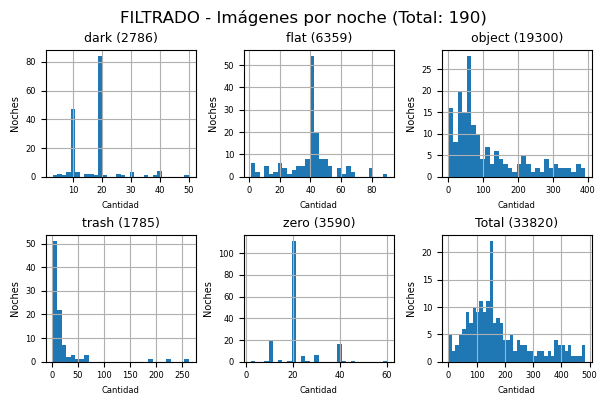

In [197]:
import matplotlib.pyplot as plt

imagetypes = sorted(df["imagetyp"].unique())
n = len(imagetypes)

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

for ax, imagetyp in zip(axes, imagetypes):
    df[df["imagetyp"] == imagetyp].groupby("night").size().hist(ax=ax, bins=30)
    tot = len(df[df["imagetyp"] == imagetyp])
    ax.set_title(f"{imagetyp} ({tot})", fontsize=9)
    ax.set_xlabel("Cantidad", fontsize=6)
    ax.set_ylabel("Noches", fontsize=7)
    
    ax.tick_params(axis='both', labelsize=6)
    
ax = axes[-1]
df.night.value_counts().hist(ax=ax, bins=40)
tot = len(df)
ax.set_title(f"Total ({tot})", fontsize=9)
ax.set_xlabel("Cantidad", fontsize=6)
ax.set_ylabel("Noches", fontsize=7)

ax.tick_params(axis='both', labelsize=6)

# Ajuste fino del espacio horizontal
plt.subplots_adjust(wspace=0.2)  # prueba valores más chicos: 0.1, 0.05
plt.suptitle(f"FILTRADO - Imágenes por noche (Total: {len(df.night.unique())})")
plt.tight_layout(pad=0.5)
plt.show()

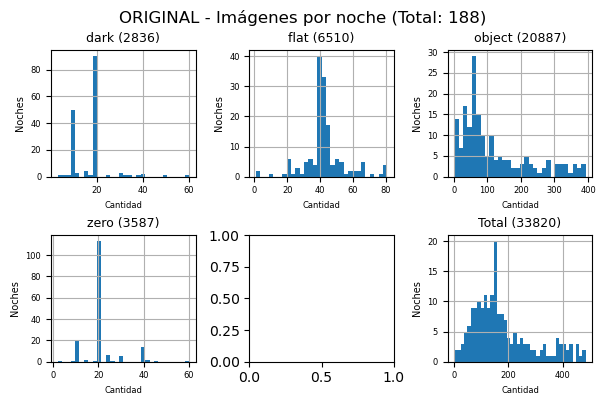

In [467]:
import matplotlib.pyplot as plt

imagetypes = sorted(df["imgtyp_old"].unique())
n = len(imagetypes)

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

for ax, imagetyp in zip(axes, imagetypes):
    df[df["imgtyp_old"] == imagetyp].groupby("night_old").size().hist(ax=ax, bins=30)
    tot = len(df[df["imgtyp_old"] == imagetyp])
    ax.set_title(f"{imagetyp} ({tot})", fontsize=9)
    ax.set_xlabel("Cantidad", fontsize=6)
    ax.set_ylabel("Noches", fontsize=7)
    
    ax.tick_params(axis='both', labelsize=6)
    
ax = axes[-1]
df.night_old.value_counts().hist(ax=ax, bins=40)
tot = len(df)
ax.set_title(f"Total ({tot})", fontsize=9)
ax.set_xlabel("Cantidad", fontsize=6)
ax.set_ylabel("Noches", fontsize=7)

ax.tick_params(axis='both', labelsize=6)

# Ajuste fino del espacio horizontal
plt.subplots_adjust(wspace=0.2)  # prueba valores más chicos: 0.1, 0.05
plt.suptitle(f"ORIGINAL - Imágenes por noche (Total: {len(df.night_old.unique())})")
plt.tight_layout(pad=0.5)
plt.show()

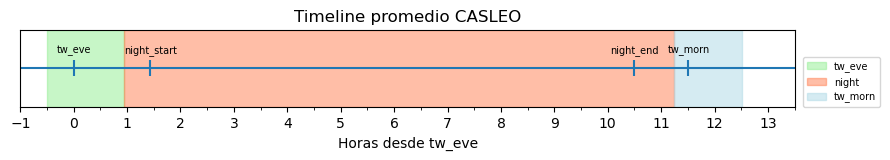

In [512]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Asegurar datetime
cols = ['tw_eve_dt', 'night_start_dt', 'night_end_dt', 'tw_morn_dt']
dfb = df_bit.dropna(subset=cols).copy()

# Convertir a segundos relativos a tw_eve
dfb['t0'] = dfb['tw_eve_dt']

for c in cols:
    dfb[c + '_rel'] = (dfb[c] - dfb['t0']).dt.total_seconds() / 3600.0  # horas

# Promedios
mean_offsets = {
    c: dfb[c + '_rel'].mean()
    for c in cols
}

# eje base (horas desde tw_eve)
t_tw_eve = 0
t_night_start = mean_offsets['night_start_dt']
t_night_end = mean_offsets['night_end_dt']
t_tw_morn = mean_offsets['tw_morn_dt']
# offsets en horas
m20 = 20/60
m30 = 30/60
m45 = 45/60
m60 = 60/60
'''

df['is_night'] = (
    (df['obs_dt'] >= df['night_start_dt'] - pd.Timedelta(minutes=30)) &
    (df['obs_dt'] <= df['night_end_dt'] + pd.Timedelta(minutes=45))
)
df['is_twilight'] = (

    ((df['obs_dt'] > df['tw_eve_dt'] -  pd.Timedelta(minutes=30)) &
     (df['obs_dt'] <= df['night_start_dt'] - pd.Timedelta(minutes=30))) |
    
    ((df['obs_dt'] >= df['night_end_dt'] + pd.Timedelta(minutes=45)) &
     (df['obs_dt'] <= df['tw_morn_dt'] + pd.Timedelta(minutes=60)))
)
'''

# NIGHT
night_start_eff = t_night_start - m30
night_end_eff   = t_night_end + m45

# TWILIGHT (dos bloques)
tw1_start = t_tw_eve - m30
tw1_end   = t_night_start - m30

tw2_start = t_night_end + m45
tw2_end   = t_tw_morn + m60

fig, ax = plt.subplots(figsize=(10, 1))

# Línea base
ax.hlines(0, -1, t_tw_morn + 2)

# Marcas principales
points = {
    "tw_eve": t_tw_eve,
    "night_start": t_night_start,
    "night_end": t_night_end,
    "tw_morn": t_tw_morn
}

for label, x in points.items():
    ax.vlines(x, -0.1, 0.1)
    ax.text(x, 0.2, label, ha='center', fontsize=7)

# Regiones
ax.axvspan(tw1_start, tw1_end, color="lightgreen", label = "tw_eve", alpha=0.5)   # twilight evening
ax.axvspan(night_start_eff, night_end_eff, color="coral", label="night", alpha=0.5)  # night
ax.axvspan(tw2_start, tw2_end, color="lightblue",label = "tw_morn", alpha=0.5)   # twilight morning
ax.legend(loc=(1.01, 0), fontsize=7)
# Labels
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.set_xlim(-1, t_tw_morn + 2)
ax.set_xlabel("Horas desde tw_eve")
ax.set_title("Timeline promedio CASLEO")
from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
plt.show()

In [204]:
fn = df.groupby(["night", "imagetyp"]).size()
flats_per_night = (
    fn.xs("flat", level="imagetyp")  # seleccionar flats
)
all_nights = df["night"].unique()

flats_per_night = flats_per_night.reindex(all_nights, fill_value=0)
nights_wo_flats = flats_per_night[flats_per_night==0]
nights_w_flats = flats_per_night[flats_per_night!=0]
n_wo = len(nights_wo_flats)
n_w = len(nights_w_flats)
mean_w = nights_w_flats.mean()

print(f"Noches sin flats: {n_wo}")
print(f"Noches con flats: {n_w}")
print(f"Promedio de flats por noche (solo noches con flats): {mean_w:.2f}")

flats_per_night = flats_per_night.reindex(all_nights, fill_value=0)
nights_wo_flats = flats_per_night[flats_per_night<20]
nights_w_flats = flats_per_night[flats_per_night>=20]
n_wo = len(nights_wo_flats)
n_w = len(nights_w_flats)
mean_w = nights_w_flats.mean()
print("menos de 20 flats")
print(f"Noches sin flats: {n_wo}")
print(f"Noches con flats: {n_w}")
print(f"Promedio de flats por noche (solo noches con flats): {mean_w:.2f}")


Noches sin flats: 29
Noches con flats: 161
Promedio de flats por noche (solo noches con flats): 41.68
menos de 20 flats
Noches sin flats: 37
Noches con flats: 153
Promedio de flats por noche (solo noches con flats): 43.44


In [205]:
total_nights = len(df.night.unique())
df.groupby(["imagetyp", "wheel"]).size().unstack(fill_value=0).reset_index()

wheel,imagetyp,(1) Free,(2) B,(3) V,(4) R,(5) I
0,dark,60,19,1379,0,1328
1,flat,86,112,3131,155,3227
2,object,5,0,7457,1,11814
3,trash,65,0,559,1,831
4,zero,78,59,1438,20,1995


In [445]:
df["wheel_clean"] = df["wheel"].str.extract(r'([A-Za-z])')

# --- 1. Conteo con filtro (flat_V, object_I, etc.)
fn_filt = (
    df[~df["season"].isna()]
    .groupby(["night", "imagetyp", "wheel_clean"])
    .size()
    .unstack(["imagetyp", "wheel_clean"], fill_value=0)
)

fn_filt.columns = [f"{im}_{wh}" for im, wh in fn_filt.columns]
# asegurar columnas esperadas
expected = ["flat_I", "flat_V", "object_I", "object_V"]
for col in expected:
    if col not in fn_filt.columns:
        fn_filt[col] = 0

# --- 2. Conteo SIN filtro (flat, object, zero, dark)
fn_basic = (
    df[~df["season"].isna()]
    .groupby(["night", "imagetyp"])
    .size()
    .unstack(fill_value=0)
)

# asegurar columnas básicas
for col in ["zero", "dark", "flat", "object"]:
    if col not in fn_basic.columns:
        fn_basic[col] = 0

# --- 3. combinar todo
fn = fn_filt.join(fn_basic[["zero", "dark", "flat", "object"]])

# --- 4. orden final
cols_order = [
    "zero", "dark",
    "flat_I", "flat_V", "flat",
    "object_I", "object_V", "object"
]

fn = fn[[c for c in cols_order if c in fn.columns]]
fn = fn.sort_index()
fn_new = fn.copy()

fn_filt = (
    df[~df["season"].isna()]
    .groupby(["night", "imgtyp_old", "wheel_clean"])
    .size()
    .unstack(["imgtyp_old", "wheel_clean"], fill_value=0)
)

fn_filt.columns = [f"{im}_{wh}" for im, wh in fn_filt.columns]
# asegurar columnas esperadas
expected = ["flat_I", "flat_V", "object_I", "object_V"]
for col in expected:
    if col not in fn_filt.columns:
        fn_filt[col] = 0

# --- 2. Conteo SIN filtro (flat, object, zero, dark)
fn_basic = (
    df[~df["season"].isna()]
    .groupby(["night", "imgtyp_old"])
    .size()
    .unstack(fill_value=0)
)

# asegurar columnas básicas
for col in ["zero", "dark", "flat", "object"]:
    if col not in fn_basic.columns:
        fn_basic[col] = 0

# --- 3. combinar todo
fn = fn_filt.join(fn_basic[["zero", "dark", "flat", "object"]])

# --- 4. orden final
cols_order = [
    "zero", "dark",
    "flat_I", "flat_V", "flat",
    "object_I", "object_V", "object"
]

fn = fn[[c for c in cols_order if c in fn.columns]]
fn = fn.sort_index()
fn_old = fn.copy()

In [491]:
import numpy as np
import pandas as pd

# =========================
# 1. PREPARACIÓN
# =========================
df = df[~df["season"].isna()].copy()

df["wheel_clean"] = df["wheel"].str.extract(r'([IV])', expand=False)

def build_type(imgtyp, wheel):
    if imgtyp in ["flat", "object"] and pd.notna(wheel):
        return f"{imgtyp}_{wheel}"
    return imgtyp

df["type_old"] = [build_type(t, w) for t, w in zip(df["imgtyp_old"], df["wheel_clean"])]
df["type_new"] = [build_type(t, w) for t, w in zip(df["imagetyp"], df["wheel_clean"])]

cols = ["flat", "flat_I", "flat_V", "object", "object_I", "object_V", "dark", "zero"]

# =========================
# 2. COUNTS (SIN DUPLICAR)
# =========================
counts_old = df["type_old"].value_counts()
counts_new = df["type_new"].value_counts()

# agregar totales
counts_old["flat"] = counts_old.filter(like="flat_").sum()
counts_old["object"] = counts_old.filter(like="object_").sum()

counts_new["flat"] = counts_new.filter(like="flat_").sum()
counts_new["object"] = counts_new.filter(like="object_").sum()

# =========================
# 3. FN (POR NOCHE)
# =========================
fn_old = (
    df.groupby(["night", "type_old"])
    .size()
    .unstack(fill_value=0)
)

fn_new = (
    df.groupby(["night", "type_new"])
    .size()
    .unstack(fill_value=0)
)

# agregar totales en fn
for fn in [fn_old, fn_new]:
    fn["flat"] = fn.filter(like="flat_").sum(axis=1)
    fn["object"] = fn.filter(like="object_").sum(axis=1)

# asegurar columnas
for fn in [fn_old, fn_new]:
    for c in cols:
        if c not in fn.columns:
            fn[c] = 0
    fn = fn[cols]

# =========================
# 4. MÉTRICAS
# =========================
thr = 10

def compute_metrics(fn, counts):
    has_obj = (fn["object"] > 0)
    
    rows = []
    for t in cols:
        row = {
            "type": t,
            "count": counts.get(t, 0),
            ">=10": (fn[t] >= thr).sum(),
            "<10": ((fn[t] < thr) & (fn[t] > 0)).sum(),
            "==0": (fn[t] == 0).sum(),
            ">=10_with_obj": ((fn[t] >= thr) & has_obj).sum(),
        }
        rows.append(row)
    return pd.DataFrame(rows)

summary_old = compute_metrics(fn_old, counts_old)
summary_new = compute_metrics(fn_new, counts_new)

# =========================
# 5. TABLA FINAL
# =========================
def pct(old, new):
    return 0 if old == 0 else (new - old) / old * 100

metrics = ["count", "==0", "<10", ">=10", ">=10_with_obj"]

final_rows = []

for m in metrics:
    row = {}
    for t in cols:
        old = summary_old.loc[summary_old["type"] == t, m].values[0]
        new = summary_new.loc[summary_new["type"] == t, m].values[0]
        
        row[(t, "old")] = int(old)
        row[(t, "new")] = int(new)
        row[(t, "diff")] = int(new - old)
        row[(t, "%")] = f"{pct(new, old):+.1f}%"
    
    final_rows.append(pd.Series(row, name=m))

final_table = pd.DataFrame(final_rows)
# reconstruir columnas como MultiIndex (metric, subcol)
# =========================
# FORMATO FINAL CORRECTO
# =========================

# transponer
final_table_t = final_table.T

# nombrar niveles
final_table_t.index.names = ["type", "stat"]

# convertir index multi → columnas multi (metric, stat)
final_table_t = final_table_t.unstack(level=1)

# ordenar columnas correctamente
subcols = ["old", "new", "diff", "%"]

final_table_t = final_table_t.reindex(
    columns=pd.MultiIndex.from_product([metrics, subcols])
)

# ordenar filas
final_table_t = final_table_t.sort_index()

final_table_t

count                      ==0                  <10            
            old    new   diff      % old new diff       % old new diff   
type                                                                     
dark       2803   2753    -50  +1.8%  25  27    2   -7.4%   6   6    0  \
flat       6248   6261     13  -0.2%  34  27   -7  +25.9%   1   2    1   
flat_I     3160   3173     13  -0.4%  35  30   -5  +16.7%   1   3    2   
flat_V     3088   3088      0  +0.0%  35  30   -5  +16.7%   2   5    3   
object    20172  18827  -1345  +7.1%   9  12    3  -25.0%   9   9    0   
object_I  12378  11586   -792  +6.8%  14  17    3  -17.6%  12  15    3   
object_V   7794   7241   -553  +7.6%  24  28    4  -14.3%  15  18    3   
zero       3526   3529      3  -0.1%  21  21    0   +0.0%   2   2    0   

                 >=10                  >=10_with_obj                   
               %  old  new diff      %           old  new diff      %  
type                                                                   
dark       +0.0%  153  151   -2  +1.3%           149  147   -2  +1.4%  
flat      -50.0%  149  155    6  -3.9%           142  148    6  -4.1%  
flat_I    -66.7%  148  151    3  -2.0%           141  144    3  -2.1%  
flat_V    -60.0%  147  149    2  -1.3%           140  142    2  -1.4%  
object     +0.0%  166  163   -3  +1.8%           166  163   -3  +1.8%  
object_I  -20.0%  158  152   -6  +3.9%           158  152   -6  +3.9%  
object_V  -16.7%  145  138   -7  +5.1%           145  138   -7  +5.1%  
zero       +0.0%  161  161    0  +0.0%           154  153   -1  +0.7%

In [481]:
len(df[~df["season"].isna() & (df["imgtyp_old"]=="zero")] ),len(df[~df["season"].isna() & (df["imagetyp"]=="object")& df["wheel"].isin(["(5) I", "(3) V"])]), len(df[~df["season"].isna() & (df["imgtyp_old"]=="object")].groupby("night").size())

(3526, 18827, 175)

In [493]:
old=0
new=0
for i in ["flat", "object"]:
    old += len(df[~df["season"].isna() & (df["imgtyp_old"]==i)& df["wheel"].isin(["(5) I", "(3) V"])] )
    new += len(df[~df["season"].isna() & (df["imagetyp"]==i)& df["wheel"].isin(["(5) I", "(3) V"])& df["check_status"].str.startswith("OK")] )
for i in ["zero", "dark"]:
    old += len(df[~df["season"].isna() & (df["imgtyp_old"]==i)] )
    new += len(df[~df["season"].isna() & (df["imagetyp"]==i) & df["check_status"].str.startswith("OK")])
new, old, pct(old, new), new-old, (new-old)/old*100

(31370, 32749, -4.210815597422822, -1379, -4.210815597422822)

In [243]:
summary = []

for col in ["zero", "dark"]+expected:
    x = fn[col]

    summary.append({
        "type": col,
        "n_nights_total": len(x),
        "n_nights_with_data": (x > 0).sum(),
        "n_nights_without": (x == 0).sum(),
        "mean_per_night_with_data": x[x > 0].mean(),
        "n_nights_ge_20": (x >= 20).sum(),
        "n_nights_lt_20": (x < 20).sum(),
    })

summary = pd.DataFrame(summary).set_index("type").round(1)
summary.T

type,zero,dark,flat_I,flat_V,object_I,object_V
n_nights_total,190.0,190.0,190.0,190.0,190.0,190.0
n_nights_with_data,166.0,160.0,157.0,156.0,170.0,159.0
n_nights_without,24.0,30.0,33.0,34.0,20.0,31.0
mean_per_night_with_data,21.6,17.4,20.6,20.1,69.5,46.9
n_nights_ge_20,142.0,98.0,131.0,121.0,131.0,124.0
n_nights_lt_20,48.0,92.0,59.0,69.0,59.0,66.0


In [314]:
df[df["season"].isna()]["date-obs"].value_counts()

date-obs
2024-09-15    244
2024-09-14    212
2024-09-16    186
2024-09-13      3
2024-11-15      2
2024-09-21      1
2025-06-22      1
Name: count, dtype: int64

In [367]:
obs_nights = set(df["night"].unique())

season_nights = set(
    pd.to_datetime(seasons_df["date"])
    .dt.strftime("%Y%m%d")
)

extra_nights = sorted(obs_nights - season_nights)

non_ot = pd.DataFrame({"night_outside_season": extra_nights})
non_ot.to_csv("non_season_nights_with_science.csv", index=False)

# =========================
# MÉTRICAS GLOBALES
# =========================
obs_nights_old = set(df[~df["season"].isna() ]["night"])
obs_nights_new = set(df[~df["season"].isna() ]["night"])
obs_nights_old_science = set(df[~df["season"].isna() & (df["imgtyp_old"]=="object")]["night"])
obs_nights_new_science = set(df[~df["season"].isna() & (df["imagetyp"]=="object")]["night"])

n_assigned = len(season_nights)
#
n_missing_old = len(season_nights - obs_nights_old)
n_missing_new = len(season_nights - obs_nights_new)
n_missing_old_science = len(season_nights - obs_nights_old_science)
n_missing_new_science = len(season_nights - obs_nights_new_science)
n_observed_new = len(df[~df["season"].isna()].groupby("night").size())
n_observed_old = len(df[~df["season"].isna()].groupby("night").size())
n_observed_new_science = len(df[~df["season"].isna() & (df["imagetyp"]=="object")].groupby("night").size())
n_observed_old_science = len(df[~df["season"].isna() & (df["imgtyp_old"]=="object")].groupby("night").size())


print(f"Noches asignadas: {n_assigned}")

global_summary = pd.DataFrame({
    "metric": [
        "Observadas",
        "Perdidas",
        "Observadas con ciencia",
        "Perdidas con ciencia"
    ],
    "Original": [
        n_observed_old,
        n_missing_old,
        n_observed_old_science,
        n_missing_old_science
    ],
    "Filtro 0": [
        n_observed_new,
        n_missing_new,
        n_observed_new_science,
        n_missing_new_science
    ]
})

global_summary

Noches asignadas: 210


,metric,Original,Filtro 0
0,Observadas,184,184
1,Perdidas,26,26
2,Observadas con ciencia,175,172
3,Perdidas con ciencia,35,38


In [362]:
df.groupby("imgtyp_old").agg(
    total=("file_old", "size"),
    
    not_night=("is_night", lambda x: (~x).sum()),
    not_twilight=("is_twilight", lambda x: (~x).sum()),
    
    not_early_twilight=("is_twilight_tol", 
        lambda x: (~((x) & (~df.loc[x.index, "is_twilight"]))).sum()),
    
    not_early_night=("is_night_tol", 
        lambda x: (~((x) & (~df.loc[x.index, "is_night"]))).sum()),
    
    not_close_match=("close_match", lambda x: (~x).sum()),
    
    exptime_lt10=("exptime", lambda x: (x < 10).sum()), 
    exptime_gt10_lt50=("exptime", lambda x: ((x >= 10) & (x < 50)).sum()), 
    exptime_ge50=("exptime", lambda x: (x >= 50).sum())

).T

imgtyp_old,dark,flat,object,zero
total,2803,6411,20431,3526
not_night,1374,6385,1150,2031
not_twilight,1965,937,19338,1828
not_early_twilight,2445,5505,20374,3272
not_early_night,2245,6395,19796,2765
not_close_match,2712,6328,991,2863
exptime_lt10,30,6061,1007,3524
exptime_gt10_lt50,20,297,168,0
exptime_ge50,2753,53,19256,2


#### Flats analysis

Text(0.5, 1.0, 'Distribución de exptime por noche (stacked)')

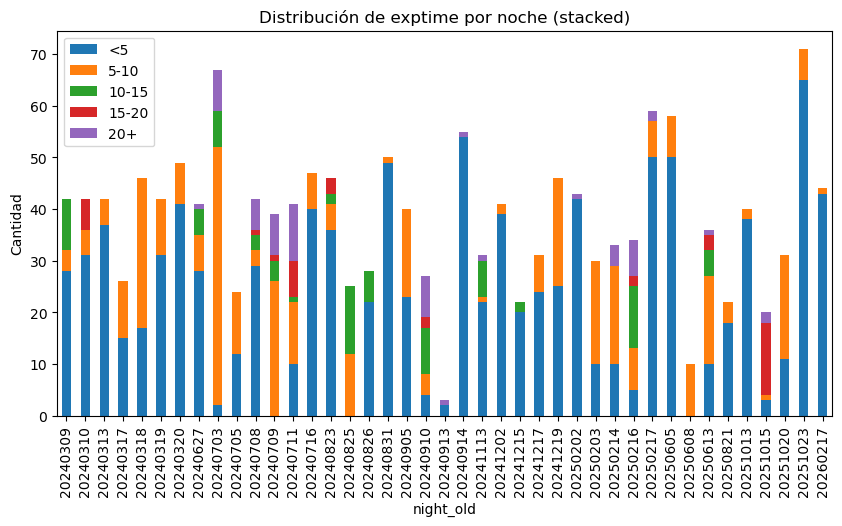

In [445]:
f = (
    df[(df["imagetyp"] == "flat")&(df["wheel"].isin(["(3) V", "(5) I"]))]
    .groupby("night_old")["exptime"]
    .agg(
        ok = lambda x: (x <= 5).sum(),
        f5  = lambda x: (x > 5).sum(),
        f10 = lambda x: (x > 10).sum(),
        f15 = lambda x: (x > 15).sum(),
        f20 = lambda x: (x > 20).sum(),
        max = lambda x: x.max()
    )
)

f = f.loc[ f[["f5", "f10", "f15", "f20"]].sum(axis=1) > 0 ]
stacked = f.copy()
stacked["<5"] = stacked["ok"]
stacked["5-10"]  = stacked["f5"]  - stacked["f10"]
stacked["10-15"] = stacked["f10"] - stacked["f15"]
stacked["15-20"] = stacked["f15"] - stacked["f20"]
stacked["20+"]   = stacked["f20"]

stacked = stacked[["<5", "5-10", "10-15", "15-20", "20+"]]
ax = stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

ax.set_xlabel("night_old")
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de exptime por noche (stacked)")

In [418]:
f[f.ok<20]

,ok,f5,f10,f15,f20,max
night_old,,,,,,
20240317,15,11,0,0,0,8.0
20240318,17,29,0,0,0,10.0
20240703,2,65,15,8,8,35.0
20240705,12,12,0,0,0,6.0
20240709,0,39,13,9,8,50.0
20240711,10,31,19,18,11,60.0
20240825,0,25,13,0,0,15.0
20240910,4,23,19,10,8,35.0
20240913,2,1,1,1,1,120.0


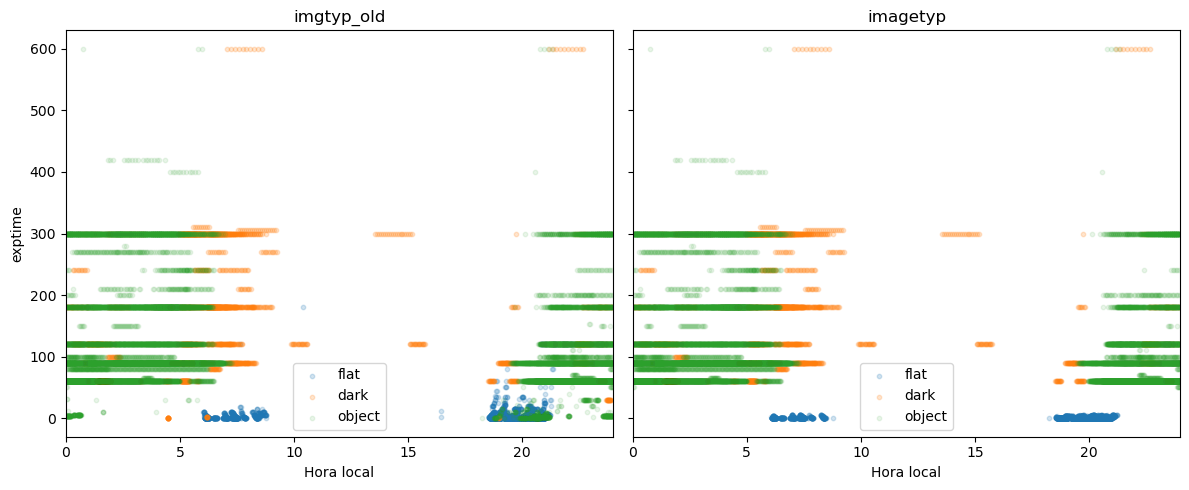

In [132]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, col in zip(axs, ["imgtyp_old", "imagetyp"]):
    
    for typ, alpha in zip(["flat", "dark", "object"], [0.2, 0.2, 0.1]):
        d = df[(df[col] == typ) & (df["wheel"].isin(["(3) V", "(5) I"]))].copy()
        
        d["hour"] = d["time-local"].apply(lambda t: t.hour + t.minute/60 + t.second/3600)
        
        ax.scatter(d["hour"], d["exptime"], s=10, alpha=alpha, label=typ)
    
    ax.set_xlabel("Hora local")
    ax.set_xlim(0, 24)
    ax.set_title(col)
    ax.legend()

axs[0].set_ylabel("exptime")

plt.tight_layout()

In [133]:
count = (
    df.groupby(["imagetyp", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
count

wheel,(1) Free,(2) B,(3) V,(4) R,(5) I
imagetyp,,,,,
dark,60,19,1379,0,1328
flat,75,112,2995,145,3032
object,6,0,7505,1,12040
trash,75,0,647,11,800
zero,78,59,1438,20,1995


In [167]:
count = (
      df[df["object"].str.contains("0034")&~df["object"].isna()&(df["imagetyp"]=="object")]
      .groupby(["night", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
count

wheel,(3) V,(5) I
night,,
2024-03-14,3,3
2024-03-19,7,7
2025-06-03,50,46
2025-06-05,39,36
2025-06-07,0,22
2025-06-08,16,28
2025-06-14,10,9
2025-06-16,15,14
2025-06-18,32,30


In [166]:
df[df["object"].str.contains("0034")&(df["night"]=="2025-06-16")][["file", "exptime", "file_old"]]

,file,exptime,file_old
26632,OGLE-2024-BLG-0034_v0015.fit,120,OGLE-2024-BLG-0034v0002.fit
26633,OGLE-2024-BLG-0034_v0016.fit,120,OGLE-2024-BLG-0034v0003.fit
26631,OGLE-2024-BLG-0034_v0014.fit,120,OGLE-2024-BLG-0034v0001.fit
26634,OGLE-2024-BLG-0034_v0017.fit,120,OGLE-2024-BLG-0034v0004.fit
26619,trash_OGLE-2024-BLG-0034i0189.fit,4,OGLE-2024-BLG-0034i0189.fit
...,...,...,...
26489,trash_OGLE-2024-BLG-0034i0059.fit,4,OGLE-2024-BLG-0034i0059.fit
26494,trash_OGLE-2024-BLG-0034i0064.fit,4,OGLE-2024-BLG-0034i0064.fit
26495,trash_OGLE-2024-BLG-0034i0065.fit,4,OGLE-2024-BLG-0034i0065.fit
26496,trash_OGLE-2024-BLG-0034i0066.fit,4,OGLE-2024-BLG-0034i0066.fit


In [ ]:
sky_cols = ['ra2000', 'dec2000', 'ra', 'dec']
detector_cols = [
    "gain", "rdnoise", "camtem", "detector", "adcrate"
]
datetime_cols = [
    "date", "date-obs", "time-obs", "ut", "mjd-obs", "st"
]
pointing_cols = [
    "ra", "dec", "ra2000", "dec2000", "equinox",
    "ha", "zd", "airmass"
]
telescope_cols = [
    "observat", "telescop", "dome-az", "optele"
]
obs_set_cols = [ "filter", "filter1", "filter01", "filter02",
    "imagetyp", "exptime", 
]
#filter_cols = [ "filter", "filter1", "filter01", "filter02"]
filter_cols = ["wheel", "wheel_aux"]
for col in obs_set_cols:
    print(df[col].value_counts())

filter
(5) I       12148
(3) V        8344
(1) Free      116
(4) R         116
(2) B          99
Name: count, dtype: int64
filter1
(6) Free       20811
(4) H-Alpha       10
(5) ND213B         2
Name: count, dtype: int64
filter01
(5) I       7287
(3) V       5818
(1) Free     180
(2) B         91
(4) R         61
Name: count, dtype: int64
filter02
(6) Free       12298
(2) Blind        865
(3) Blind        193
(5) ND213B        41
(4) H-Alpha       20
(1) U             20
Name: count, dtype: int64
imagetyp
object    20628
flat       7167
zero       3609
dark       2856
Name: count, dtype: int64
exptime
60.00     7059
90.00     5883
0.00      3612
120.00    3060
180.00    2760
          ... 
45.00        1
0.23         1
3.80         1
61.00        1
11.00        1
Name: count, Length: 112, dtype: int64


In [149]:
import os
os.listdir()

['season_nights_without_science.csv',
 'actions_copy_calib_images.csv',
 'rename_commands.sh',
 'analyze_image_collection.ipynb',
 'image_classification_criteria.csv',
 'season_HSH-2024A-03_band_V.png',
 'non_season_nights_with_science.csv',
 'nights_images_count.csv',
 'image_collection_clean.csv',
 'season_HSH-2024B-05_band_V.png',
 'season_HSH-2025B-03_band_I.png',
 'season_HSH-2025A-05_band_V.png',
 'season_2026A_band_I.png',
 'season_HSH-2025A-05_band_I.png',
 'image_collection_original.csv',
 'bitacora_CASLEO.csv',
 'season_HSH-2024B-05_band_I.png',
 'move_commands.sh',
 'season_2026A_band_V.png',
 'season_HSH-2025B-03_band_V.png',
 'hsh_seasons_calendar.csv',
 'season_HSH-2024A-03_band_I.png']

#### Sky map

-72.81730555555555 21.513833333333334
0.02333333333333333 359.64833333333326


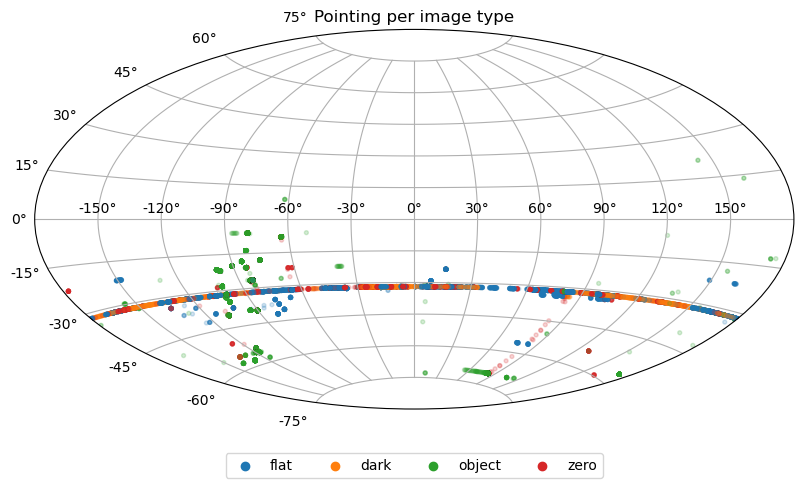

In [150]:
from astropy.coordinates import SkyCoord
import astropy.units as u


coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df['imagetyp'].unique()

# Definir un colormap discreto
cmap = plt.get_cmap('tab10')  # bueno para <=10 categorías
colors = {t: cmap(i) for i, t in enumerate(types)}

# Crear array de colores alineado con los puntos
point_colors = df['imagetyp'].map(colors)

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                c=point_colors,
                alpha=0.2, 
                s=8)

ax.grid(True)
ax.set_title("Pointing per image type")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
          ncol=min(len(types), 4))

plt.tight_layout()
plt.show()

-70.14630555555556 -6.077166666666667
78.22208333333332 297.01041666666663


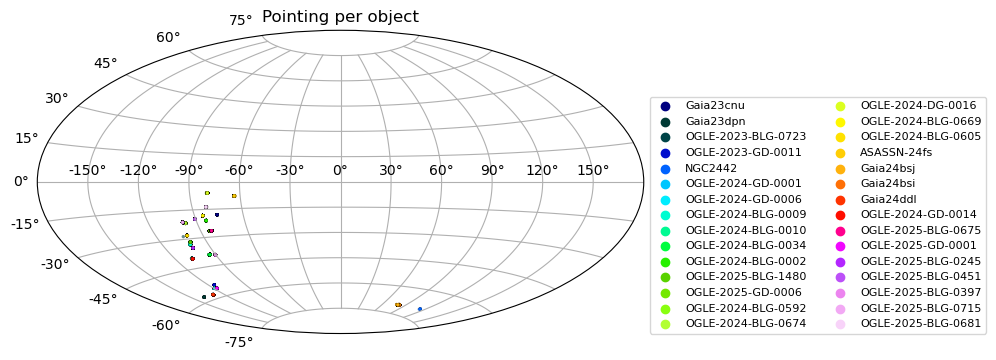

In [44]:
from astropy.coordinates import SkyCoord
import astropy.units as u


df_object = df[df["imagetyp"] == "object"]
df_object = df_object[df_object['object'] != "NO_OBJECT"].copy()
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df_object['object'].unique()


#cmap = plt.get_cmap('tab10')
#colors = {t: cmap(i) for i, t in enumerate(types)}
#point_colors = df_object['object'].map(colors)

N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = df_object['object'].map(colors)


# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                marker=".",
                c=point_colors,
                alpha=0.6, 
                edgecolor="black",
                linewidths=0.1,
                s=20)

ax.grid(True)
ax.set_title("Pointing per object")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc=(1.01,0), ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

Dec min/max hemisferio sur: -70.14630555555556 -6.077166666666667
RA min/max hemisferio sur: 78.22208333333332 297.01041666666663


/tmp/ipykernel_59583/1395061380.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


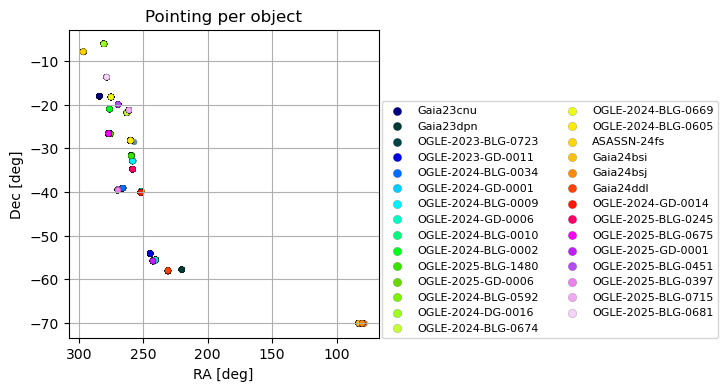

In [156]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Filtrar objetos válidos
df_object = df[df["imagetyp"] == "object"].copy()
df_object = df_object[df_object['object'] != "NO_OBJECT"]

# Coordenadas
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))

# Solo hemisferio sur
mask_south = coords.dec.deg <= 0
ra_south = coords.ra.deg[mask_south]
dec_south = coords.dec.deg[mask_south]
objects_south = df_object['object'][mask_south]

print("Dec min/max hemisferio sur:", dec_south.min(), dec_south.max())
print("RA min/max hemisferio sur:", ra_south.min(), ra_south.max())

# Colores
types = objects_south.unique()
N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = objects_south.map(colors)

# Plot cartesiano
fig, ax = plt.subplots(figsize=(4,4))
sc = ax.scatter(
    ra_south, dec_south,
    c=point_colors,
    edgecolor="black",
    linewidths=0.1,
    alpha=0.6,
    s=18,
    #marker="."
)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Pointing per object")
ax.invert_xaxis()  # opcional: RA decreciente
ax.grid(True)

# Leyenda
for t in types:
    ax.scatter([], [], c=[colors[t]], edgecolor="black", linewidths=0.1, label=t)
ax.legend(loc=(1.01,0), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


/tmp/ipykernel_12173/1776295315.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_object = df_object[(df["object"].str.startswith("Gaia"))|(df["object"].str.startswith("OGLE"))


Dec min/max hemisferio sur: -70.14630555555556 -6.077166666666667
RA min/max hemisferio sur: 79.48499999999999 296.6395833333333


/tmp/ipykernel_12173/1776295315.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


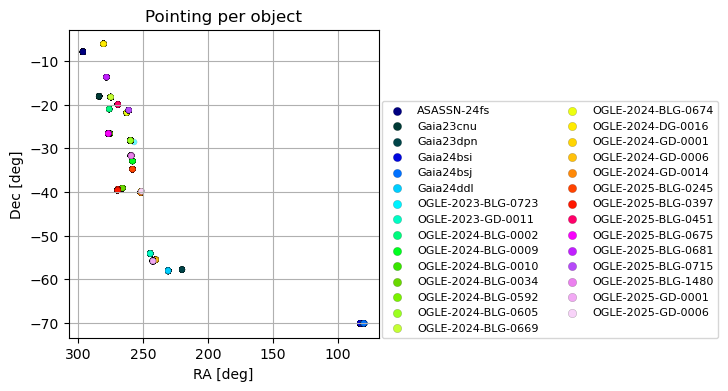

In [248]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Filtrar objetos válidos
df_object = df[df["imagetyp"] == "object"].copy()
df_object = df_object[(df["object"].str.startswith("Gaia"))|(df["object"].str.startswith("OGLE"))
                      |(df["object"].str.startswith("ASASSN"))].sort_values("object")

# Coordenadas
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))

# Solo hemisferio sur
mask_south = coords.dec.deg <= 0
ra_south = coords.ra.deg[mask_south]
dec_south = coords.dec.deg[mask_south]
objects_south = df_object['object'][mask_south]

print("Dec min/max hemisferio sur:", dec_south.min(), dec_south.max())
print("RA min/max hemisferio sur:", ra_south.min(), ra_south.max())

# Colores
types = objects_south.unique()
N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = objects_south.map(colors)

# Plot cartesiano
fig, ax = plt.subplots(figsize=(4,4))
sc = ax.scatter(
    ra_south, dec_south,
    c=point_colors,
    edgecolor="black",
    linewidths=0.1,
    alpha=0.6,
    s=18,
    #marker="."
)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Pointing per object")
ax.invert_xaxis()  # opcional: RA decreciente
ax.grid(True)

# Leyenda
for t in types:
    ax.scatter([], [], c=[colors[t]], edgecolor="black", linewidths=0.1, label=t)
ax.legend(loc=(1.01,0), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


### Metadata

In [ ]:
import os
import json
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u


data_dir = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/microlensing_data"
csv_file = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

df_csv = pd.read_csv(csv_file)
objetos_existentes = {obj: idx for idx, obj in enumerate(df_csv['objeto'])}
for fname in os.listdir(data_dir):
    if fname.endswith(".json"):
        path = os.path.join(data_dir, fname)
        with open(path, "r") as f:
            data = json.load(f)
        objeto = fname.split("_")[0]   
        ra_str = data["RA"]
        dec_str = data["Dec"]
        coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))
        ra_deg = coord.ra.deg
        dec_deg = coord.dec.deg
        if objeto not in objetos_existentes:
            # Agregar objeto nuevo
            df_csv = pd.concat([
                df_csv,
                pd.DataFrame({
                    "objeto": [objeto],
                    "ra_deg": [ra_deg],
                    "dec_deg": [dec_deg],
                    "ra_ecu": [ra_str],
                    "dec_ecu": [dec_str]
                })
            ], ignore_index=True)

df_csv.to_csv(csv_file, index=False)
print("objetos.csv actualizado con todos los targets de microlensing_data")


objetos.csv actualizado con todos los targets de microlensing_data


#### Seasons file

In [242]:
import pandas as pd
from datetime import datetime
# CREAR DATASETSS
rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# =========================
# HSH-2024A-03 (40 noches)
# =========================
add_range("HSH-2024A-03", "2024-03-01", "2024-03-20")
add_range("HSH-2024A-03", "2024-06-27", "2024-07-16")

# =========================
# HSH-2024B-05 (60 noches)
# =========================
add_range("HSH-2024B-05", "2024-08-23", "2024-09-12")
add_range("HSH-2024B-05", "2024-11-02", "2024-11-06")
add_range("HSH-2024B-05", "2024-11-10", "2024-11-13")
add_range("HSH-2024B-05", "2024-11-17", "2024-11-25")
add_range("HSH-2024B-05", "2024-11-30", "2024-12-11")
add_range("HSH-2024B-05", "2024-12-15", "2024-12-23")  # incluyendo dic/23 observado

# =========================
# HSH-2025A-05 (40 noches)
# =========================
add_range("HSH-2025A-05", "2025-02-01", "2025-02-12")
add_range("HSH-2025A-05", "2025-02-14", "2025-02-20")
add_range("HSH-2025A-05", "2025-06-01", "2025-06-21")

# =========================
# HSH-2025B-03  (56 noches)
# =========================
add_range("HSH-2025B-03", "2025-08-20", "2025-08-27")
add_range("HSH-2025B-03", "2025-09-15", "2025-09-30")
add_range("HSH-2025B-03", "2025-10-13", "2025-10-24")
add_range("HSH-2025B-03", "2025-10-26", "2025-10-30")
add_range("HSH-2025B-03", "2025-11-18", "2025-11-22")
add_range("HSH-2025B-03", "2025-12-17", "2025-12-21")
add_range("HSH-2025B-03", "2026-01-12", "2026-01-16")

# =========================
# HSH-2025B-03 en 2026A
# =========================
add_range("2026A", "2026-02-09", "2026-02-17", program="HSH")
add_range("2026A", "2026-02-24", "2026-02-28", program="HSH")

'''
add_range("2026A", "2026-07-08", "2026-07-09", program="HSH")
add_range("2026A", "2026-07-10", "2026-07-10", program="HSH")
add_range("2026A", "2026-07-11", "2026-07-12", program="HSH")
add_range("2026A", "2026-07-13", "2026-07-13", program="HSH")
add_range("2026A", "2026-07-14", "2026-07-16", program="HSH")
add_range("2026A", "2026-07-17", "2026-07-17", program="HSH")
add_range("2026A", "2026-07-18", "2026-07-21", program="HSH")
'''
# Crear DataFrame
seasons_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

# Guardar CSV
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print(seasons_df.season.value_counts())
print("Total noches:", len(seasons_df))


season
HSH-2024B-05    60
HSH-2025B-03    56
HSH-2024A-03    40
HSH-2025A-05    40
2026A           14
Name: count, dtype: int64
Total noches: 210


In [ ]:
import pandas as pd
# AGREGAR NUEVAS SEASONS
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# 2️⃣ Crear lista temporal para nuevos rangos
new_rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        new_rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# add_range("HSH-2025B-03", "2026-02-09", "2026-02-17", program="HSH-PLP")

new_df = pd.DataFrame(new_rows)
seasons_df = (
    pd.concat([seasons_df, new_df])
      .drop_duplicates(subset=["season", "date", "program"])
      .sort_values("date")
      .reset_index(drop=True)
)

# 5️⃣ Guardar nuevamente
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print("Total noches actualizado:", len(seasons_df))

Total noches actualizado: 224


### Todas las observaciones

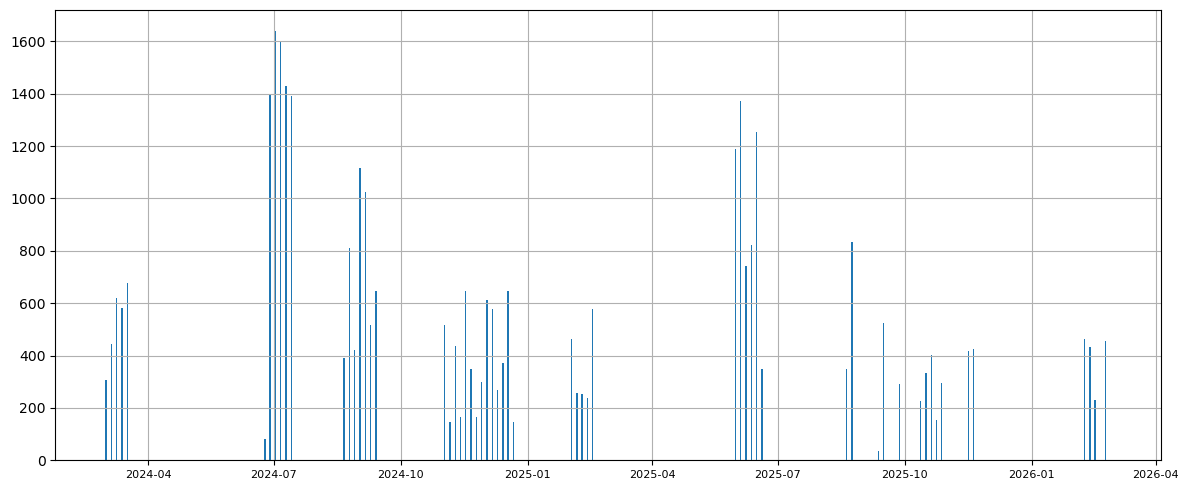

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
plt.figure(figsize=(12,5))
df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")
ax = df["night"].hist(bins=len(df["night"].value_counts().keys()), width=1)
#ax1 = ax.twinx()
#ax1.plot(df["night"], df["airmass"], "rs", markersize=1)

ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()


Plotting season: HSH-2024A-03


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


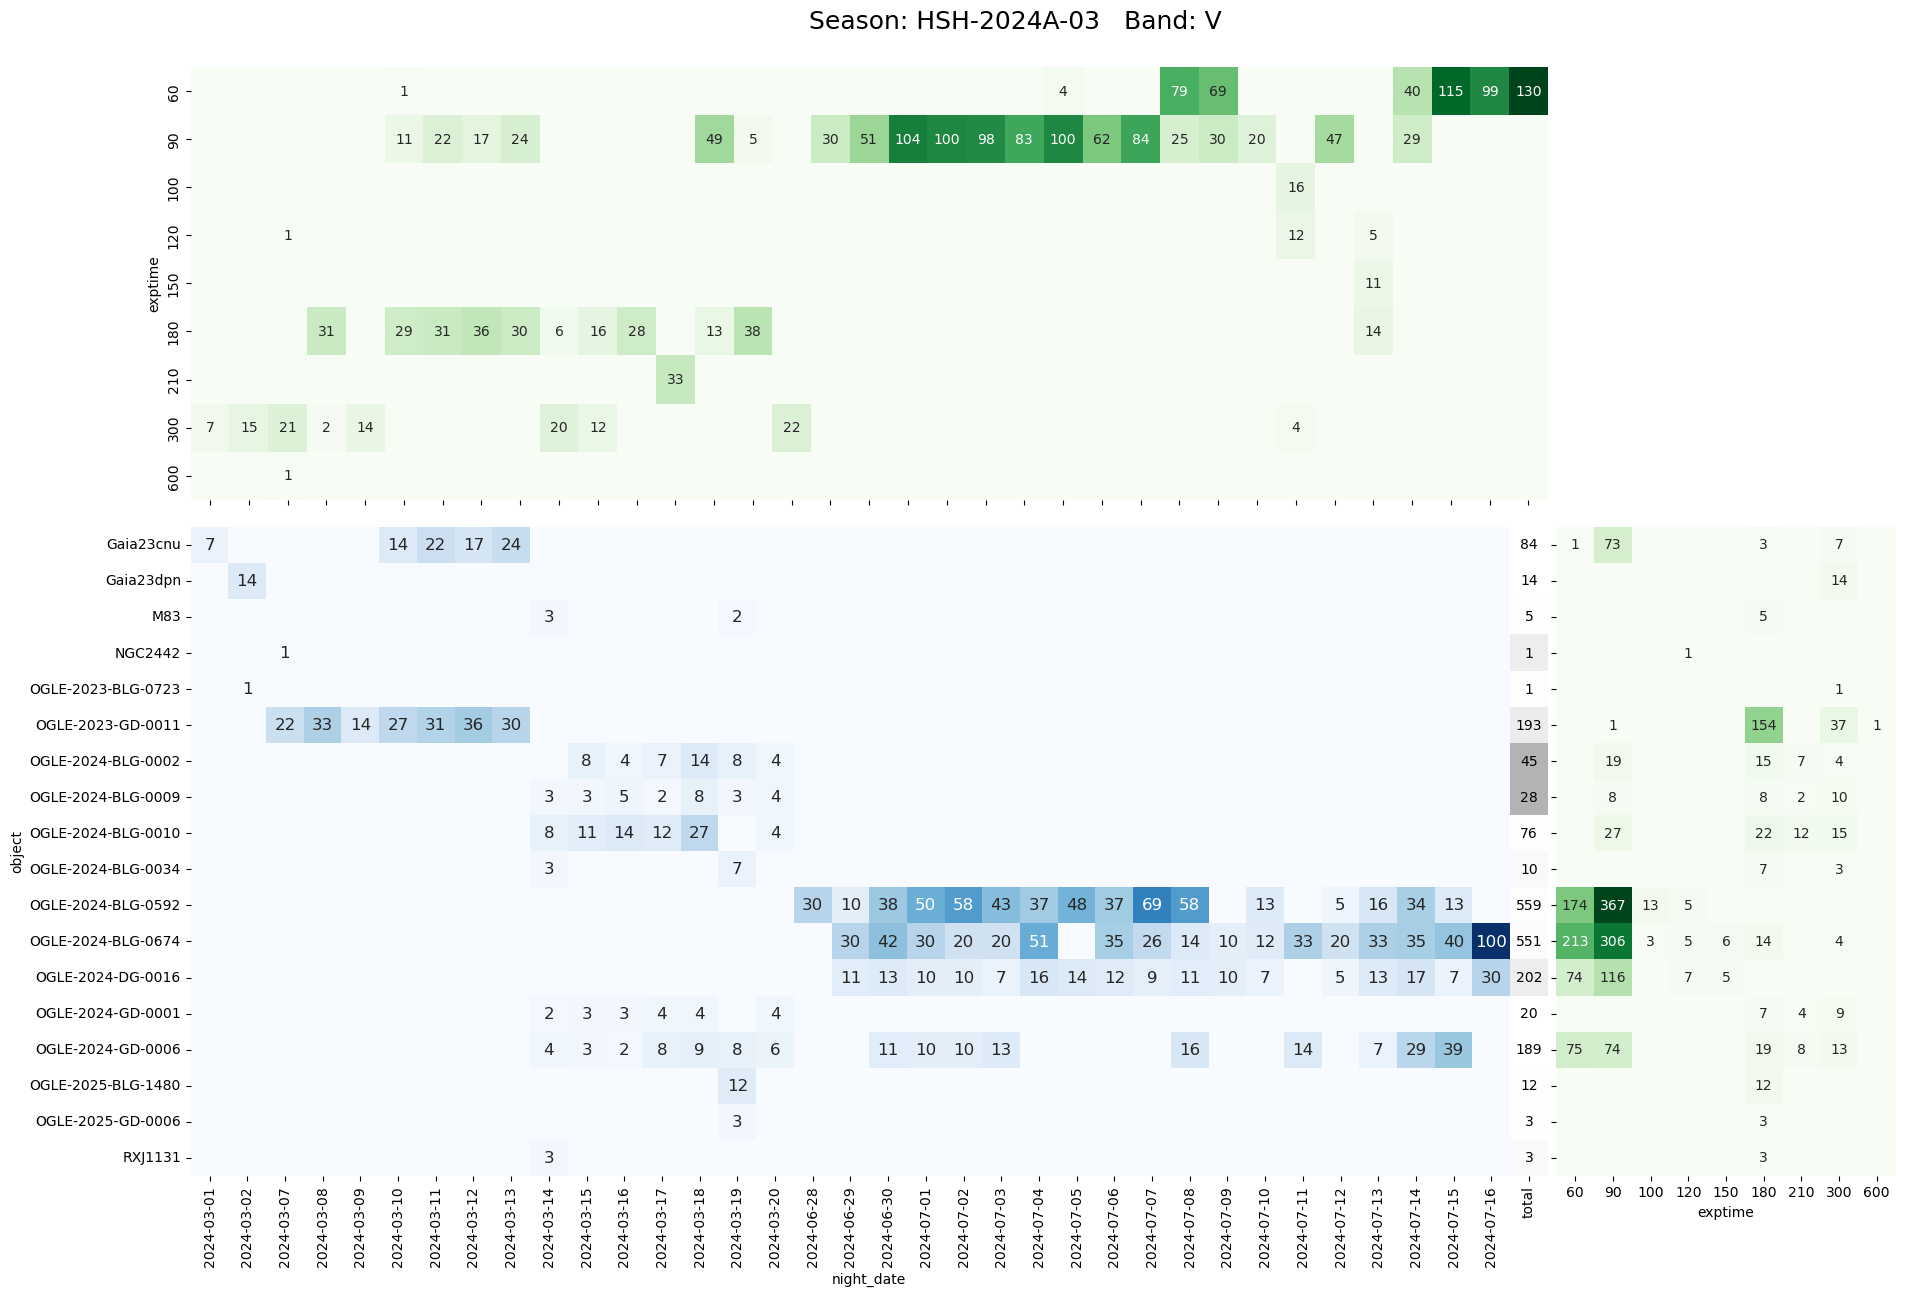

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


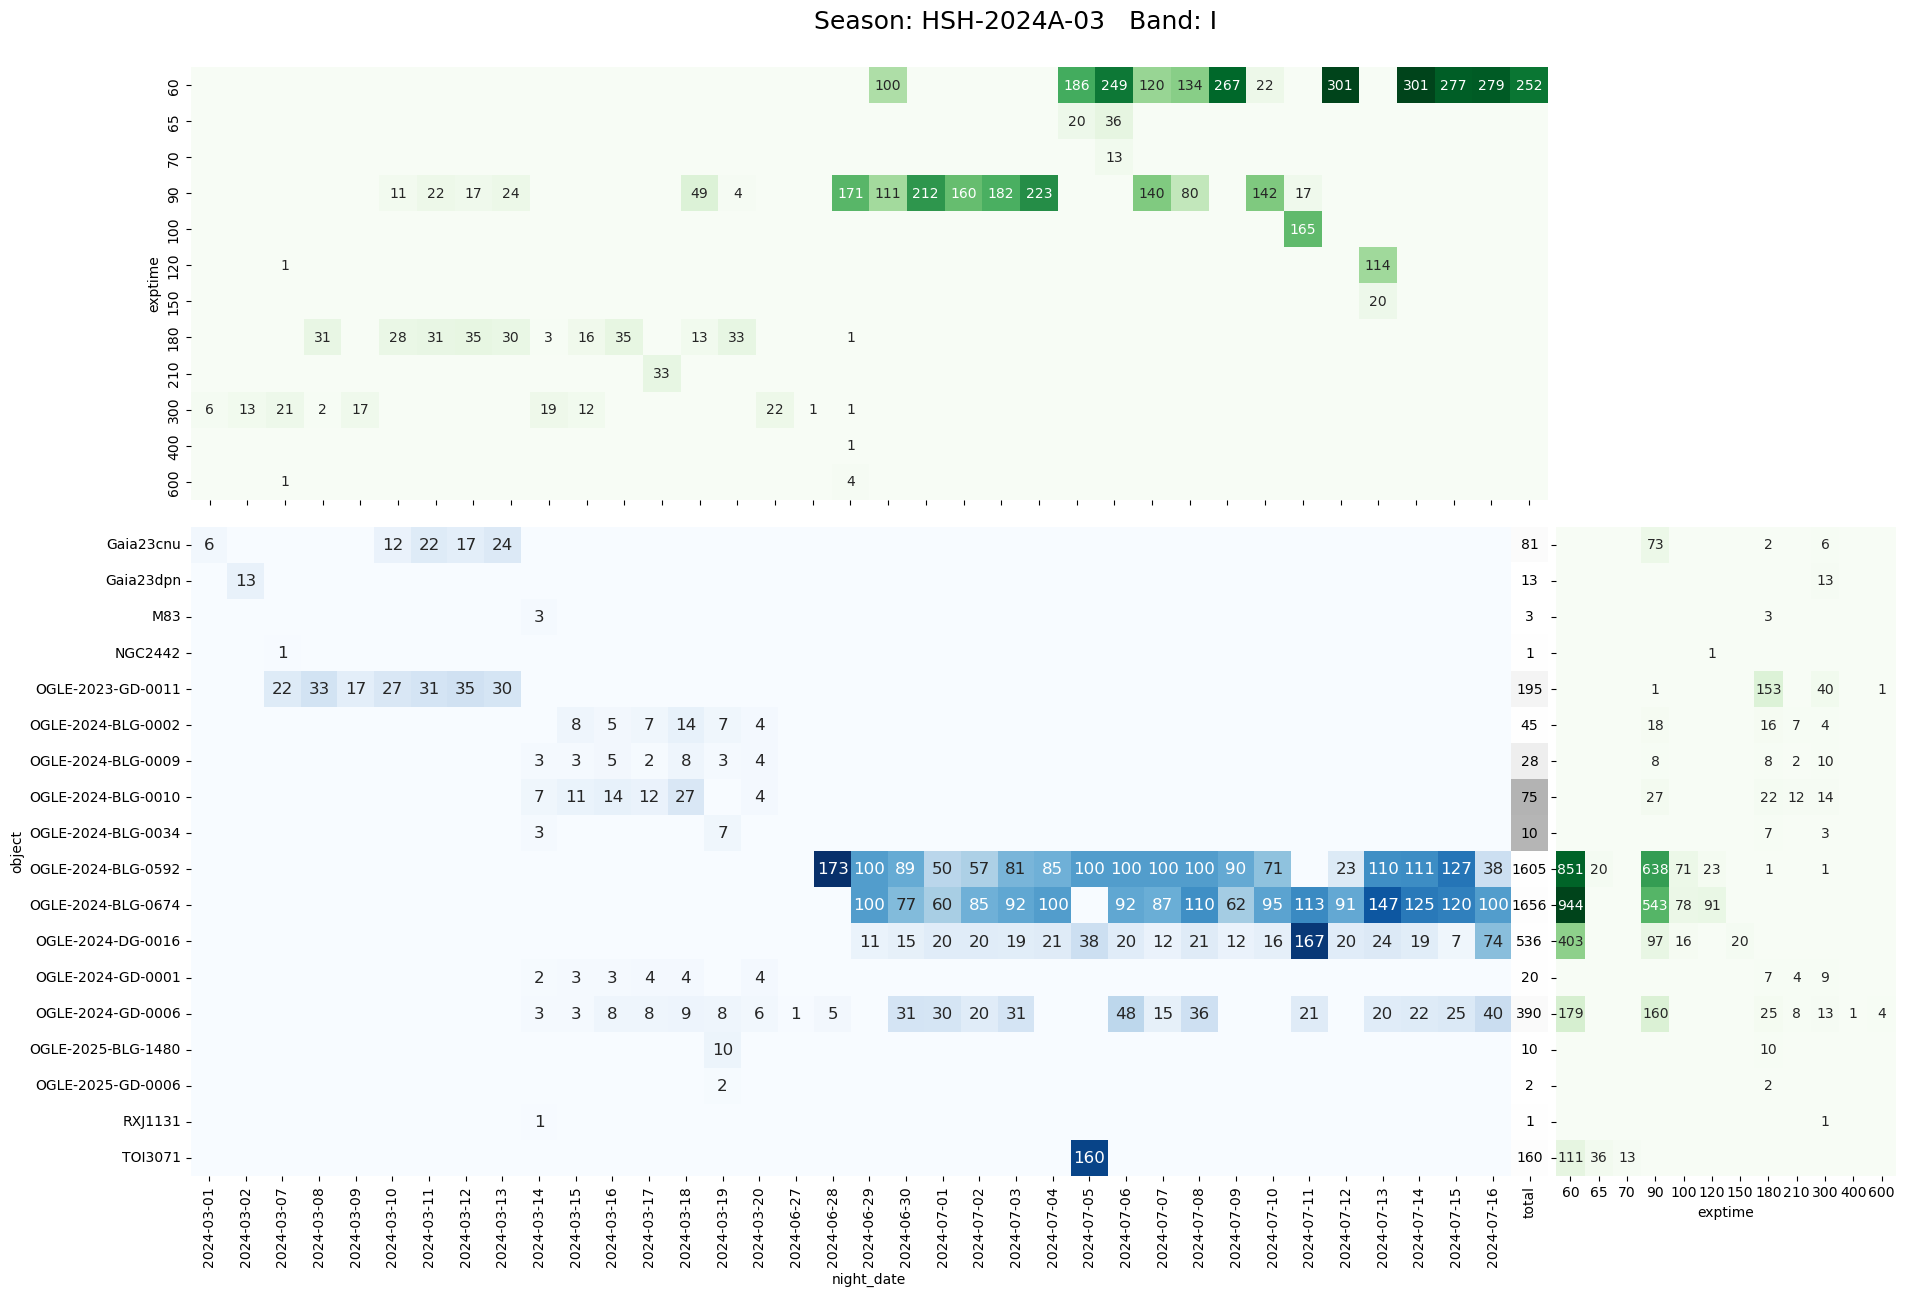

Plotting season: HSH-2024B-05


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


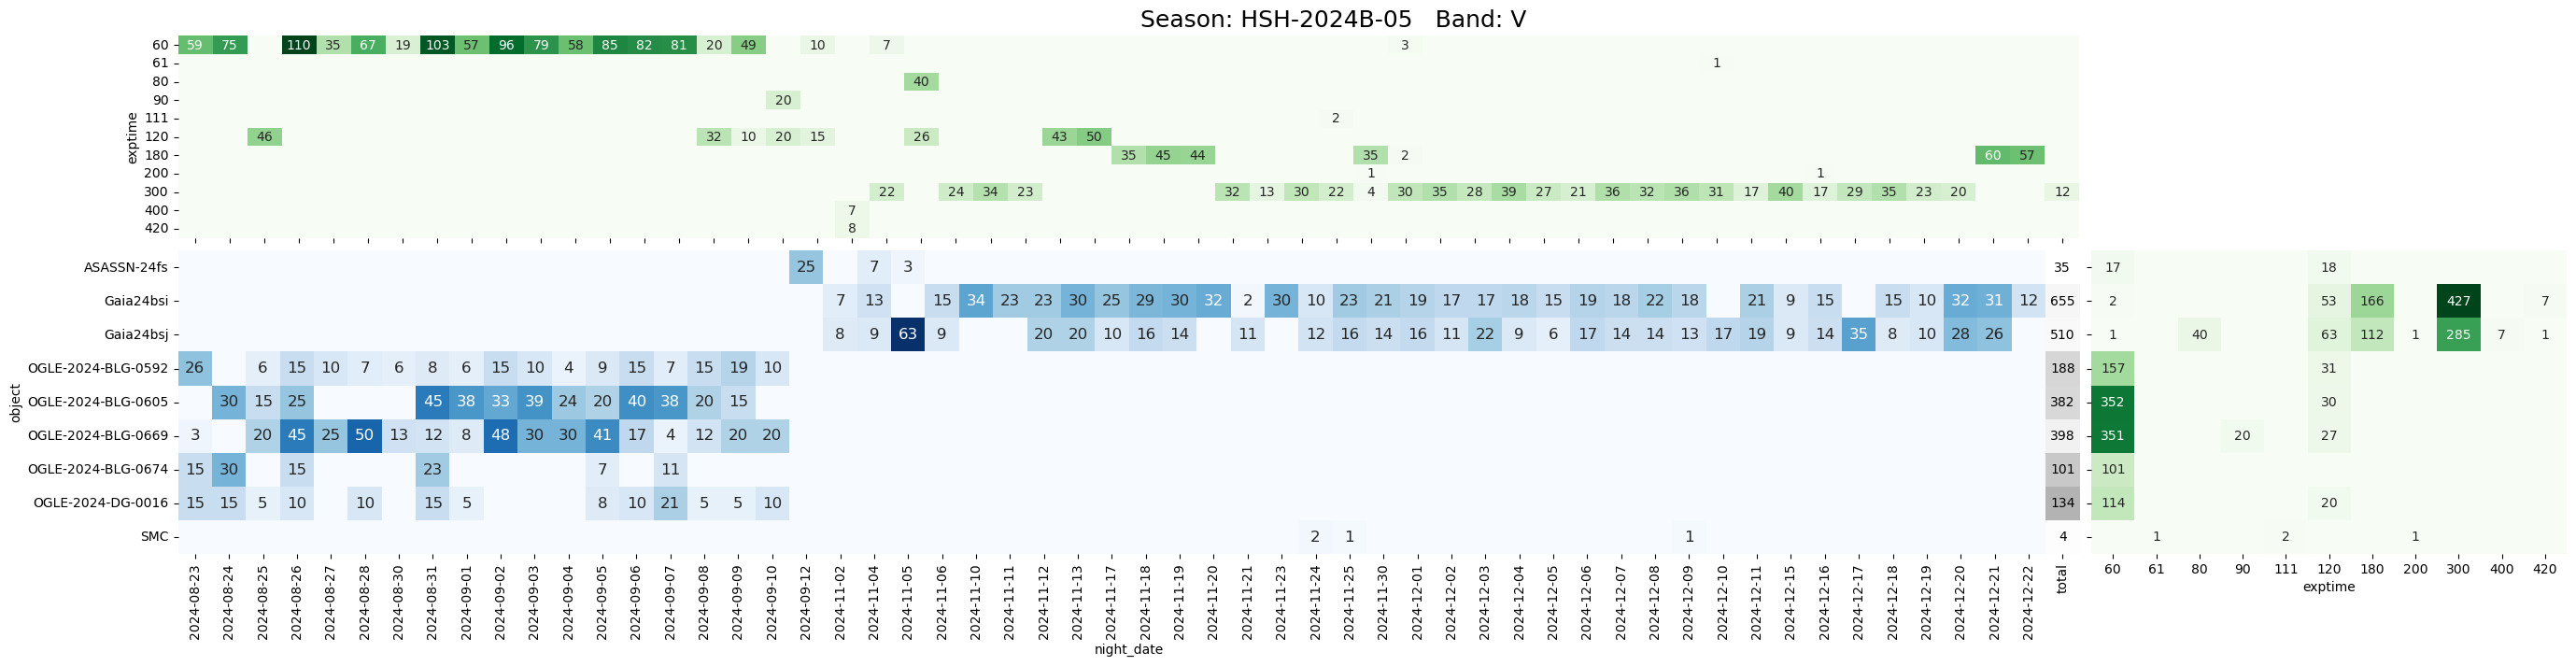

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


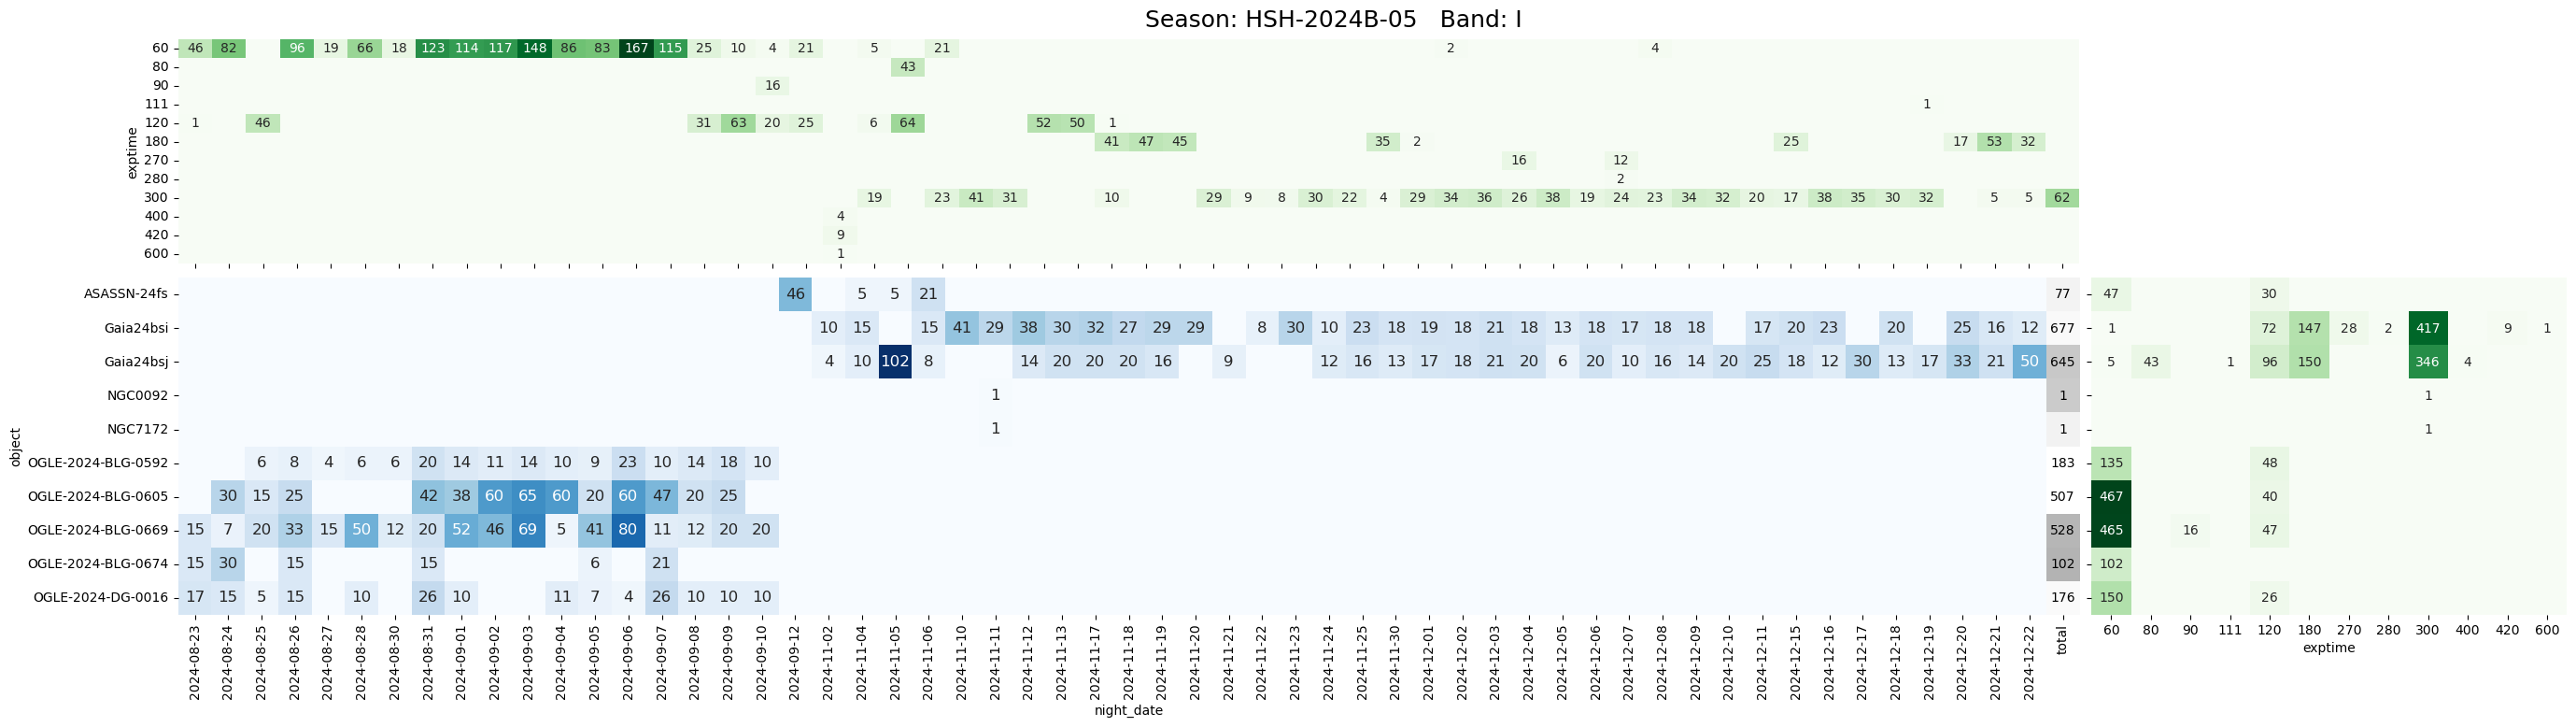

Plotting season: HSH-2025A-05


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


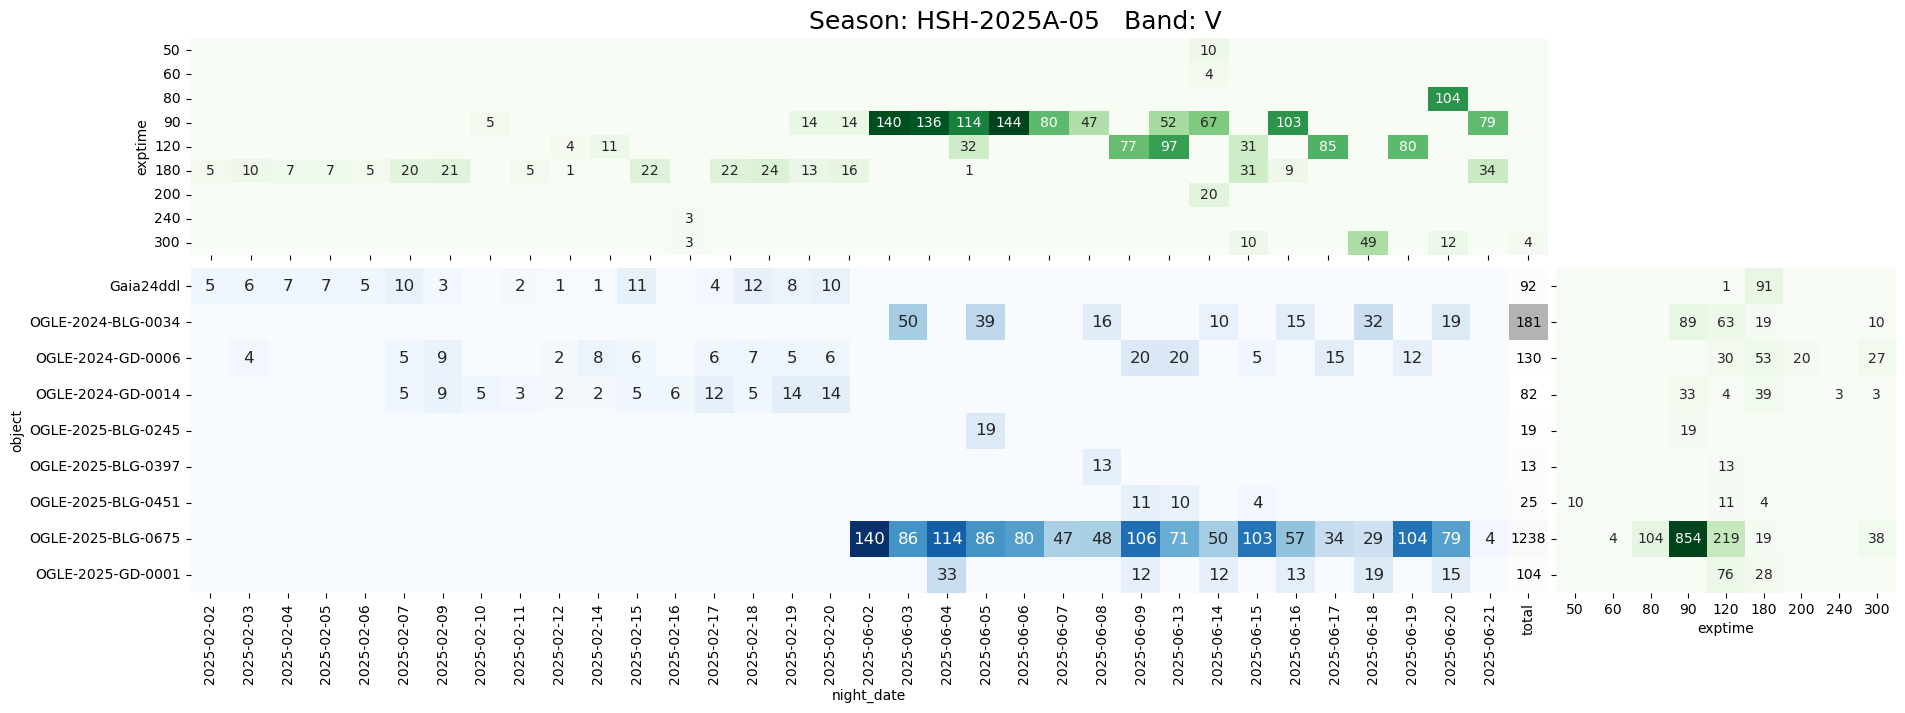

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


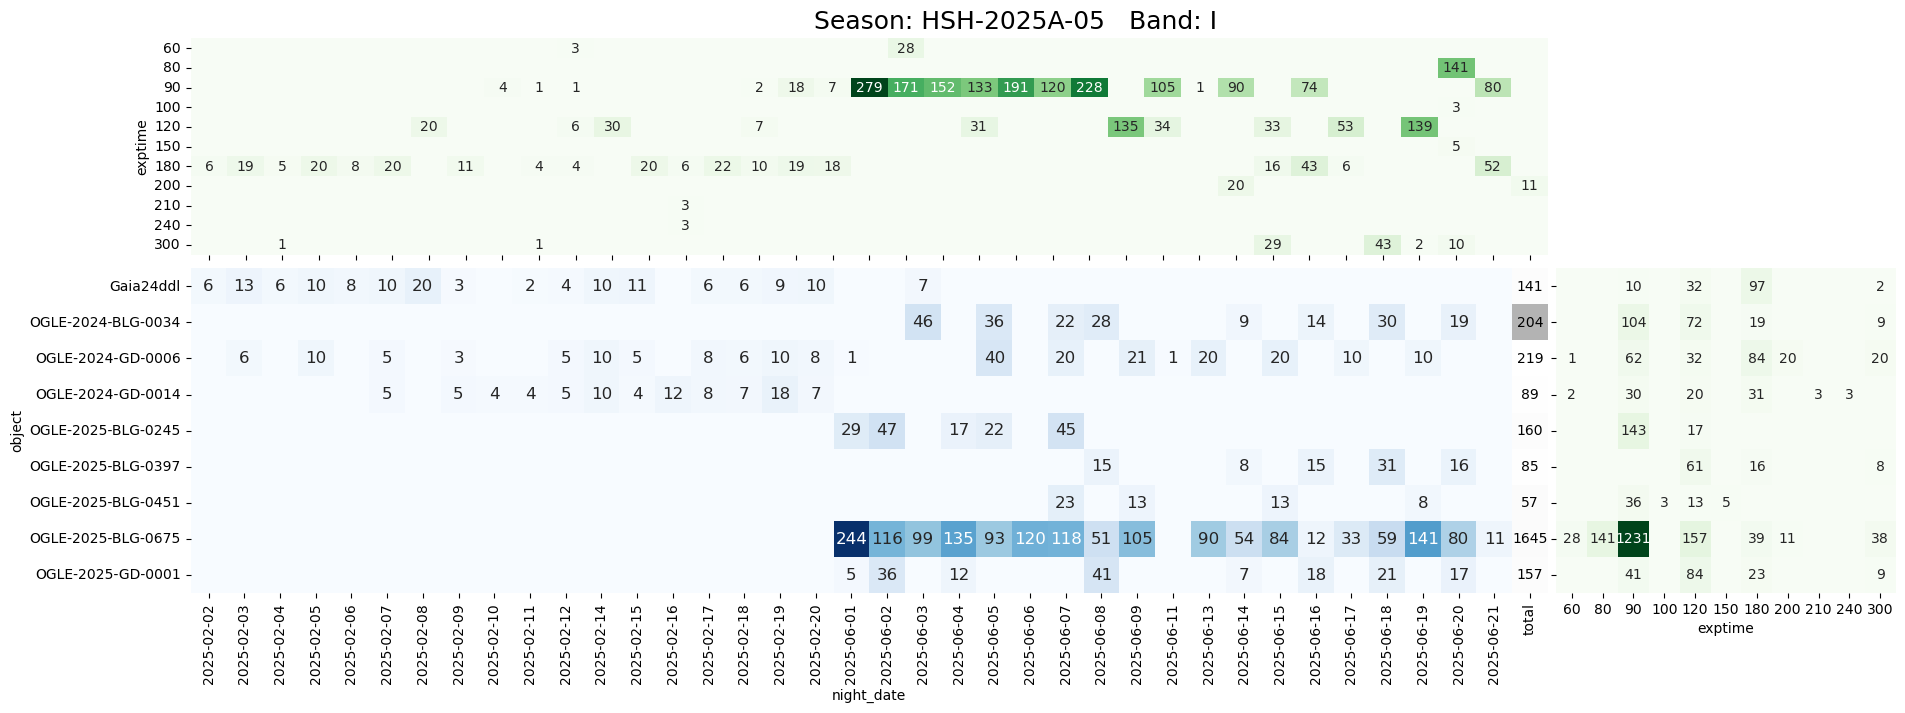

Plotting season: HSH-2025B-03


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


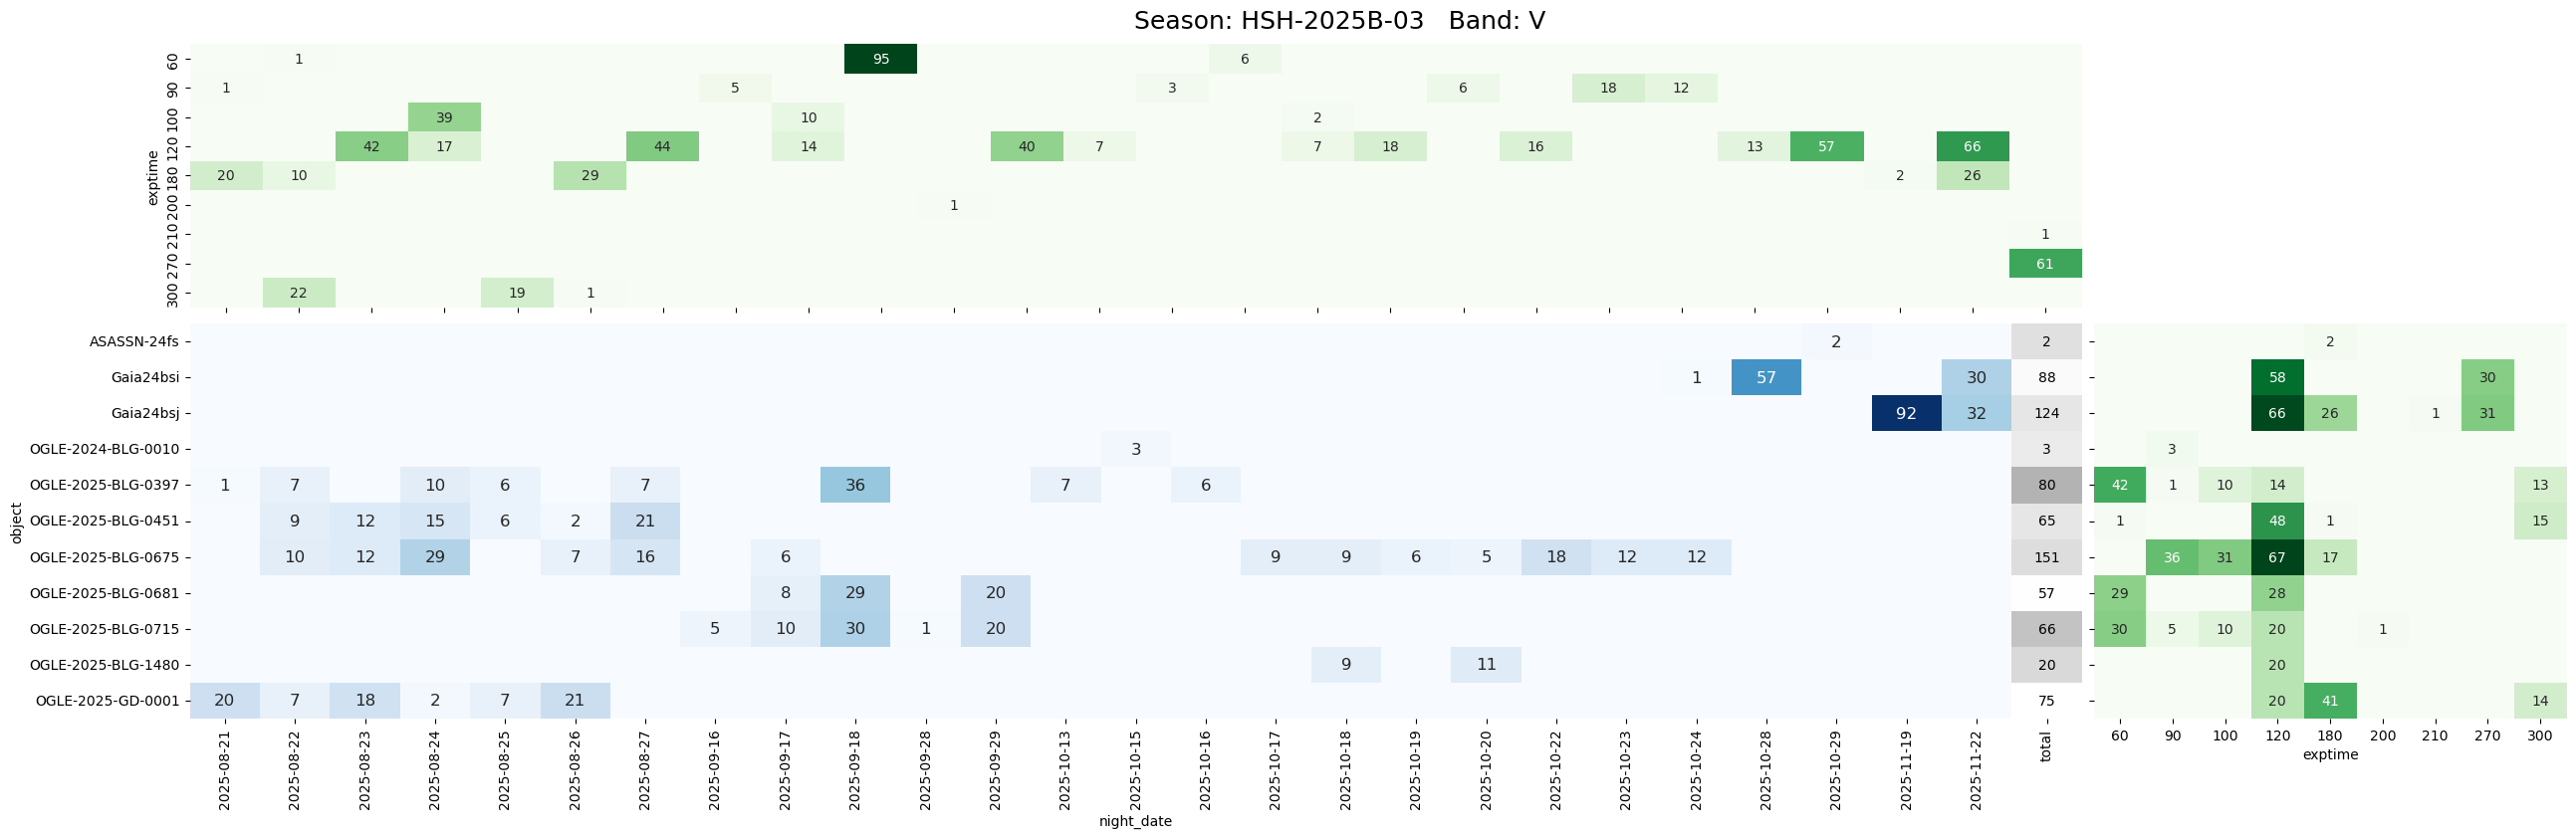

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


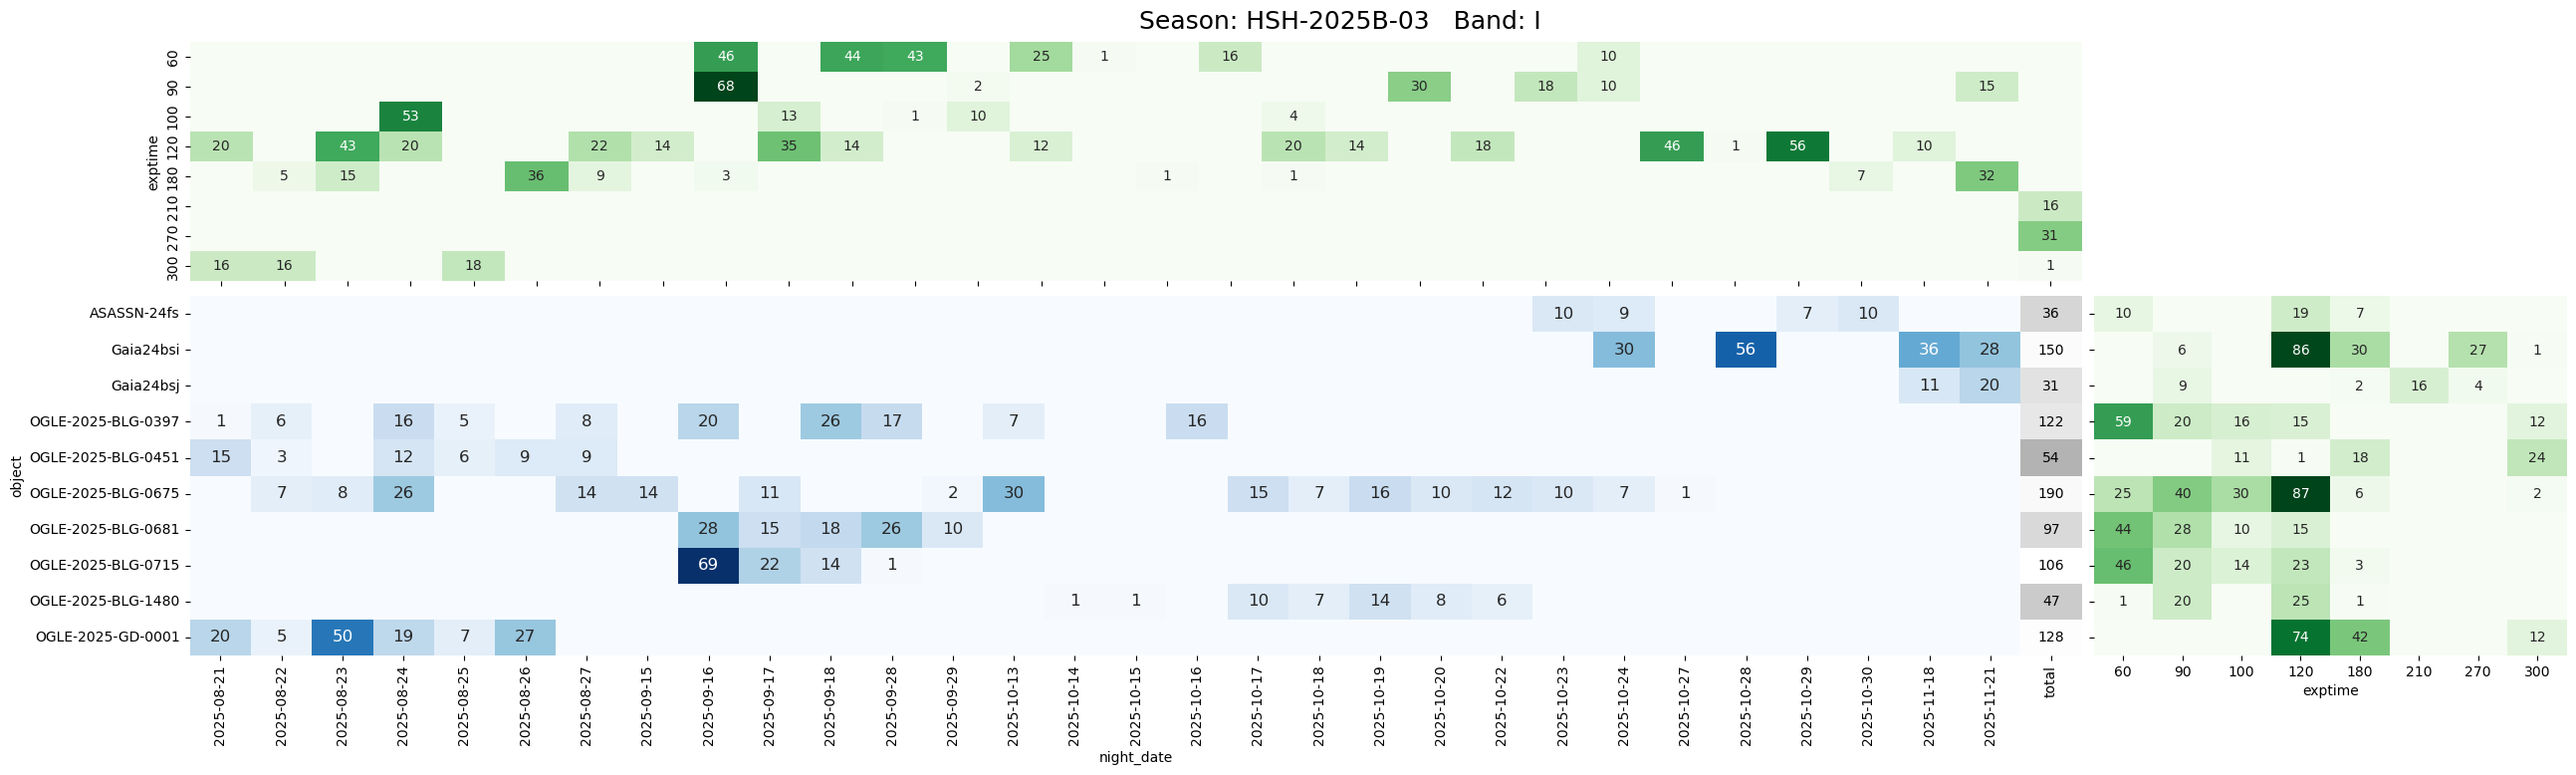

Plotting season: 2026A


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


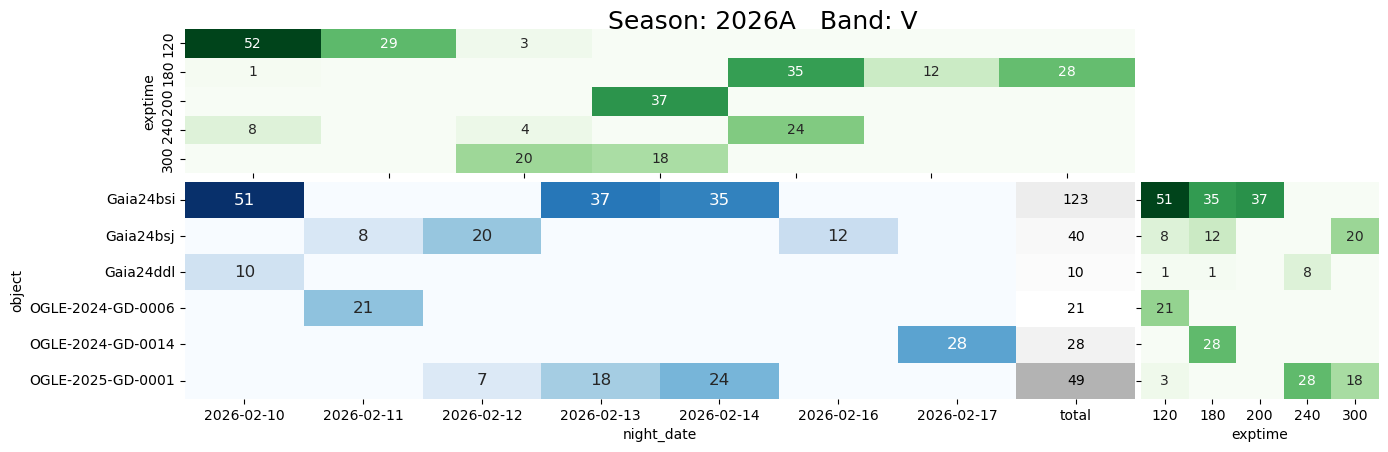

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


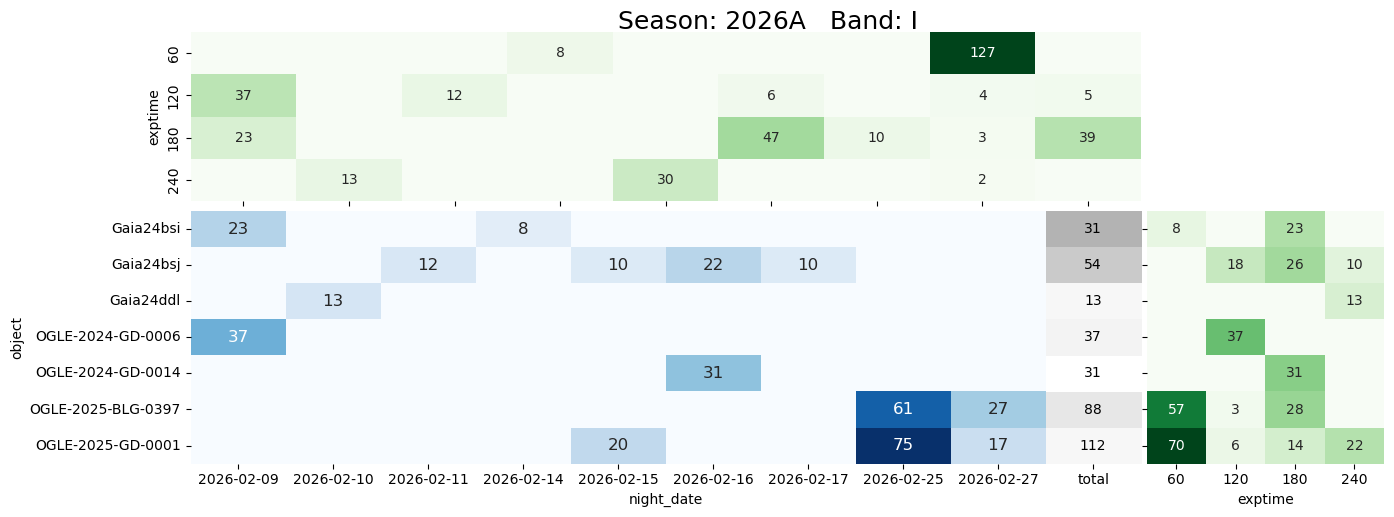

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar calendario de seasons
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons = seasons_df["season"].unique()

# Aseguramos tipos correctos
df["night"] = pd.to_datetime(df["night"])


df["exptime"] = pd.to_numeric(df["exptime"], errors='coerce').astype(int)

# Filtrar solo objetos válidos
df_objects = df[(df["imagetyp"]=="object") & (df["object"]!="NO_OBJECT")].copy()
# Convertir night a solo fecha
df_objects["night_date"] = df_objects["night"].dt.date

# Iterar por cada season
for season in seasons:
    print(f"Plotting season: {season}")
    
    # Fechas de la season
    season_dates = seasons_df.loc[seasons_df["season"]==season, "date"]
    n_nights = len(season_dates)
    
    for band in ["(3) V","(5) I"]:
    
        # Filtrar df_objects para esa season
        df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
        n_obj = len(df_season["object"].value_counts())
        
        
        if df_season.empty:
            print(f"No hay datos para la season {season}")
            continue
        
        # Matriz objeto × noche
        blue_matrix = (
            df_season.groupby(["object", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        blue_matrix["total"] = blue_matrix.sum(axis=1)
        
        top_green = (
            df_season.groupby(["exptime", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index()
        )
        
        right_green = (
            df_season.groupby(["object", "exptime"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        # Máscara para que "total" no reciba color de Blues
        mask_total = blue_matrix.columns.to_series().eq("total").to_numpy()  # 1D
        mask_total = np.tile(mask_total, (blue_matrix.shape[0], 1))           # 2D: filas x columnas
        annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
        annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
        annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")

        fig = plt.figure(figsize=(n_nights*0.55, n_obj*0.8))
        gs = fig.add_gridspec(
            2, 2,
            width_ratios=[4, 1],
            height_ratios=[2, 3],
            wspace=0.01,
            hspace=0.05
        )
        ax_top = fig.add_subplot(gs[0, 0])
        ax_main = fig.add_subplot(gs[1, 0])
        ax_right = fig.add_subplot(gs[1, 1])

        sns.heatmap(
            blue_matrix,
            ax=ax_main,
            cmap="Blues",
            annot=annot_blue,
            fmt="",
            annot_kws={"size":12},
            cbar=False,
            mask=mask_total,   # Esta máscara deja "total" sin color
        )
        ax_main.imshow(
            blue_matrix[["total"]],
            cmap="Greys",
            alpha=0.3,
            aspect='auto',
            extent=[blue_matrix.shape[1]-1, blue_matrix.shape[1], 0, blue_matrix.shape[0]]
        )

        for i, val in enumerate(blue_matrix["total"]):
            ax_main.text(
                blue_matrix.shape[1]-0.5,  # centro de la última columna
                i + 0.5,                    # centro de la fila
                int(val),
                ha='center',
                va='center'
            )
        sns.heatmap(top_green, ax=ax_top, cmap="Greens", annot=annot_top, fmt="", annot_kws={"size":10}, cbar=False)
        sns.heatmap(right_green, ax=ax_right, cmap="Greens", annot=annot_right, fmt="", annot_kws={"size":10}, cbar=False)

        band_str = band[-1]
        ax_top.set_xticklabels([])
        ax_top.set_xlabel("")
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
        plt.suptitle(f"Season: {season}   Band: {band_str}", fontsize=18, y=0.92)
        plt.tight_layout()  # Ajusta márgenes
        plt.savefig(f"season_{season}_band_{band_str}.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()  # cerrar la figura para liberar memoria



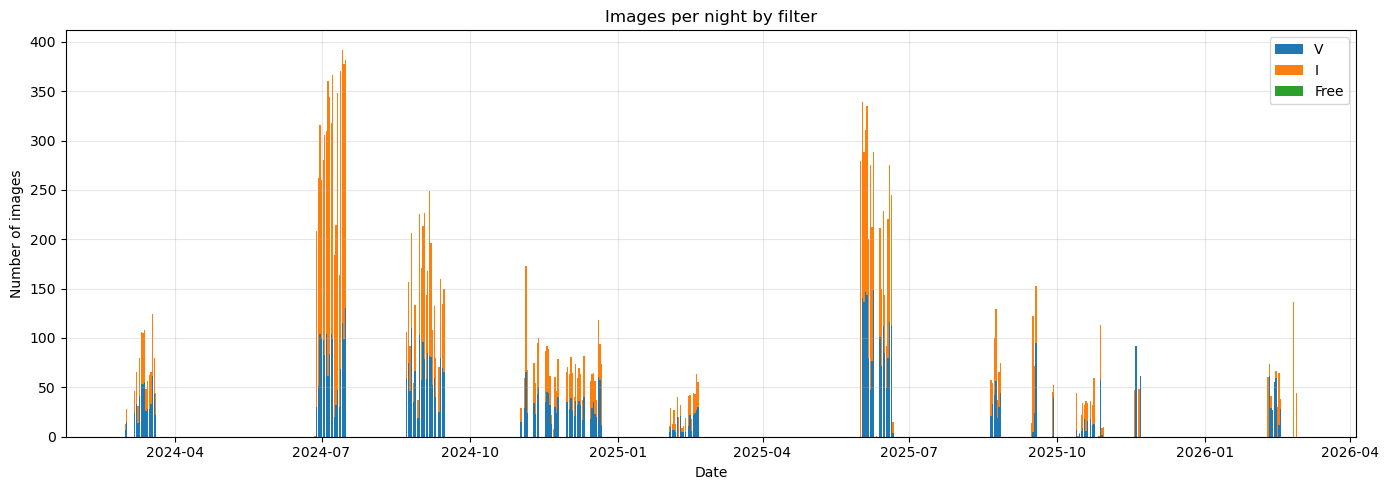

In [9]:

df_obj = df[df["imagetyp"]=="object"]
daily_counts = (
    df_obj.groupby(["night", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
daily_counts1 = (
    df_obj.groupby(["night", "wheel_aux"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(14,5))

x = daily_counts.index
v = daily_counts["(3) V"]
i = daily_counts["(5) I"]
f = daily_counts["(1) Free"]
#b = daily_counts["(2) B"]
#r = daily_counts["(4) R"]


plt.bar(x, v, label="V")
plt.bar(x, i, bottom=v, label="I") 
plt.bar(x, f, bottom=i, label="Free") 
#plt.bar(x, b, bottom=f, label="B") 
#plt.bar(x, r, bottom=b, label="R") 


plt.xlabel("Date")
plt.ylabel("Number of images")
plt.title("Images per night by filter")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



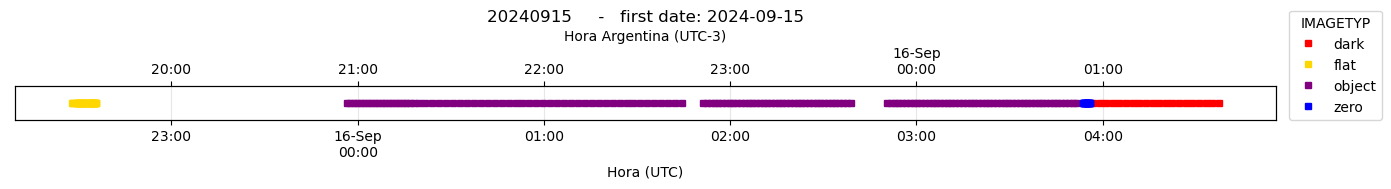

object
ASASSN-24fs          113
OGLE-2024-DG-0016     40
Name: count, dtype: int64


15302    Makler
15317    Makler
15297    Makler
15292    Makler
15301    Makler
          ...  
15224    Makler
15222    Makler
15223    Makler
15225    Makler
15220    Makler
Name: observer, Length: 232, dtype: object

In [42]:
df_obj = check_night(df, "20240915")
df_obj["observer"]

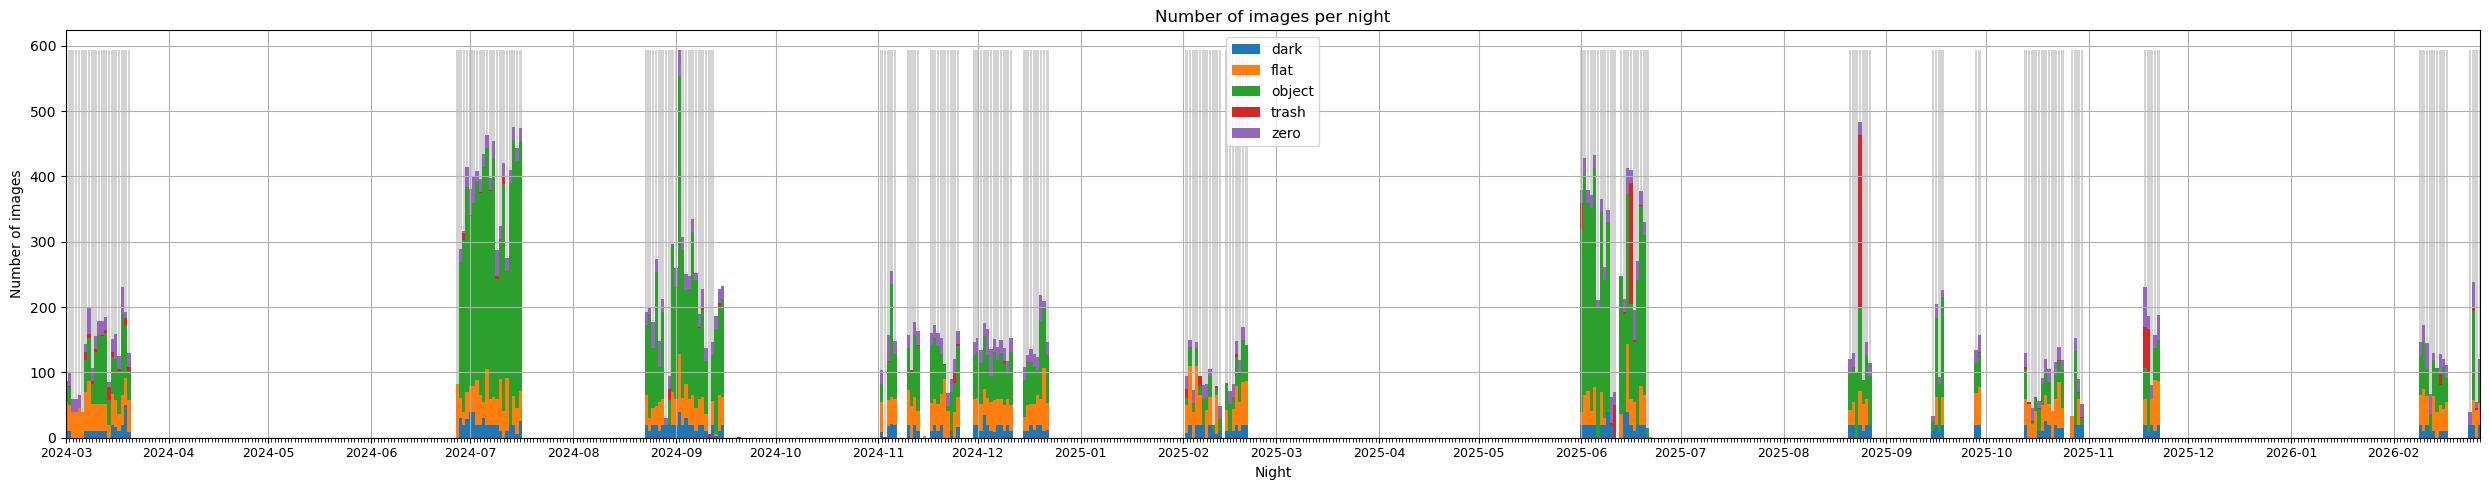

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['night'] = pd.to_datetime(df['night'])

imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red",
    "HSH-2026A-03": "tab:purple"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)

fig, ax = plt.subplots(figsize=(25,5))

y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)

bottom = None
for col in counts.columns:
    ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
    bottom = counts[col] if bottom is None else bottom + counts[col]

# Ahora SÍ es eje datetime real
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

ax.tick_params(axis='x', which='major', rotation=0, labelsize=9)
ax.tick_params(axis='x', which='minor', length=3)

ax.set_xlabel("Night")
ax.set_ylabel("Number of images")

plt.xlim(df["night"].min(), df["night"].max())

plt.title("Number of images per night")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



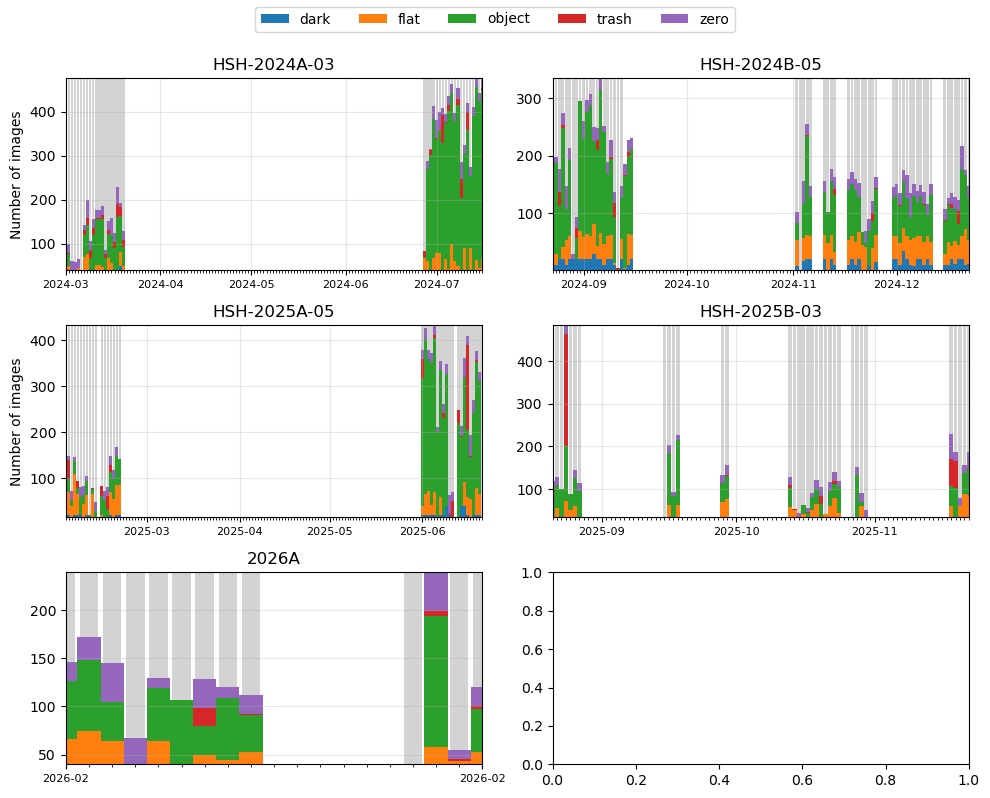

In [515]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates




# Asegúrate de que la fecha sea datetime
df['night'] = pd.to_datetime(df['night'])

# Conteo de imágenes por noche
imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red",
    "HSH-2026A-03": "tab:purple"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)



c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)


seasons = seasons_df.season.unique()
fig, axes = plt.subplots(3, 2, figsize=(10, 8))#, sharey=True)
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    season_df= seasons_df[seasons_df["season"]==season]
    merged_season = merged[merged["season"]==season]
    if merged_season.empty:
        ax.set_title(f"{season} (no data)")
        continue
    x = merged_season['date'].to_numpy()
    y = merged_season['n_images'].to_numpy()
    y_max = max(y)
    for xi in x:
        if xi in season_df["date"].values:
            ax.bar(xi, y_max, color="lightgray")
    ax.bar(x, y, width=1.0, color=c)


    bottom = None
    for col in counts.columns:
        ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
        bottom = counts[col] if bottom is None else bottom + counts[col]
 
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.set_ylim(y.min(), y.max())
    ax.set_xlim(x.min(), x.max())

    ax.set_title(season)
    ax.grid(alpha=0.3)

# Etiquetas y leyenda
axes[0].set_ylabel("Number of images")
axes[2].set_ylabel("Number of images")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels))

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
def check_night(df, day):
    if not "-" in str(day):
        df_day = df[df["night"] == day].copy()
    else:
        df_day = df[df["date-obs"].dt.date == pd.to_datetime(day).date()].copy()
    dt_utc = pd.to_datetime(
        df_day["date-obs"].dt.strftime("%Y-%m-%d") + " " + df_day["time-obs"].astype(str),
        errors="coerce"
    )

    df_day["datetime"] = dt_utc  # guardar para poder plotear
    df_day["datetime_ar"] = df_day["datetime"] - pd.Timedelta(hours=3)
    def ar_hour_formatter(x, pos=None):
        dt_utc = mdates.num2date(x)              # valor original en UTC
        dt_ar = dt_utc - pd.Timedelta(hours=3)  # convertir a AR manualmente
        
        if dt_ar.hour == 0 and dt_ar.minute == 0:
            return dt_ar.strftime('%d-%b\n%H:%M')
        return dt_ar.strftime('%H:%M')



    df_day["imagetyp"] = df_day["imagetyp"].str.lower().str.strip()

    color_map = {
        "flat": "gold",
        "dark": "red",
        "zero": "blue",
        "object": "purple"
    }

    plt.figure(figsize=(14, 2))

    for typ, group in df_day.groupby("imagetyp"):   #  usar df_day
        plt.plot(
            group["datetime"].to_numpy(),   #  convertir a numpy
            np.ones(len(group)),            #  también numpy
            "s",
            label=typ,
            color=color_map.get(typ, "gray"),
            markersize=5
        )


    plt.gca().yaxis.set_visible(False)
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.xlabel("Hora (UTC)")
    first_day = df_day["datetime"].min().date()
    plt.title(f"{day}     -   first date: {first_day}")
    plt.grid(True, axis='x', alpha=0.3)

    plt.legend(title="IMAGETYP", loc=(1.01,0))

    import matplotlib.ticker as mticker

    def day_hour_formatter(x, pos=None):
        dt = mdates.num2date(x)
        
        # Si es medianoche, mostramos fecha + hora
        if dt.hour == 0 and dt.minute == 0:
            return dt.strftime('%d-%b\n%H:%M')  # salto de línea
        else:
            return dt.strftime('%H:%M')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(day_hour_formatter))
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(ar_hour_formatter))
    ax2.set_xlabel("Hora Argentina (UTC-3)")


    plt.tight_layout()
    plt.show()
    print(df_day.object.value_counts())
    return df_day

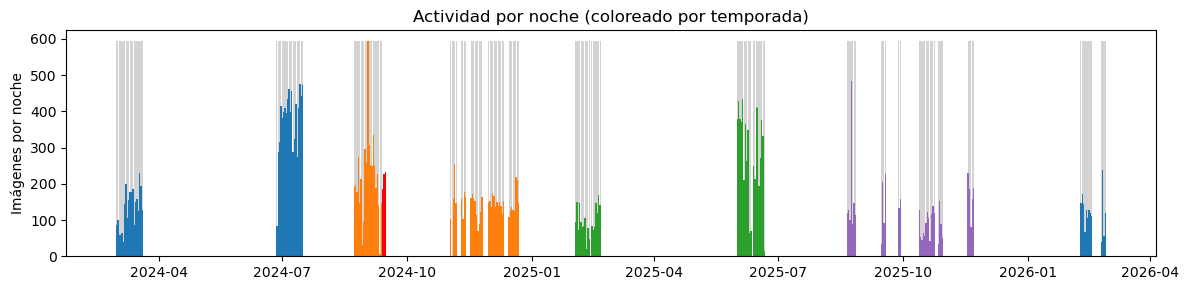

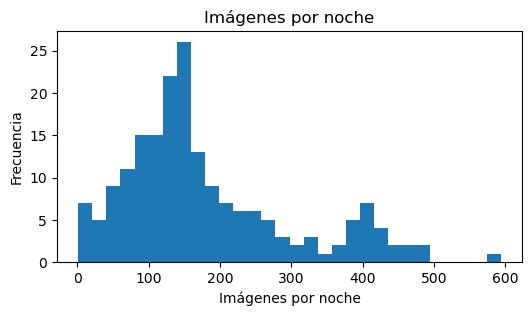

In [32]:
import matplotlib.pyplot as plt

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')

import matplotlib.pyplot as plt

season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:purple",
    "2026A": "tab:blue"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()

plt.figure(figsize=(12,3))
y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)


plt.ylabel('Imágenes por noche')
plt.title('Actividad por noche (coloreado por temporada)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imgs_per_night.values, bins=30)
plt.xlabel('Imágenes por noche')
plt.ylabel('Frecuencia')
plt.title('Imágenes por noche')
plt.show()



In [93]:
red_nights = merged[merged["season"].isna()].copy()

print(len(red_nights))
red_nights

20


,date,n_images,season
20,2024-03-21,129,NaN
41,2024-07-17,351,NaN
62,2024-09-13,114,NaN
63,2024-09-14,212,NaN
64,2024-09-15,244,NaN
65,2024-09-16,186,NaN
66,2024-09-21,1,NaN
71,2024-11-07,108,NaN
76,2024-11-14,132,NaN
77,2024-11-15,2,NaN


In [ ]:
seasons_df[seasons_df["date"]=="2024-03-21"]

,season,date,program
19,HSH-2024A-03,2024-03-20,HSH


### Análisis por objeto

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

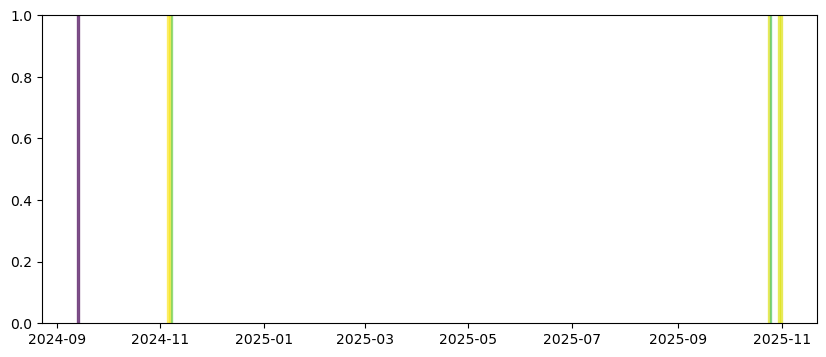

In [368]:
# Plots de curvas de luz con días observados sombreados.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from datetime import timedelta
import os
for obj in [folder for folder in os.listdir("../data/objetos") if not ".csv" in folder] :
    target_folder = "../data/objetos/"+obj
    photo_file = [file for file in os.listdir(target_folder) if "photometry" in file][0]
    mop_lc = pd.read_csv(target_folder+ "/"+ photo_file)
    mop_lc=mop_lc[mop_lc["Filter"].isin(["OGLE_I", "G", "i(GaiaSP)", "V(GaiaSP)"])]
    mop_lc['Timestamp'] = pd.to_datetime(mop_lc['Timestamp'])
    mop_lc['Magnitude'] = pd.to_numeric(mop_lc['Magnitude'], errors='coerce')
    mop_lc['Error'] = pd.to_numeric(mop_lc['Error'], errors='coerce')


    counts_series = (
        df[df["object"] == obj]
        .groupby(df["date-obs"].dt.date)
        .size()
        .sort_index()
    )

    dates = counts_series.index
    counts = counts_series.values
    if len(counts)==0:
        print(f"No images for object {obj}")
        continue


    fig, ax = plt.subplots(figsize=(10,4))

    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    cmap = plt.get_cmap("viridis_r")

    for date, value in zip(dates, counts):
        ax.axvspan(
            date,
            date + timedelta(days=1),
            color=cmap(norm(value)),
            alpha=0.6
        )
    filters = mop_lc["Filter"].unique()
    for filt in filters:
        lc_filt = mop_lc[mop_lc["Filter"]==filt]
        ax.plot(lc_filt["Timestamp"], lc_filt["Magnitude"], "o", ms=2, label = filt)
    #print(mop_lc["Filter"].value_counts())

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Number of images")

    ax.set_xlim(df["date-obs"].min() - timedelta(days=60),
                df["date-obs"].max() + timedelta(days=5))
    #ax.set_ylim(0, 1)

    ax.set_title(f"{obj} light curve (Total images = {sum(counts)})")
    

    #print(mop_lc["Filter"].value_counts())
    plt.gca().invert_yaxis()
    plt.legend()
    # Fecha en formato AAAAMMDD (uso la fecha mínima de observación del objeto)
    date_str = df[df["object"] == obj]["date-obs"].max().strftime("%Y%m%d")

    filename = f"{obj}_lc_{date_str}.png"
    filepath = os.path.join("../plots", filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)
 
#plt.legend(loc=(1.01,0), ncols=4)

In [369]:
import pandas as pd


df["night"] = pd.to_datetime(df["night"]).dt.normalize()
#seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
#seasons_df["date"] = seasons_df["date"].dt.normalize()

table_images = (
    df
    .groupby(["season", "object"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Total por objeto (fila)
table_images["Images"] = table_images.sum(axis=1)

# Total por temporada (fila final)
total_row = table_images.sum(axis=0)
total_row.name = "Images"

table_images = pd.concat([table_images, total_row.to_frame().T]).T
table_images

,2026A,HSH-2024A-03,HSH-2024B-05,HSH-2025A-05,HSH-2025B-03,Images
object,,,,,,
ASASSN-24fs,0,0,106,0,54,160
Gaia23cnu,0,188,0,0,0,188
Gaia23dpn,0,28,0,0,0,28
Gaia24bsi,154,0,1441,0,242,1837
Gaia24bsj,97,0,1156,0,219,1472
Gaia24ddl,23,0,0,233,0,256
M83,0,9,0,0,0,9
NGC0092,0,0,1,0,0,1
NGC2217,0,1,0,0,0,1


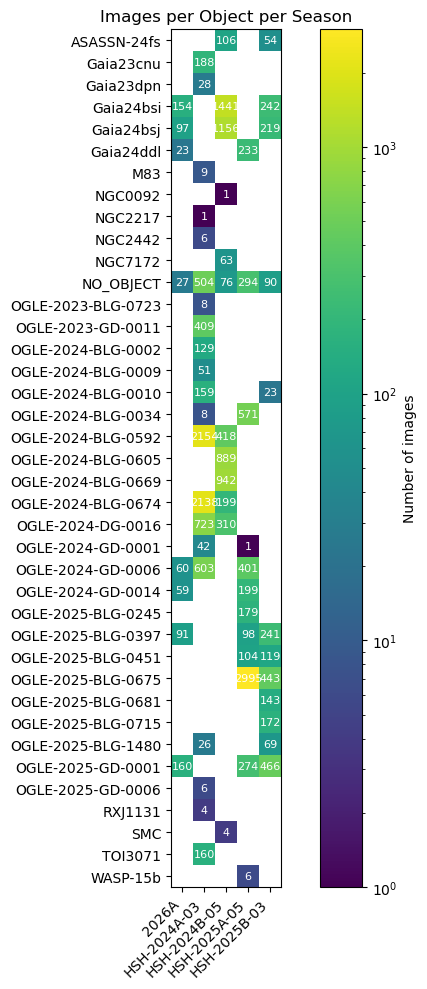

In [370]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Separar totales
heatmap_data = table_images.drop(index="Images").drop(columns="Images")

fig, ax = plt.subplots(figsize=(8,10))

#im = ax.imshow(heatmap_data.values, cmap="viridis")
norm = mcolors.LogNorm(
    vmin=max(1, heatmap_data.values.min()),
    vmax=heatmap_data.values.max()
)

im = ax.imshow(heatmap_data.values, cmap="viridis", norm=norm)

# Etiquetas
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)

# Anotar valores
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j, i,
            heatmap_data.iloc[i, j],
            ha="center", va="center",
            fontsize=8,
            color="white"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of images")

ax.set_title("Images per Object per Season")
plt.tight_layout()
plt.show()

KeyError: "['Images'] not found in axis"

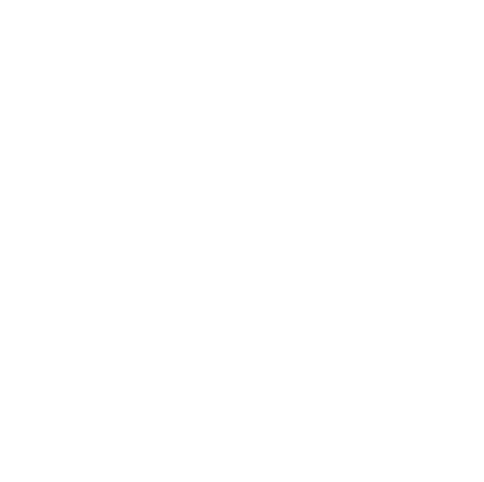

In [371]:
import pandas as pd

# 1️⃣ Calcular cantidad de objetos por temporada
# Solo consideramos las columnas de temporadas, no Images
season_cols = [c for c in table_images.columns if c != "Images"]

obj_count_row = (table_images[season_cols] > 0).sum(axis=0)  # número de objetos con al menos 1 imagen por temporada
obj_count_row["Images"] = sum(obj_count_row)  # podemos dejar vacío o poner el total general de objetos

# Convertir en DataFrame de 1 fila con mismo índice
obj_count_row_df = pd.DataFrame([obj_count_row], index=["Cantidad de objetos"])
# 2️⃣ Concatenar fila arriba de la tabla original
table_with_count = pd.concat([obj_count_row_df, table])
# Asumimos que 'table' es la tabla final con TOTAl fila y columna
data = table_with_count.values
rows = table_with_count.index.astype(str).tolist()
cols = table_with_count.columns.astype(str).tolist()

fig, ax = plt.subplots(figsize=(6, max(4, len(rows)*0.25+1)))
ax.axis('off')  # ocultar ejes
from matplotlib.colors import LogNorm

# Evitar ceros porque log(0) no existe
image_data = table_with_count.drop("Images", axis=1).drop("Images", axis=0)
image_data_nonzero = image_data.replace(0, np.nan)  # ceros se pintarán blancos

norm = LogNorm(vmin=image_data_nonzero.min().min(), vmax=image_data_nonzero.max().max())
cmap = plt.get_cmap("Greens")

# Dibujar celdas coloreadas
cell_text = []
cell_colors = []
for r_idx, row in enumerate(data):
    row_text = []
    row_colors = []
    for c_idx, val in enumerate(row):
        if str(val)!="0":
            row_text.append(str(val))
        else:
            row_text.append("")
        # Colorear solo celdas que no sean totales
        if (rows[r_idx] != "Images") and (cols[c_idx] != "Images") and ((rows[r_idx] != "Cantidad de objetos") ):
            color = cmap(norm(val))
        else:
            color = "lightgray"  # gris claro para totales
        row_colors.append(color)
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Crear tabla
the_table = ax.table(
    cellText=cell_text,
    rowLabels=rows,
    colLabels=cols,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)

all_cols_text = []
for col_idx in range(len(cols)):
    col_text = [cols[col_idx]]  # header
    for row_idx in range(len(rows)):
        col_text.append(cell_text[row_idx][col_idx])
    all_cols_text.append(col_text)
# Calcular ancho proporcional
col_widths = []
for col in all_cols_text:
    max_len = max(len(str(x)) for x in col)
    col_widths.append(max_len)
# Normalizar (ajustá el factor si querés más espacio)
total = sum(col_widths)
col_widths = [w / total for w in col_widths]
# Aplicar a la tabla
for col_idx, width in enumerate(col_widths):
    for row_idx in range(len(rows)+1):  # +1 incluye header
        the_table[(row_idx, col_idx)].set_width(width)
the_table.auto_set_font_size(False)
the_table.set_fontsize(9)
the_table.scale(1, 1.5)  # ancho x alto de las celdas
plt.title("Número de imágenes por objeto y temporada", fontsize=10, y=1.1)
plt.show()

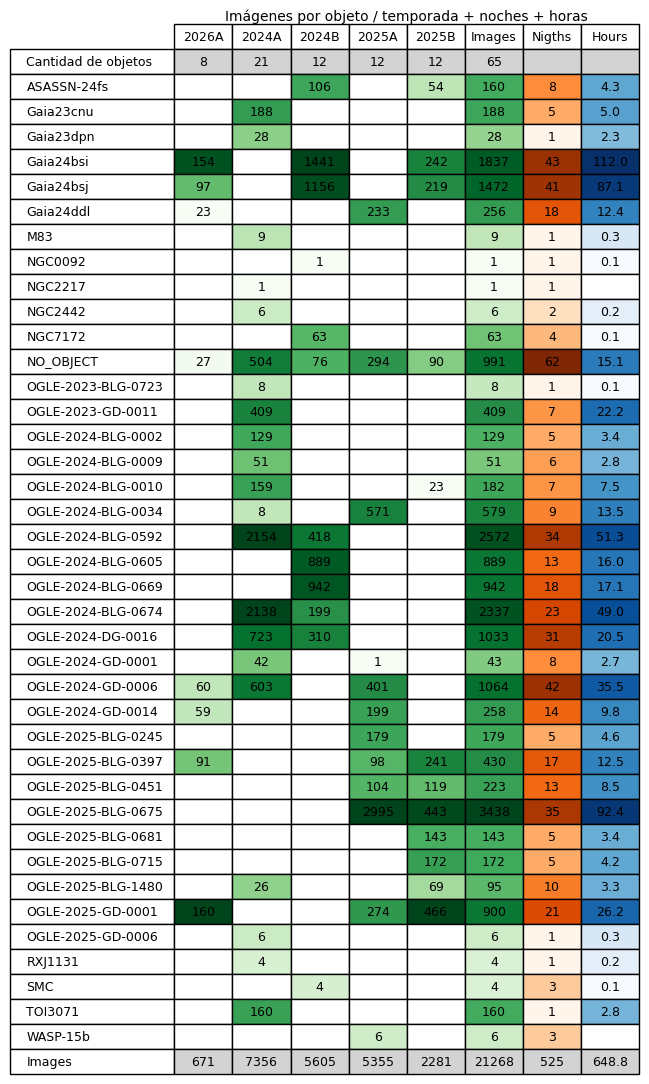

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df["night"] = pd.to_datetime(df["night"]).dt.normalize()
tab = pd.crosstab(df["object"], df["season"])


# métricas extra
tab["Images"]  = tab.sum(1)
tab["Nigths"] = df.groupby("object")["night"].nunique()
tab["Hours"]  = (df.groupby("object")["exptime"].sum()/3600).round(1)

# fila Images
tot = tab.sum(0); tot.name = "Images"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nigths","Hours"]]
cnt = (tab.loc[tab.index!="Images", sc]>0).sum(0)
cnt["Images"] = cnt.sum(); cnt["Nigths"]=np.nan; cnt["Hours"]=np.nan
tab = pd.concat([pd.DataFrame([cnt], index=["Cantidad de objetos"]), tab])
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
    "2026A": "2026A",   
}
tab = tab.rename(columns=rename_map)
# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (v==0 or pd.isna(v)) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        if r not in ["Images","Cantidad de objetos"] and pd.notna(v):
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Images","Cantidad de objetos"]))]
            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)
                cmap = plt.get_cmap("Blues" if c=="Hours" else "Oranges" if c=="Nigths" else "Greens")
                rc.append(cmap(norm(v)) if v>0 else (1,1,1,1))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append("lightgray")

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1,1.5)

plt.title("Imágenes por objeto / temporada + noches + horas", fontsize=10, y=1.1)
plt.show()

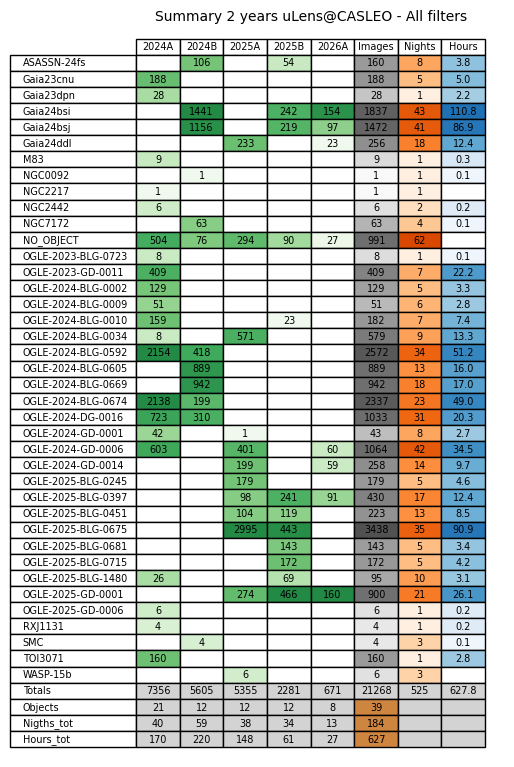

In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df.copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_all_filters.png", dpi=300, bbox_inches='tight')

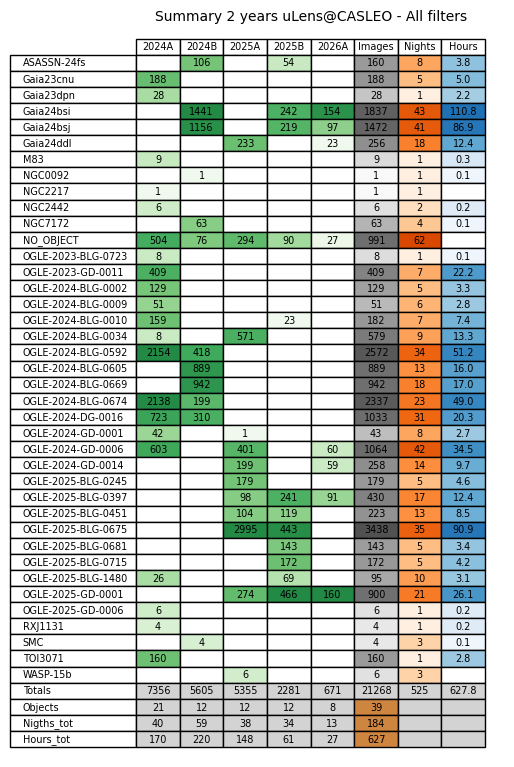

In [390]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df.copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_all_filters.png", dpi=300, bbox_inches='tight')

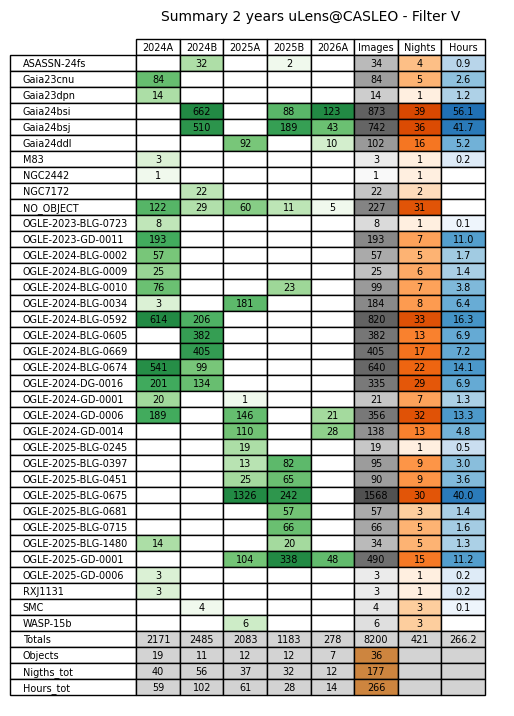

In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["wheel"]=="(3) V"].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter V", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_all_filters.png", dpi=300, bbox_inches='tight')

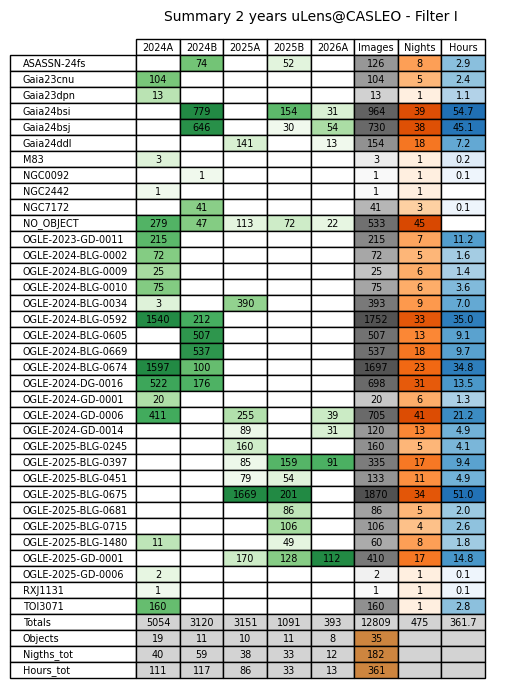

In [392]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["wheel"]=="(5) I"].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter I", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_filter_i.png", dpi=300, bbox_inches='tight')

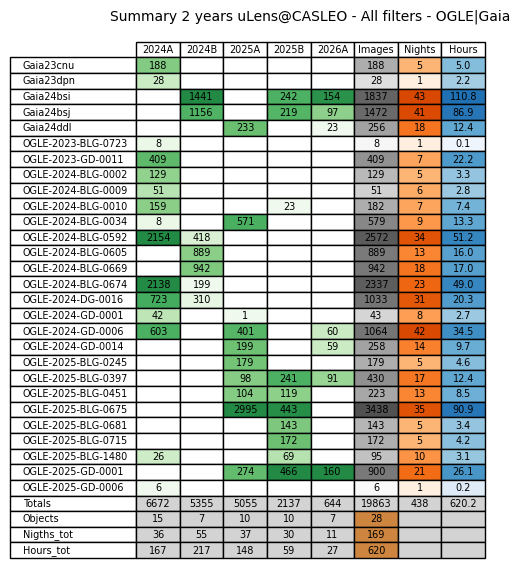

In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE") ].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters - OGLE|Gaia", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_all_filters_only_ulens.png", dpi=300, bbox_inches='tight')

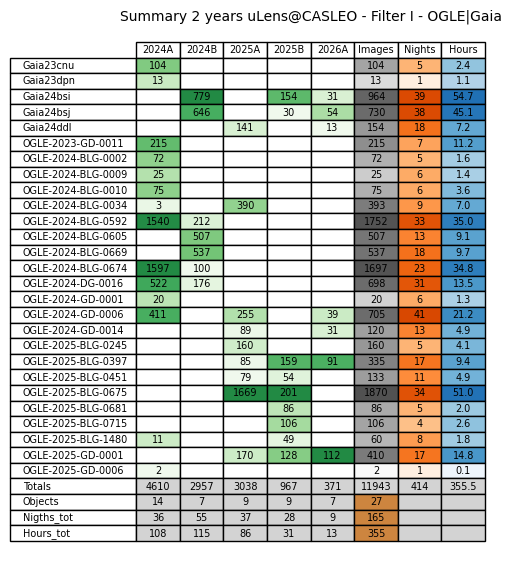

In [394]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[(df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE"))& (df["wheel"]=="(5) I")].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter I - OGLE|Gaia", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_filter_i_only_ulens.png", dpi=300, bbox_inches='tight')

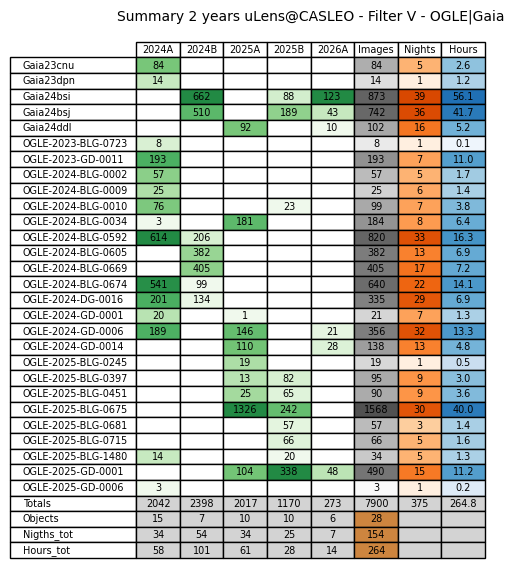

In [395]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[(df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE"))& (df["wheel"]=="(3) V")].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter V - OGLE|Gaia", fontsize=10, y=1.0)
plt.savefig("summary_2_years_ulens_casleo_filter_v_only_ulens.png", dpi=300, bbox_inches='tight')

### Noches otorgadas y no otorgadas

In [245]:
obs_nights = set(df["night"].unique())
season_nights = set(seasons_df["date"].unique())

season_nights = set(
    pd.to_datetime(list(season_nights))
    .strftime("%Y%m%d")
)

extra_nights = sorted(obs_nights - season_nights)

non_ot = pd.DataFrame({"night_outside_season": extra_nights})
non_ot.to_csv("non_season_nights_with_science.csv", index=False)
non_ot

,night_outside_season
0,20240913
1,20240914
2,20240915
3,20240920
4,20241115
5,20250622


In [246]:
for n in non_ot["night_outside_season"].values:
    print(n)
    print(df[df["night"]==n].object.value_counts())
    print()

20240913
object
ASASSN-24fs    162
Name: count, dtype: int64

20240914
object
ASASSN-24fs          126
OGLE-2024-DG-0016      9
NO_OBJECT              8
Name: count, dtype: int64

20240915
object
ASASSN-24fs          113
OGLE-2024-DG-0016     40
Name: count, dtype: int64

20240920
object
NO_OBJECT    1
Name: count, dtype: int64

20241115
object
NO_OBJECT    2
Name: count, dtype: int64

20250622
object
NO_OBJECT    1
Name: count, dtype: int64



In [247]:
seasons_df
df.season.value_counts()

season
HSH-2024A-03    10173
HSH-2024B-05     9624
HSH-2025A-05     7513
HSH-2025B-03     4281
2026A            1580
Name: count, dtype: int64

In [512]:
science_nights = set(
    pd.to_datetime(
        df[df["imgtyp_old"] == "object"]["night"]
    ).dt.date
)
science_counts = (
    df[df["imgtyp_old"] == "object"]
    .groupby("night")
    .size()
)

# noches con ≥10 imágenes
science_nights_10 = set(
    pd.to_datetime(
        science_counts[science_counts >= 10].index
    ).date
)
season_nights = set(
    pd.to_datetime(seasons_df["date"]).dt.date
)
missing_science = set(sorted(season_nights - science_nights_10))
missing_science_0 = set(sorted(season_nights - science_nights))
missing_science - missing_science_0


{datetime.date(2024, 9, 11),
 datetime.date(2024, 11, 3),
 datetime.date(2024, 11, 22),
 datetime.date(2025, 2, 10),
 datetime.date(2025, 6, 10),
 datetime.date(2025, 10, 14),
 datetime.date(2025, 10, 15),
 datetime.date(2025, 10, 27),
 datetime.date(2026, 2, 26)}

In [514]:
df[df["night"] == "20250210"][["file", "imagetyp", "imgtyp_old", "check_status", "exptime"]]

,file,imagetyp,imgtyp_old,check_status,exptime
21272,OGLE-2024-GD-0014_i0001.fit,object,object,OK,90.0
21273,OGLE-2024-GD-0014_i0002.fit,object,object,OK,90.0
21274,OGLE-2024-GD-0014_i0003.fit,object,object,OK,90.0
21275,OGLE-2024-GD-0014_i0004.fit,object,object,OK,90.0
21276,OGLE-2024-GD-0014_v0001.fit,object,object,OK,90.0
21277,OGLE-2024-GD-0014_v0002.fit,object,object,OK,90.0
21278,OGLE-2024-GD-0014_v0003.fit,object,object,OK,90.0
21279,OGLE-2024-GD-0014_v0004.fit,object,object,OK,90.0
21280,OGLE-2024-GD-0014_v0005.fit,object,object,OK: early object,90.0
21281,dark_0001.fit,dark,dark,OK,90.0


In [504]:
science_nights = set(
    pd.to_datetime(
        df[df["imagetyp"] == "object"]["night"]
    ).dt.date
)

season_nights = set(
    pd.to_datetime(seasons_df["date"]).dt.date
)
missing_science = sorted(season_nights - science_nights)
season_map = dict(
    zip(
        pd.to_datetime(seasons_df["date"]).dt.date,
        seasons_df["season"]
    )
)

missing_science_seasons = [season_map.get(night) for night in missing_science]
reason = [None] * len(missing_science)
labels = ["aprendiendo", "aprendiendo", "aprendiendo", "aprendiendo", "mal tiempo", "problemas técnicos", 
          "corte de luz en Burek", "se observó según el log", "qué pasó? (init season)", "problemas técnicos", "mal tiempo",
          "qué pasó? (init season)"]+["incendio en Burek"]*9 + ["mal tiempo",
        "mal tiempo", "problemas técnicos", "mal tiempo", "se observó según el log",
        "se observó según el log", "se observó según el log", 
        "sin targets"]+["sin targets"]*6+["mal tiempo", "no se observó", "se observó según el log"]

for i in range(min(len(labels), len(reason))):
    reason[i] = labels[i]
    
non_obs = {"season":missing_science_seasons, "date": missing_science, "reason": reason}
# 25/12/17 ; 25/12/18 ; 2025-12-20
non_obs = pd.DataFrame(non_obs)   
non_obs.to_csv("season_nights_without_science.csv", index=False)
non_obs

,season,date,reason
0,HSH-2024A-03,2024-03-03,aprendiendo
1,HSH-2024A-03,2024-03-04,aprendiendo
2,HSH-2024A-03,2024-03-05,aprendiendo
3,HSH-2024A-03,2024-03-06,aprendiendo
4,HSH-2024B-05,2024-08-29,mal tiempo
5,HSH-2024B-05,2024-09-11,problemas técnicos
6,HSH-2024B-05,2024-11-03,corte de luz en Burek
7,HSH-2024B-05,2024-12-23,se observó según el log
8,HSH-2025A-05,2025-02-01,qué pasó? (init season)
9,HSH-2025A-05,2025-06-10,problemas técnicos


In [502]:
df[df["night"] == "20260226"][["file", "imagetyp", "imgtyp_old", "check_status", "exptime"]]

,file,imagetyp,imgtyp_old,check_status,exptime
33645,flat_v0001.fit,flat,flat,OK,0.10
33646,flat_v0002.fit,flat,flat,OK,0.10
33647,flat_v0003.fit,flat,flat,OK,0.10
33648,flat_v0004.fit,flat,flat,OK,0.10
33649,flat_v0005.fit,flat,flat,OK,0.10
33650,flat_v0006.fit,flat,flat,OK,0.10
33651,flat_v0007.fit,flat,flat,OK,0.10
33652,flat_v0008.fit,flat,flat,OK,0.10
33653,flat_v0009.fit,flat,flat,OK,0.10
33654,flat_v0010.fit,flat,flat,OK,0.10


In [496]:
non_obs["reason"].value_counts()

reason
incendio en Burek          9
sin targets                7
mal tiempo                 6
se observó según el log    5
aprendiendo                4
problemas técnicos         3
qué pasó? (init season)    2
corte de luz en Burek      1
no se observó              1
Name: count, dtype: int64

In [100]:
df[df["night"].isin(missing_science)].drop_duplicates("night")["season"].values

/tmp/ipykernel_12173/1172538409.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df[df["night"].isin(missing_science)].drop_duplicates("night")["season"].values


array(['HSH-2024A-03', 'HSH-2024A-03', 'HSH-2024A-03', 'HSH-2024A-03',
       'HSH-2024B-05', 'HSH-2024B-05', 'HSH-2024B-05', 'HSH-2025A-05',
       'HSH-2025B-03', 'HSH-2025B-03', '2026A', '2026A'], dtype=object)

In [92]:
non_obs[non_obs["reason"]=="se observó según el log"]

,season_without_science,reason
7,2024-12-23,se observó según el log
25,2025-12-17,se observó según el log
26,2025-12-18,se observó según el log
27,2025-12-19,se observó según el log
37,2026-02-28,se observó según el log


In [89]:
df[df["night"]=="20251216"][["file", "file_old", "night", "imagetyp"]].imagetyp.value_counts()

Series([], Name: count, dtype: int64)

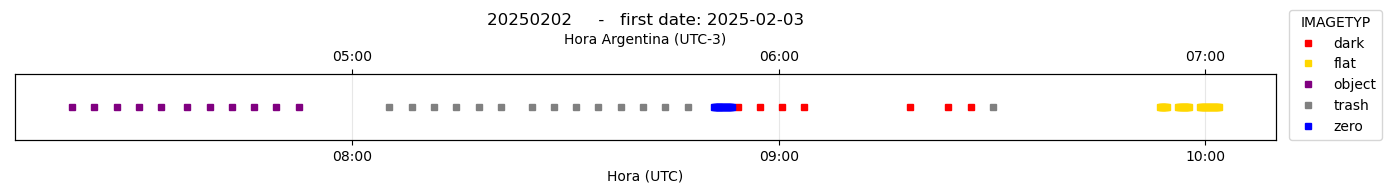

object
NO_OBJECT    14
Gaia24ddl    11
Name: count, dtype: int64


In [132]:
dfobj = check_night(df, "20250202")